# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

이건 1번째 코드 셀이에요


In [32]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: C:\Users\cedis\PycharmProjects\gpt-lab


이건 2번째 코드 셀이에요


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

이건 3번째 코드 셀이에요


In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

이미 존재합니다: C:\Users\cedis\PycharmProjects\gpt-lab\data\ratings_train.txt
이미 존재합니다: C:\Users\cedis\PycharmProjects\gpt-lab\data\ratings_test.txt
사전 학습 train 텍스트: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_val.txt (120,560자)
감성 분류 train: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_train.txt
LM val exists: True C:\Users\cedis\PycharmProjects\gpt-lab\data\nsmc_lm_val.txt


이건 4번째 코드 셀이에요


In [35]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

이건 5번째 코드 셀이에요


In [36]:
run_pytest("tests/test_bpe.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_bpe.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.02s ==============================


선택한 테스트를

0

이건 6번째 코드 셀이에요


In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

이건 7번째 코드 셀이에요


In [7]:
run_pytest("tests/test_dataset.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_dataset.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 2.31s ==============================


선택한 테스트를 통과했습니다.


0

이건 8번째 코드 셀이에요


In [8]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

이건 9번째 코드 셀이에요


In [9]:
run_pytest("tests/test_attention.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_attention.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 1.41s ==============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

이건 10번째 코드 셀이에요


In [10]:
run_pytest("tests/test_model.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_model.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [

0

이건 11번째 코드 셀이에요


In [11]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

이건 12번째 코드 셀이에요


In [12]:
run_pytest("tests/test_train.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_train.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

============================== 5 passed in 2.55s ==============================


선택한 테스트를 통과했습니다.


0

이건 13번째 코드 셀이에요


In [13]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.9834418296813965


## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

이건 14번째 코드 셀이에요


In [14]:
run_pytest("tests/test_finetune.py")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/test_finetune.py -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 1.35s ==============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

이건 15번째 코드 셀이에요


In [15]:
run_pytest("tests/")

실행 명령: C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe -m pytest tests/ -v
============================= test session starts =============================
platform win32 -- Python 3.11.9, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\cedis\PycharmProjects\gpt-lab\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\cedis\PycharmProjects\gpt-lab
collecting ... collected 28 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [  3%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [  7%]
tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 10%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 14%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 17%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 21%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 25%]


0

이건 16번째 코드 셀이에요


In [16]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:10000]

tokenizer = BPETokenizer(vocab_size=500)
tokenizer.train(corpus)

ids = tokenizer.encode(corpus, add_bos_eos=False)
print("num tokens:", len(ids))

context_length = 32

train_loader = create_dataloader(
    ids,
    context_length=context_length,
    batch_size=4,
    shuffle=True,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 1,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=None,
    optimizer=optimizer,
    device=device,
    num_epochs=1,
    eval_freq=0,
    eval_iter=0,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

start_ids = tokenizer.encode("영화가", add_bos_eos=False)
idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

out = generate(
    model=model,
    idx=idx,
    max_new_tokens=20,
    context_size=context_length,
    temperature=1.0,
    top_k=20,
    eos_id=tokenizer.get_eos_id(),
)

print(tokenizer.decode(out[0].tolist(), skip_special=True))

device: cuda
num tokens: 11376
train_losses: [6.2522271938538285]
영화가 내���ㅋㅋ�����전하�는�마� ��이� 좋


이건 17번째 코드 셀이에요


In [19]:
from pathlib import Path

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

corpus = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:100000]
val_corpus = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")[:20000]

tokenizer = BPETokenizer(vocab_size=1000)
tokenizer.train(corpus)

train_ids = tokenizer.encode(corpus, add_bos_eos=False)
val_ids = tokenizer.encode(val_corpus, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 64
batch_size = 16

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=100,
    eval_freq=100,
    eval_iter=5,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=None,
)

print("train_losses:", train_losses)

for start_text in ["영화가", "정말", "배우가"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=40,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

device: cuda
train tokens: 82148
val tokens: 16555
Step 100: train loss 6.2649, val loss 6.2792
Step 200: train loss 6.2145, val loss 6.2525
Step 300: train loss 6.1528, val loss 6.1610
Step 400: train loss 5.8752, val loss 5.9625
Step 500: train loss 5.7339, val loss 5.6941
Step 600: train loss 5.4179, val loss 5.4478
Step 700: train loss 5.2072, val loss 5.2734
Step 800: train loss 5.0583, val loss 5.1497
Step 900: train loss 4.8483, val loss 5.0589
Step 1000: train loss 4.7275, val loss 4.9940
Step 1100: train loss 4.7012, val loss 4.9414
Step 1200: train loss 4.6153, val loss 4.9032
Step 1300: train loss 4.5542, val loss 4.8721
Step 1400: train loss 4.4212, val loss 4.8539
Step 1500: train loss 4.3934, val loss 4.8381
Step 1600: train loss 4.3313, val loss 4.8267
Step 1700: train loss 4.4057, val loss 4.8199
Step 1800: train loss 4.1684, val loss 4.8224
Step 1900: train loss 4.1137, val loss 4.8214
Step 2000: train loss 4.1658, val loss 4.8182
Step 2100: train loss 4.0271, val loss

이건 18번째 코드 셀이에요


In [20]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

VOCAB_SIZE = 2000
TOKENIZER_PATH = Path(f"data/vocab_basic_{VOCAB_SIZE}.json")

tokenizer = BPETokenizer(vocab_size=VOCAB_SIZE)

if TOKENIZER_PATH.exists():
    print("load tokenizer:", TOKENIZER_PATH)
    tokenizer.load(TOKENIZER_PATH)
else:
    print("train tokenizer")
    tokenizer.train(train_text)
    tokenizer.save(TOKENIZER_PATH)
    print("saved tokenizer:", TOKENIZER_PATH)

print("encode train")
train_ids = tokenizer.encode(train_text, add_bos_eos=False)

print("encode val")
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=3,
    eval_freq=200,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=500,
)

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=3,
    global_step=len(train_loader) * 3,
    path="checkpoints/basic_full_final.pt",
)

print("train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=80,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")

device: cuda
train tokenizer
saved tokenizer: data\vocab_basic_2000.json
encode train
encode val
train tokens: 900849
val tokens: 78686
train batches: 220
val batches: 20
Step 200: train loss 6.9251, val loss 6.9280
Step 400: train loss 6.7773, val loss 6.7830
Step 600: train loss 6.3854, val loss 6.3138
train_losses: [7.061828784509139, 6.865258726206693, 6.495676428621466]
final_val_loss: 6.168029737472534
prompt: 영화가
영화가다
재밌�
평점으로 뽡에 비해자이 많이지의 �을 그 필요하는거리지
별 영화라한다. 오래서 tv요... 진짜의 진아..
고...
별의 나에.. 이름 영화도가 그�기심이렇게 가라스가 참다
그랭는 어�주이 지
prompt: 정말
정말 개판 말으로영화로 지나
성고 사람해도 안벽 C�로 이쁘해라에 잘 0점에 나이들도 그다. 아. 왜?. 뭐어가 아니다. 드라마가, 재밌었다. of
난 진짜 그이가 아깝다
전의 거지 글라전히 무다. 왜
전인은 그렇게
prompt: 배우가
배우가? 더빙이 더욱한 사랑과 대�를 주는 너무 하리고고 감동하게 너무 다에 정말 하면서의 너무것서는 하나을 이쁘어한 드라마도 더 너무 이 영화를 그거.. 말아다고 가기서 재밌는 이름이 참다
평점이가 좋는데 ""이 가치들도 나의 �00자이는 것
prompt: 스토리는
스토리는 한
별도 이거려도 너무게 보고 어게 해도 못고 하치하는 좋었다
제로 어쩠이 지한 것은 ""한 영화는 안
재밌다보는데 생각이네요아라가 되이 더도 나가 아니라가 남가만... 다 재밌도 좋다. 그저 Foo믹도 안되이 더의
elapsed: 1097.9s


이건 19번째 코드 셀이에요


In [21]:
from pathlib import Path
import time

import torch

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import train_model, generate, calc_loss_loader, save_checkpoint, load_checkpoint


start_time = time.perf_counter()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_full_final.pt",
    device=device,
)

print("resume epoch:", start_epoch)
print("resume global_step:", global_step)
print("train batches:", len(train_loader))

EXTRA_EPOCHS = 30

train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=EXTRA_EPOCHS,
    eval_freq=500,
    eval_iter=20,
    start_context="영화가",
    tokenizer=tokenizer,
    ckpt_freq=1000,
    start_epoch=start_epoch,
    global_step=global_step,
)

final_global_step = global_step + len(train_loader) * EXTRA_EPOCHS
final_epoch = start_epoch + EXTRA_EPOCHS

final_val_loss = calc_loss_loader(
    val_loader,
    model,
    device,
    num_batches=50,
)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=final_epoch,
    global_step=final_global_step,
    path=f"checkpoints/basic_full_epoch_{final_epoch}.pt",
)

print("continued train_losses:", train_losses)
print("final_val_loss:", final_val_loss)

for start_text in ["영화가", "정말", "배우가", "스토리는", "이 영화는"]:
    start_ids = tokenizer.encode(start_text, add_bos_eos=False)
    idx = torch.tensor(start_ids, dtype=torch.long, device=device).unsqueeze(0)

    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=120,
        context_size=context_length,
        temperature=0.8,
        top_k=40,
        eos_id=tokenizer.get_eos_id(),
    )

    print("=" * 40)
    print("prompt:", start_text)
    print(tokenizer.decode(out[0].tolist(), skip_special=True))

elapsed = time.perf_counter() - start_time
print(f"elapsed: {elapsed:.1f}s")
print("final_epoch:", final_epoch)
print("final_global_step:", final_global_step)

device: cuda
resume epoch: 3
resume global_step: 660
train batches: 220
Step 1000: train loss 5.7360, val loss 5.6755
Step 1500: train loss 5.4070, val loss 5.3922
Step 2000: train loss 5.2982, val loss 5.2652
Step 2500: train loss 5.1551, val loss 5.1914
Step 3000: train loss 5.0985, val loss 5.1439
Step 3500: train loss 5.0338, val loss 5.1082
Step 4000: train loss 4.9966, val loss 5.0851
Step 4500: train loss 4.9219, val loss 5.0650
Step 5000: train loss 4.9460, val loss 5.0485
Step 5500: train loss 4.9011, val loss 5.0300
Step 6000: train loss 4.8224, val loss 5.0250
Step 6500: train loss 4.8688, val loss 5.0127
Step 7000: train loss 4.8406, val loss 5.0020
continued train_losses: [6.049400539831682, 5.770001073317094, 5.593169383569197, 5.473657209222967, 5.3854138374328615, 5.31684298732064, 5.261382644826716, 5.216652198271318, 5.178371897610751, 5.145807667212053, 5.118046894940463, 5.091538808562539, 5.068849463896318, 5.048790368166837, 5.0304039673371745, 5.01317580613223, 4

이건 20번째 코드 셀이에요


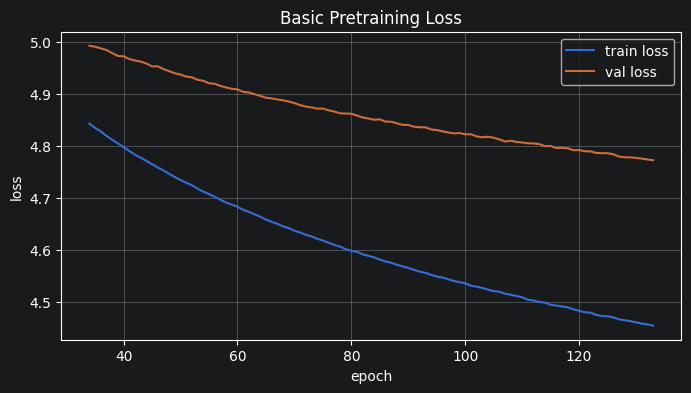

latest epoch: 133
global_step: 29260
train_loss: 4.4536618947982785
val_loss: 4.772017192840576
elapsed: 286.1 sec


In [22]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

start_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_full_epoch_33.pt",
    device=device,
)

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
}

EPOCHS_TO_RUN = 100
EVAL_BATCHES = 20
start_time = time.perf_counter()

for epoch in range(start_epoch, start_epoch + EPOCHS_TO_RUN):
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=epoch + 1,
        global_step=global_step,
        path=f"checkpoints/basic_monitor_latest.pt",
    )

    clear_output(wait=True)

    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Basic Pretraining Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("latest epoch:", epoch + 1)
    print("global_step:", global_step)
    print("train_loss:", train_loss)
    print("val_loss:", val_loss)
    print("elapsed:", round(time.perf_counter() - start_time, 1), "sec")

    Path("checkpoints/basic_monitor_history.json").write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

이건 21번째 코드 셀이에요


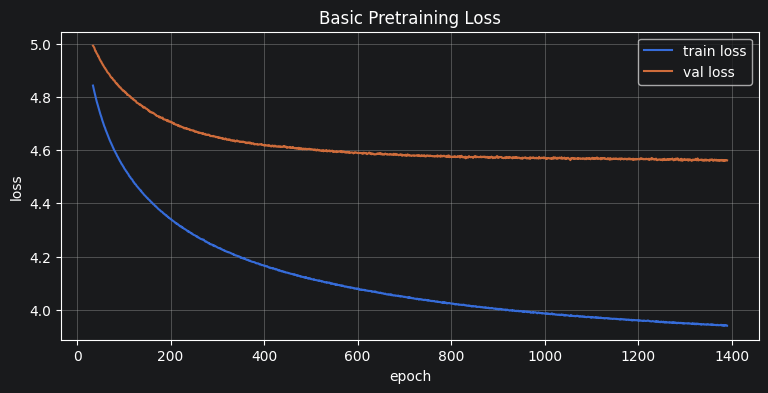

latest epoch: 1390
global_step: 305800
train_loss: 3.940032276240262
val_loss: 4.561598777770996
best_val_loss: 4.559159135818481
elapsed: 3595.8 sec
remaining: 4.2 sec
done
final epoch: 1392
global_step: 306240
best_val_loss: 4.558745741844177
elapsed: 3601.5 sec


In [23]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output

from src.bpe import BPETokenizer
from src.dataset import create_dataloader
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader, save_checkpoint, load_checkpoint


MAX_SECONDS = 60 * 60
EVAL_BATCHES = 20
PLOT_EVERY = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32

train_loader = create_dataloader(
    train_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = create_dataloader(
    val_ids,
    context_length=context_length,
    batch_size=batch_size,
    shuffle=False,
)

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

current_epoch, global_step = load_checkpoint(
    model=model,
    optimizer=optimizer,
    path="checkpoints/basic_monitor_latest.pt",
    device=device,
)

history_path = Path("checkpoints/basic_monitor_history.json")
history = json.loads(history_path.read_text(encoding="utf-8"))

best_val_loss = min(history["val_loss"])
print("start epoch:", current_epoch)
print("start global_step:", global_step)
print("best val loss:", best_val_loss)

start_time = time.perf_counter()

while time.perf_counter() - start_time < MAX_SECONDS:
    model.train()
    epoch_losses = []

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        global_step += 1

    current_epoch += 1

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_BATCHES)

    history["epoch"].append(current_epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=current_epoch,
        global_step=global_step,
        path="checkpoints/basic_monitor_latest.pt",
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=current_epoch,
            global_step=global_step,
            path="checkpoints/basic_monitor_best.pt",
        )

    history_path.write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    if current_epoch % PLOT_EVERY == 0:
        clear_output(wait=True)

        plt.figure(figsize=(9, 4))
        plt.plot(history["epoch"], history["train_loss"], label="train loss")
        plt.plot(history["epoch"], history["val_loss"], label="val loss")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.title("Basic Pretraining Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

        elapsed = time.perf_counter() - start_time
        print("latest epoch:", current_epoch)
        print("global_step:", global_step)
        print("train_loss:", train_loss)
        print("val_loss:", val_loss)
        print("best_val_loss:", best_val_loss)
        print("elapsed:", round(elapsed, 1), "sec")
        print("remaining:", round(MAX_SECONDS - elapsed, 1), "sec")

elapsed = time.perf_counter() - start_time

print("done")
print("final epoch:", current_epoch)
print("global_step:", global_step)
print("best_val_loss:", best_val_loss)
print("elapsed:", round(elapsed, 1), "sec")

이건 22번째 코드 셀이에요


device: cuda
activation: gelu
gelu epoch 001 train 7.0567 val 6.9261
gelu epoch 002 train 6.8747 val 6.7288
gelu epoch 003 train 6.5265 val 6.2022
gelu epoch 004 train 6.0647 val 5.8091
gelu epoch 005 train 5.7782 val 5.5992
gelu epoch 006 train 5.5978 val 5.4645
gelu epoch 007 train 5.4746 val 5.3749
gelu epoch 008 train 5.3839 val 5.3117
gelu epoch 009 train 5.3145 val 5.2606
gelu epoch 010 train 5.2589 val 5.2248
gelu epoch 011 train 5.2139 val 5.1945
gelu epoch 012 train 5.1761 val 5.1734
gelu epoch 013 train 5.1438 val 5.1498
gelu epoch 014 train 5.1156 val 5.1345
gelu epoch 015 train 5.0899 val 5.1187
gelu epoch 016 train 5.0678 val 5.1051
gelu epoch 017 train 5.0471 val 5.0949
gelu epoch 018 train 5.0296 val 5.0833
gelu epoch 019 train 5.0114 val 5.0742
gelu epoch 020 train 4.9958 val 5.0699
gelu epoch 021 train 4.9815 val 5.0599
gelu epoch 022 train 4.9672 val 5.0541
gelu epoch 023 train 4.9539 val 5.0488
gelu epoch 024 train 4.9410 val 5.0445
gelu epoch 025 train 4.9298 val 5.

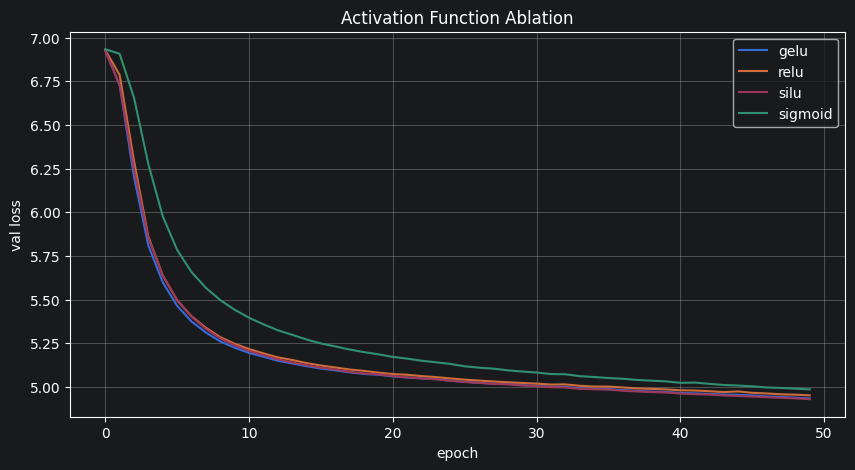

gelu final val loss: 4.9344 best val loss: 4.9344 elapsed: 126.1
relu final val loss: 4.952 best val loss: 4.952 elapsed: 125.1
silu final val loss: 4.9297 best val loss: 4.9297 elapsed: 125.8
sigmoid final val loss: 4.9861 best val loss: 4.9861 elapsed: 119.8


In [1]:
from pathlib import Path
import time
import json

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel
from src.train import calc_loss_batch, calc_loss_loader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = BPETokenizer(vocab_size=2000)
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

context_length = 128
batch_size = 32
epochs = 50
eval_batches = 20
seed = 123

config = {
    "vocab_size": tokenizer.vocab_size,
    "context_length": context_length,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

def make_activation(name):
    if name == "gelu":
        return nn.GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)

def replace_activation(model, name):
    for block in model.blocks:
        block.ffn.net[1] = make_activation(name)

def make_loader(token_ids, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )

results = {}

for activation_name in ["gelu", "relu", "silu", "sigmoid"]:
    print("=" * 50)
    print("activation:", activation_name)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_loader = make_loader(train_ids, shuffle=True, seed=seed)
    val_loader = make_loader(val_ids, shuffle=False, seed=seed)

    model = GPTModel(config).to(device)
    replace_activation(model, activation_name)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

    train_losses = []
    val_losses = []

    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = sum(epoch_losses) / len(epoch_losses)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_batches)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"{activation_name} epoch {epoch:03d} "
            f"train {train_loss:.4f} val {val_loss:.4f}"
        )

    elapsed = time.perf_counter() - start

    results[activation_name] = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": elapsed,
    }

    print("elapsed:", round(elapsed, 1), "sec")

Path("checkpoints/activation_ablation_results.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

plt.figure(figsize=(10, 5))
for name, result in results.items():
    plt.plot(result["val_loss"], label=name)

plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Activation Function Ablation")
plt.legend()
plt.grid(True)
plt.show()

for name, result in results.items():
    print(
        name,
        "final val loss:",
        round(result["val_loss"][-1], 4),
        "best val loss:",
        round(min(result["val_loss"]), 4),
        "elapsed:",
        round(result["elapsed"], 1),
    )

이건 23번째 코드 셀이에요


In [2]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, FeedForward, GELU
from src.train import calc_loss_batch, calc_loss_loader


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

TRAIN_TEXT = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
VAL_TEXT = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

TOKENIZER_CACHE = {}
IDS_CACHE = {}

BASE_CONFIG = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

def get_tokenizer(vocab_size):
    if vocab_size in TOKENIZER_CACHE:
        return TOKENIZER_CACHE[vocab_size]

    path = Path(f"data/vocab_ablation_{vocab_size}.json")
    tokenizer = BPETokenizer(vocab_size=vocab_size)

    if path.exists():
        tokenizer.load(path)
    else:
        tokenizer.train(TRAIN_TEXT)
        tokenizer.save(path)

    TOKENIZER_CACHE[vocab_size] = tokenizer
    return tokenizer

def get_ids(vocab_size):
    if vocab_size in IDS_CACHE:
        return IDS_CACHE[vocab_size]

    tokenizer = get_tokenizer(vocab_size)
    train_ids = tokenizer.encode(TRAIN_TEXT, add_bos_eos=False)
    val_ids = tokenizer.encode(VAL_TEXT, add_bos_eos=False)
    IDS_CACHE[vocab_size] = (train_ids, val_ids)
    return train_ids, val_ids

def make_activation(name):
    if name == "gelu":
        return GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)

def apply_overrides(model, config, overrides):
    activation = overrides.get("activation", "gelu")
    ffn_mult = overrides.get("ffn_mult", 4)

    for block in model.blocks:
        block.ffn = FeedForward(
            config["emb_dim"],
            dropout=config["drop_rate"],
            mult=ffn_mult,
        ).to(DEVICE)
        block.ffn.net[1] = make_activation(activation)

def make_loader(token_ids, context_length, batch_size, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
    )

def make_optimizer(model, overrides):
    lr = overrides.get("learning_rate", 3e-4)
    weight_decay = overrides.get("weight_decay", 0.0)
    opt_name = overrides.get("optimizer", "adamw")

    if opt_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    raise ValueError(opt_name)

def run_one_experiment(name, overrides, epochs=30, seed=123, eval_batches=20):
    config = dict(BASE_CONFIG)
    config.update({k: v for k, v in overrides.items() if k in config})

    vocab_size = config["vocab_size"]
    context_length = config["context_length"]
    batch_size = overrides.get("batch_size", 32)

    train_ids, val_ids = get_ids(vocab_size)

    train_loader = make_loader(train_ids, context_length, batch_size, True, seed)
    val_loader = make_loader(val_ids, context_length, batch_size, False, seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = GPTModel(config).to(DEVICE)
    apply_overrides(model, config, overrides)
    optimizer = make_optimizer(model, overrides)

    train_losses = []
    val_losses = []
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()

            if overrides.get("grad_clip") is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), overrides["grad_clip"])

            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = sum(epoch_losses) / len(epoch_losses)
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=eval_batches)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"{name} epoch {epoch:03d} train {train_loss:.4f} val {val_loss:.4f}")

    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": time.perf_counter() - start,
        "overrides": overrides,
    }

def run_ablation(category, variants, epochs=30):
    results = {}

    for name, overrides in variants:
        print("=" * 60)
        print(category, name)
        results[name] = run_one_experiment(
            name=f"{category}/{name}",
            overrides=overrides,
            epochs=epochs,
        )

    Path(f"checkpoints/ablation_{category}.json").write_text(
        json.dumps(results, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    plt.figure(figsize=(10, 5))
    for name, result in results.items():
        plt.plot(result["val_loss"], label=name)

    plt.xlabel("epoch")
    plt.ylabel("val loss")
    plt.title(f"{category} ablation")
    plt.legend()
    plt.grid(True)
    plt.show()

    for name, result in results.items():
        print(
            name,
            "final val:",
            round(result["val_loss"][-1], 4),
            "best val:",
            round(min(result["val_loss"]), 4),
            "elapsed:",
            round(result["elapsed"], 1),
        )

    return results

device: cuda


이건 24번째 코드 셀이에요


activation gelu
activation/gelu epoch 001 train 7.0561 val 6.9256
activation/gelu epoch 002 train 6.8731 val 6.7230
activation/gelu epoch 003 train 6.5174 val 6.1885
activation/gelu epoch 004 train 6.0586 val 5.8060
activation/gelu epoch 005 train 5.7780 val 5.5978
activation/gelu epoch 006 train 5.5989 val 5.4648
activation/gelu epoch 007 train 5.4760 val 5.3771
activation/gelu epoch 008 train 5.3857 val 5.3141
activation/gelu epoch 009 train 5.3168 val 5.2646
activation/gelu epoch 010 train 5.2615 val 5.2299
activation/gelu epoch 011 train 5.2155 val 5.1994
activation/gelu epoch 012 train 5.1785 val 5.1781
activation/gelu epoch 013 train 5.1459 val 5.1540
activation/gelu epoch 014 train 5.1170 val 5.1383
activation/gelu epoch 015 train 5.0919 val 5.1222
activation/gelu epoch 016 train 5.0686 val 5.1103
activation/gelu epoch 017 train 5.0488 val 5.0998
activation/gelu epoch 018 train 5.0306 val 5.0870
activation/gelu epoch 019 train 5.0122 val 5.0772
activation/gelu epoch 020 train 4.

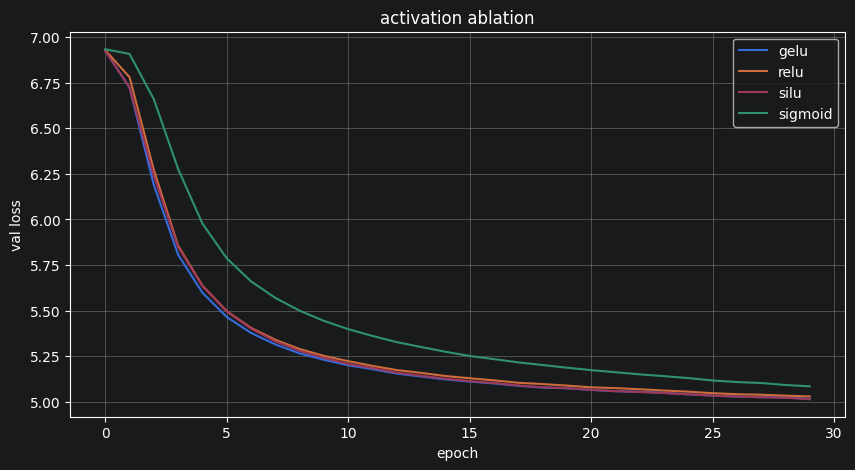

gelu final val: 5.0153 best val: 5.0153 elapsed: 73.6
relu final val: 5.0288 best val: 5.0288 elapsed: 66.8
silu final val: 5.0134 best val: 5.0134 elapsed: 63.9
sigmoid final val: 5.0842 best val: 5.0842 elapsed: 70.1


In [37]:
activation_results = run_ablation(
    "activation",
    [
        ("gelu", {"activation": "gelu"}),
        ("relu", {"activation": "relu"}),
        ("silu", {"activation": "silu"}),
        ("sigmoid", {"activation": "sigmoid"}),
    ],
    epochs=30,
)

이건 25번째 코드 셀이에요


dropout drop_0_0
dropout/drop_0_0 epoch 001 train 7.0448 val 6.9227
dropout/drop_0_0 epoch 002 train 6.8168 val 6.6119
dropout/drop_0_0 epoch 003 train 6.2761 val 5.9947
dropout/drop_0_0 epoch 004 train 5.7838 val 5.6724
dropout/drop_0_0 epoch 005 train 5.5181 val 5.4911
dropout/drop_0_0 epoch 006 train 5.3492 val 5.3745
dropout/drop_0_0 epoch 007 train 5.2328 val 5.3004
dropout/drop_0_0 epoch 008 train 5.1468 val 5.2493
dropout/drop_0_0 epoch 009 train 5.0802 val 5.2114
dropout/drop_0_0 epoch 010 train 5.0256 val 5.1828
dropout/drop_0_0 epoch 011 train 4.9793 val 5.1619
dropout/drop_0_0 epoch 012 train 4.9395 val 5.1485
dropout/drop_0_0 epoch 013 train 4.9036 val 5.1339
dropout/drop_0_0 epoch 014 train 4.8711 val 5.1263
dropout/drop_0_0 epoch 015 train 4.8417 val 5.1184
dropout/drop_0_0 epoch 016 train 4.8141 val 5.1163
dropout/drop_0_0 epoch 017 train 4.7879 val 5.1130
dropout/drop_0_0 epoch 018 train 4.7635 val 5.1130
dropout/drop_0_0 epoch 019 train 4.7409 val 5.1094
dropout/drop_0

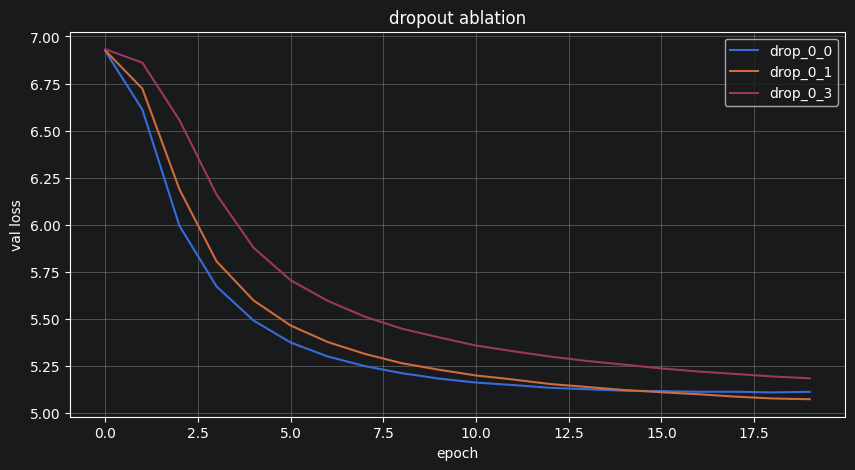

drop_0_0 final val: 5.1127 best val: 5.1094 elapsed: 51.1
drop_0_1 final val: 5.0733 best val: 5.0733 elapsed: 58.4
drop_0_3 final val: 5.1842 best val: 5.1842 elapsed: 47.8


In [38]:
# ABLATION_DROPOUT
dropout_results = run_ablation(
    "dropout",
    [
        ("drop_0_0", {"drop_rate": 0.0}),
        ("drop_0_1", {"drop_rate": 0.1}),
        ("drop_0_3", {"drop_rate": 0.3}),
    ],
    epochs=20,
)


이건 26번째 코드 셀이에요


learning_rate lr_1e_4
learning_rate/lr_1e_4 epoch 001 train 7.2475 val 6.9452
learning_rate/lr_1e_4 epoch 002 train 6.9418 val 6.9307
learning_rate/lr_1e_4 epoch 003 train 6.9315 val 6.9209
learning_rate/lr_1e_4 epoch 004 train 6.9140 val 6.8904
learning_rate/lr_1e_4 epoch 005 train 6.8604 val 6.7993
learning_rate/lr_1e_4 epoch 006 train 6.7532 val 6.6589
learning_rate/lr_1e_4 epoch 007 train 6.6117 val 6.4895
learning_rate/lr_1e_4 epoch 008 train 6.4511 val 6.3075
learning_rate/lr_1e_4 epoch 009 train 6.2904 val 6.1421
learning_rate/lr_1e_4 epoch 010 train 6.1480 val 6.0056
learning_rate/lr_1e_4 epoch 011 train 6.0317 val 5.9002
learning_rate/lr_1e_4 epoch 012 train 5.9351 val 5.8139
learning_rate/lr_1e_4 epoch 013 train 5.8531 val 5.7377
learning_rate/lr_1e_4 epoch 014 train 5.7827 val 5.6742
learning_rate/lr_1e_4 epoch 015 train 5.7193 val 5.6194
learning_rate/lr_1e_4 epoch 016 train 5.6644 val 5.5715
learning_rate/lr_1e_4 epoch 017 train 5.6160 val 5.5300
learning_rate/lr_1e_4 epoc

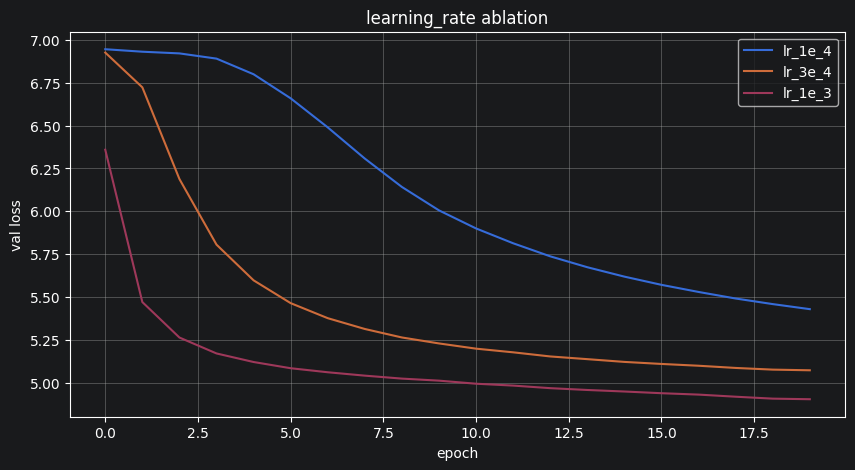

lr_1e_4 final val: 5.4297 best val: 5.4297 elapsed: 49.2
lr_3e_4 final val: 5.0733 best val: 5.0733 elapsed: 59.0
lr_1e_3 final val: 4.9046 best val: 4.9046 elapsed: 50.2


In [39]:
# ABLATION_LEARNING_RATE
learning_rate_results = run_ablation(
    "learning_rate",
    [
        ("lr_1e_4", {"learning_rate": 1e-4}),
        ("lr_3e_4", {"learning_rate": 3e-4}),
        ("lr_1e_3", {"learning_rate": 1e-3}),
    ],
    epochs=20,
)


이건 27번째 코드 셀이에요


optimizer_weight_decay adamw_wd_0
optimizer_weight_decay/adamw_wd_0 epoch 001 train 7.0561 val 6.9256
optimizer_weight_decay/adamw_wd_0 epoch 002 train 6.8731 val 6.7230
optimizer_weight_decay/adamw_wd_0 epoch 003 train 6.5174 val 6.1885
optimizer_weight_decay/adamw_wd_0 epoch 004 train 6.0586 val 5.8060
optimizer_weight_decay/adamw_wd_0 epoch 005 train 5.7780 val 5.5978
optimizer_weight_decay/adamw_wd_0 epoch 006 train 5.5989 val 5.4648
optimizer_weight_decay/adamw_wd_0 epoch 007 train 5.4760 val 5.3771
optimizer_weight_decay/adamw_wd_0 epoch 008 train 5.3857 val 5.3141
optimizer_weight_decay/adamw_wd_0 epoch 009 train 5.3168 val 5.2646
optimizer_weight_decay/adamw_wd_0 epoch 010 train 5.2615 val 5.2299
optimizer_weight_decay/adamw_wd_0 epoch 011 train 5.2155 val 5.1994
optimizer_weight_decay/adamw_wd_0 epoch 012 train 5.1785 val 5.1781
optimizer_weight_decay/adamw_wd_0 epoch 013 train 5.1459 val 5.1540
optimizer_weight_decay/adamw_wd_0 epoch 014 train 5.1170 val 5.1383
optimizer_weig

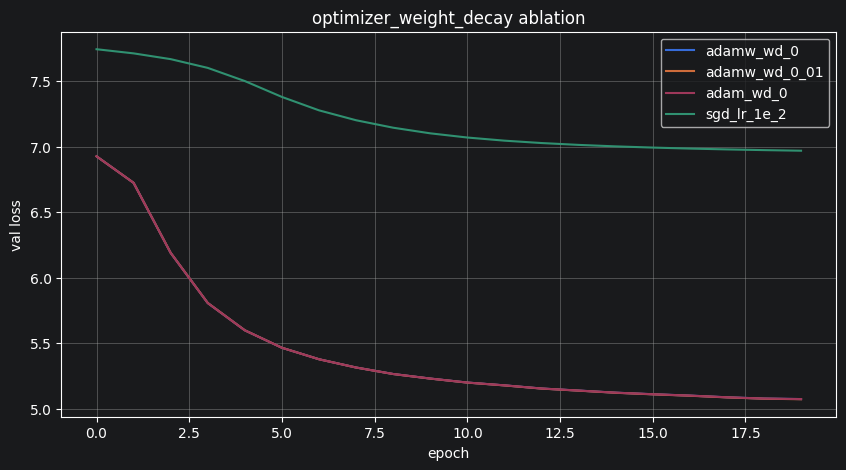

adamw_wd_0 final val: 5.0733 best val: 5.0733 elapsed: 51.7
adamw_wd_0_01 final val: 5.0721 best val: 5.0721 elapsed: 50.9
adam_wd_0 final val: 5.0733 best val: 5.0733 elapsed: 51.3
sgd_lr_1e_2 final val: 6.9682 best val: 6.9682 elapsed: 54.6


In [40]:
# ABLATION_OPTIMIZER_WEIGHT_DECAY
optimizer_weight_decay_results = run_ablation(
    "optimizer_weight_decay",
    [
        ("adamw_wd_0", {"optimizer": "adamw", "weight_decay": 0.0}),
        ("adamw_wd_0_01", {"optimizer": "adamw", "weight_decay": 0.01}),
        ("adam_wd_0", {"optimizer": "adam", "weight_decay": 0.0}),
        ("sgd_lr_1e_2", {"optimizer": "sgd", "learning_rate": 1e-2}),
    ],
    epochs=20,
)


이건 28번째 코드 셀이에요


context_length ctx_64
context_length/ctx_64 epoch 001 train 6.9993 val 6.8667
context_length/ctx_64 epoch 002 train 6.5588 val 6.0892
context_length/ctx_64 epoch 003 train 5.9225 val 5.6383
context_length/ctx_64 epoch 004 train 5.6029 val 5.4321
context_length/ctx_64 epoch 005 train 5.4284 val 5.3151
context_length/ctx_64 epoch 006 train 5.3178 val 5.2384
context_length/ctx_64 epoch 007 train 5.2390 val 5.1873
context_length/ctx_64 epoch 008 train 5.1790 val 5.1495
context_length/ctx_64 epoch 009 train 5.1322 val 5.1214
context_length/ctx_64 epoch 010 train 5.0933 val 5.0976
context_length/ctx_64 epoch 011 train 5.0599 val 5.0749
context_length/ctx_64 epoch 012 train 5.0300 val 5.0608
context_length/ctx_64 epoch 013 train 5.0033 val 5.0437
context_length/ctx_64 epoch 014 train 4.9794 val 5.0291
context_length/ctx_64 epoch 015 train 4.9569 val 5.0111
context_length/ctx_64 epoch 016 train 4.9364 val 4.9992
context_length/ctx_64 epoch 017 train 4.9159 val 4.9885
context_length/ctx_64 epoc

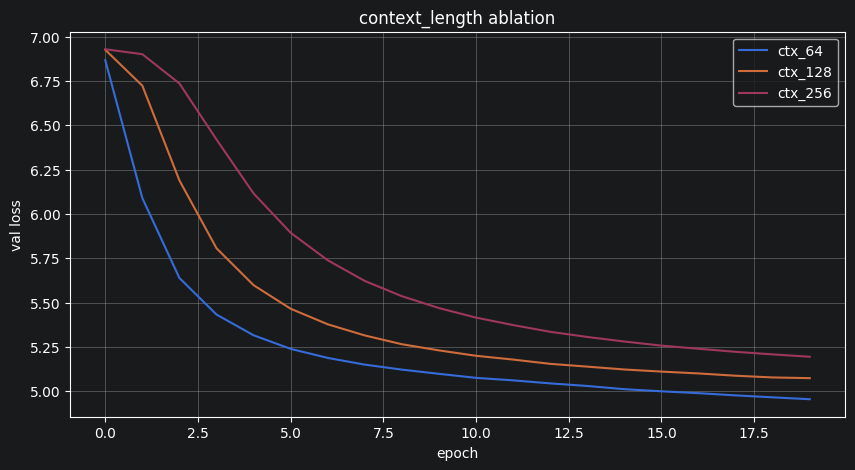

ctx_64 final val: 4.9544 best val: 4.9544 elapsed: 97.7
ctx_128 final val: 5.0733 best val: 5.0733 elapsed: 51.6
ctx_256 final val: 5.194 best val: 5.194 elapsed: 27.6


In [41]:
# ABLATION_CONTEXT_LENGTH
context_length_results = run_ablation(
    "context_length",
    [
        ("ctx_64", {"context_length": 64}),
        ("ctx_128", {"context_length": 128}),
        ("ctx_256", {"context_length": 256}),
    ],
    epochs=20,
)


이건 29번째 코드 셀이에요


vocab_size vocab_1000
vocab_size/vocab_1000 epoch 001 train 6.2572 val 5.8284
vocab_size/vocab_1000 epoch 002 train 5.4233 val 5.0141
vocab_size/vocab_1000 epoch 003 train 4.9416 val 4.7260
vocab_size/vocab_1000 epoch 004 train 4.7335 val 4.5928
vocab_size/vocab_1000 epoch 005 train 4.6215 val 4.5208
vocab_size/vocab_1000 epoch 006 train 4.5473 val 4.4647
vocab_size/vocab_1000 epoch 007 train 4.4927 val 4.4284
vocab_size/vocab_1000 epoch 008 train 4.4487 val 4.3891
vocab_size/vocab_1000 epoch 009 train 4.4120 val 4.3627
vocab_size/vocab_1000 epoch 010 train 4.3796 val 4.3332
vocab_size vocab_2000
vocab_size/vocab_2000 epoch 001 train 7.0561 val 6.9256
vocab_size/vocab_2000 epoch 002 train 6.8731 val 6.7230
vocab_size/vocab_2000 epoch 003 train 6.5174 val 6.1885
vocab_size/vocab_2000 epoch 004 train 6.0586 val 5.8060
vocab_size/vocab_2000 epoch 005 train 5.7780 val 5.5978
vocab_size/vocab_2000 epoch 006 train 5.5989 val 5.4648
vocab_size/vocab_2000 epoch 007 train 5.4760 val 5.3771
voca

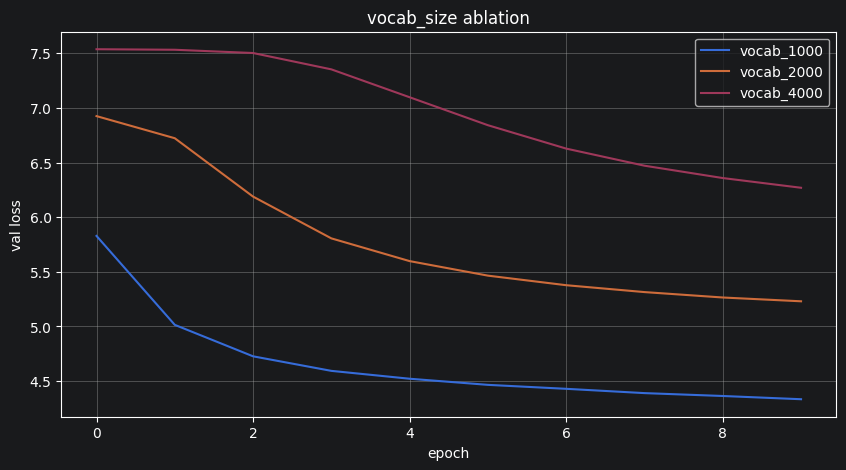

vocab_1000 final val: 4.3332 best val: 4.3332 elapsed: 35.2
vocab_2000 final val: 5.2299 best val: 5.2299 elapsed: 31.4
vocab_4000 final val: 6.2694 best val: 6.2694 elapsed: 23.4


In [42]:
# ABLATION_VOCAB_SIZE
vocab_size_results = run_ablation(
    "vocab_size",
    [
        ("vocab_1000", {"vocab_size": 1000}),
        ("vocab_2000", {"vocab_size": 2000}),
        ("vocab_4000", {"vocab_size": 4000}),
    ],
    epochs=10,
)


이건 30번째 코드 셀이에요


emb_dim emb_64
emb_dim/emb_64 epoch 001 train 7.1666 val 6.9367
emb_dim/emb_64 epoch 002 train 6.9369 val 6.9272
emb_dim/emb_64 epoch 003 train 6.9177 val 6.8896
emb_dim/emb_64 epoch 004 train 6.8448 val 6.7635
emb_dim/emb_64 epoch 005 train 6.6753 val 6.5101
emb_dim/emb_64 epoch 006 train 6.4266 val 6.2362
emb_dim/emb_64 epoch 007 train 6.2103 val 6.0366
emb_dim/emb_64 epoch 008 train 6.0463 val 5.8892
emb_dim/emb_64 epoch 009 train 5.9182 val 5.7739
emb_dim/emb_64 epoch 010 train 5.8157 val 5.6838
emb_dim/emb_64 epoch 011 train 5.7327 val 5.6113
emb_dim/emb_64 epoch 012 train 5.6639 val 5.5516
emb_dim/emb_64 epoch 013 train 5.6067 val 5.5019
emb_dim/emb_64 epoch 014 train 5.5572 val 5.4613
emb_dim/emb_64 epoch 015 train 5.5146 val 5.4251
emb_dim/emb_64 epoch 016 train 5.4761 val 5.3940
emb_dim/emb_64 epoch 017 train 5.4435 val 5.3669
emb_dim/emb_64 epoch 018 train 5.4134 val 5.3441
emb_dim/emb_64 epoch 019 train 5.3879 val 5.3224
emb_dim/emb_64 epoch 020 train 5.3644 val 5.3043
emb_d

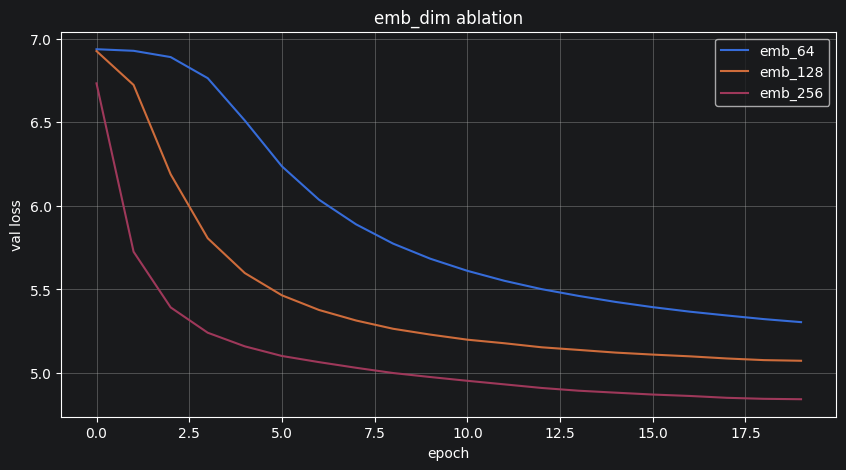

emb_64 final val: 5.3043 best val: 5.3043 elapsed: 50.8
emb_128 final val: 5.0733 best val: 5.0733 elapsed: 53.2
emb_256 final val: 4.8433 best val: 4.8433 elapsed: 55.0


In [43]:
# ABLATION_EMB_DIM
emb_dim_results = run_ablation(
    "emb_dim",
    [
        ("emb_64", {"emb_dim": 64}),
        ("emb_128", {"emb_dim": 128}),
        ("emb_256", {"emb_dim": 256}),
    ],
    epochs=20,
)


이건 31번째 코드 셀이에요


n_layers layers_1
n_layers/layers_1 epoch 001 train 7.1059 val 6.9131
n_layers/layers_1 epoch 002 train 6.8653 val 6.7484
n_layers/layers_1 epoch 003 train 6.5961 val 6.3487
n_layers/layers_1 epoch 004 train 6.2127 val 5.9558
n_layers/layers_1 epoch 005 train 5.9063 val 5.7118
n_layers/layers_1 epoch 006 train 5.7111 val 5.5645
n_layers/layers_1 epoch 007 train 5.5790 val 5.4695
n_layers/layers_1 epoch 008 train 5.4855 val 5.4007
n_layers/layers_1 epoch 009 train 5.4138 val 5.3491
n_layers/layers_1 epoch 010 train 5.3565 val 5.3101
n_layers/layers_1 epoch 011 train 5.3096 val 5.2774
n_layers/layers_1 epoch 012 train 5.2705 val 5.2511
n_layers/layers_1 epoch 013 train 5.2363 val 5.2262
n_layers/layers_1 epoch 014 train 5.2055 val 5.2080
n_layers/layers_1 epoch 015 train 5.1795 val 5.1894
n_layers/layers_1 epoch 016 train 5.1556 val 5.1746
n_layers/layers_1 epoch 017 train 5.1340 val 5.1628
n_layers/layers_1 epoch 018 train 5.1143 val 5.1500
n_layers/layers_1 epoch 019 train 5.0962 val 5

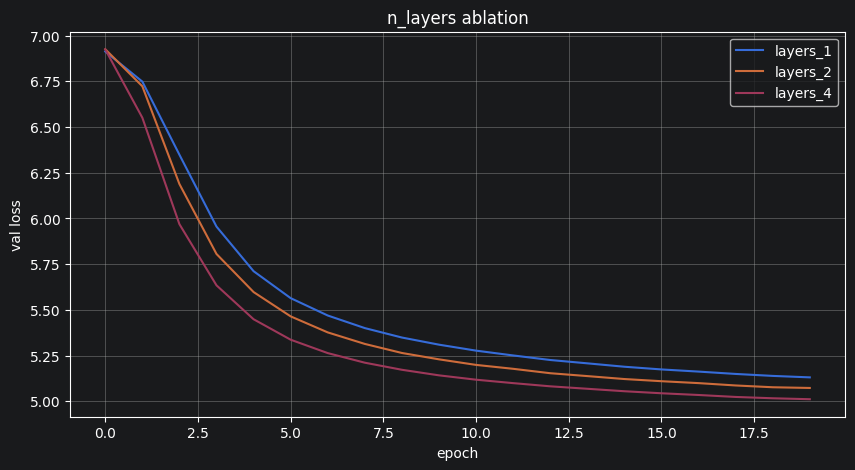

layers_1 final val: 5.1312 best val: 5.1312 elapsed: 34.1
layers_2 final val: 5.0733 best val: 5.0733 elapsed: 50.1
layers_4 final val: 5.0118 best val: 5.0118 elapsed: 87.8


In [44]:
# ABLATION_N_LAYERS
n_layers_results = run_ablation(
    "n_layers",
    [
        ("layers_1", {"n_layers": 1}),
        ("layers_2", {"n_layers": 2}),
        ("layers_4", {"n_layers": 4}),
    ],
    epochs=20,
)


이건 32번째 코드 셀이에요


n_heads heads_2
n_heads/heads_2 epoch 001 train 7.0562 val 6.9259
n_heads/heads_2 epoch 002 train 6.8734 val 6.7238
n_heads/heads_2 epoch 003 train 6.5173 val 6.1879
n_heads/heads_2 epoch 004 train 6.0601 val 5.8086
n_heads/heads_2 epoch 005 train 5.7794 val 5.5999
n_heads/heads_2 epoch 006 train 5.6013 val 5.4657
n_heads/heads_2 epoch 007 train 5.4776 val 5.3774
n_heads/heads_2 epoch 008 train 5.3865 val 5.3137
n_heads/heads_2 epoch 009 train 5.3178 val 5.2631
n_heads/heads_2 epoch 010 train 5.2618 val 5.2281
n_heads/heads_2 epoch 011 train 5.2178 val 5.1979
n_heads/heads_2 epoch 012 train 5.1794 val 5.1759
n_heads/heads_2 epoch 013 train 5.1465 val 5.1511
n_heads/heads_2 epoch 014 train 5.1185 val 5.1346
n_heads/heads_2 epoch 015 train 5.0929 val 5.1190
n_heads/heads_2 epoch 016 train 5.0712 val 5.1054
n_heads/heads_2 epoch 017 train 5.0500 val 5.0944
n_heads/heads_2 epoch 018 train 5.0301 val 5.0827
n_heads/heads_2 epoch 019 train 5.0133 val 5.0725
n_heads/heads_2 epoch 020 train 4.

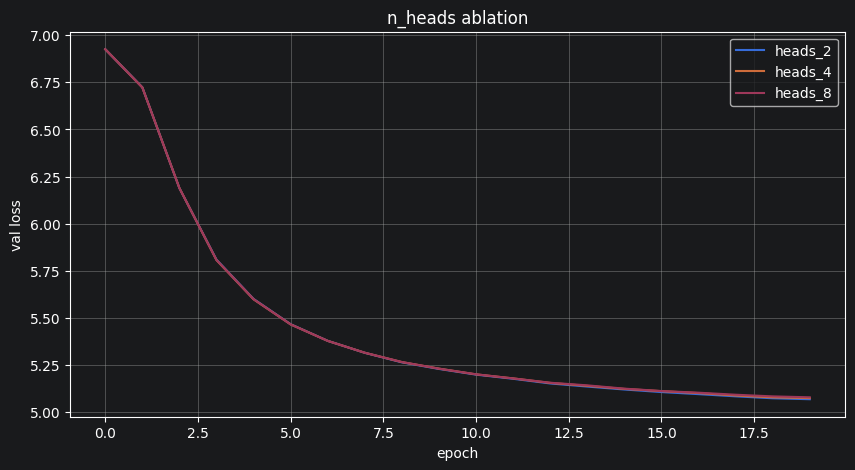

heads_2 final val: 5.0674 best val: 5.0674 elapsed: 53.4
heads_4 final val: 5.0733 best val: 5.0733 elapsed: 50.7
heads_8 final val: 5.0776 best val: 5.0776 elapsed: 51.5


In [45]:
# ABLATION_N_HEADS
n_heads_results = run_ablation(
    "n_heads",
    [
        ("heads_2", {"n_heads": 2}),
        ("heads_4", {"n_heads": 4}),
        ("heads_8", {"n_heads": 8}),
    ],
    epochs=20,
)


이건 33번째 코드 셀이에요


ffn_mult mult_2
ffn_mult/mult_2 epoch 001 train 7.0706 val 6.9278
ffn_mult/mult_2 epoch 002 train 6.9008 val 6.8147
ffn_mult/mult_2 epoch 003 train 6.6518 val 6.3893
ffn_mult/mult_2 epoch 004 train 6.2242 val 5.9567
ffn_mult/mult_2 epoch 005 train 5.9103 val 5.7230
ffn_mult/mult_2 epoch 006 train 5.7185 val 5.5786
ffn_mult/mult_2 epoch 007 train 5.5881 val 5.4813
ffn_mult/mult_2 epoch 008 train 5.4914 val 5.4083
ffn_mult/mult_2 epoch 009 train 5.4163 val 5.3517
ffn_mult/mult_2 epoch 010 train 5.3561 val 5.3083
ffn_mult/mult_2 epoch 011 train 5.3057 val 5.2725
ffn_mult/mult_2 epoch 012 train 5.2648 val 5.2463
ffn_mult/mult_2 epoch 013 train 5.2281 val 5.2185
ffn_mult/mult_2 epoch 014 train 5.1973 val 5.1991
ffn_mult/mult_2 epoch 015 train 5.1682 val 5.1792
ffn_mult/mult_2 epoch 016 train 5.1432 val 5.1634
ffn_mult/mult_2 epoch 017 train 5.1215 val 5.1506
ffn_mult/mult_2 epoch 018 train 5.1019 val 5.1374
ffn_mult/mult_2 epoch 019 train 5.0820 val 5.1256
ffn_mult/mult_2 epoch 020 train 5.

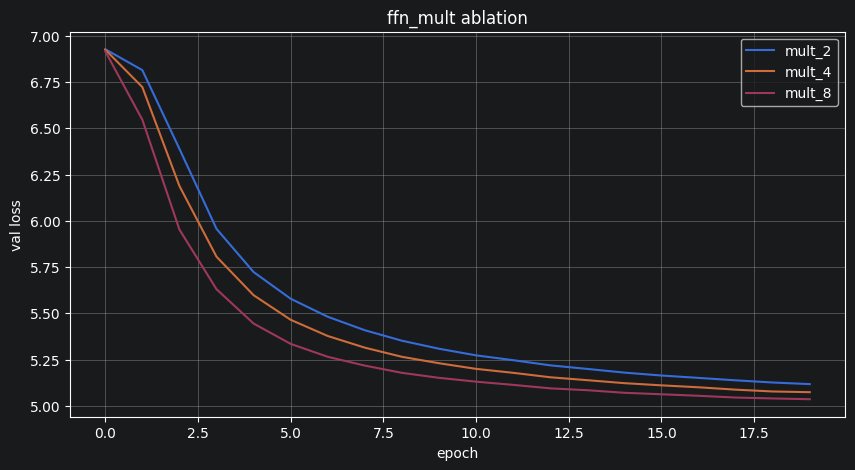

mult_2 final val: 5.117 best val: 5.117 elapsed: 51.2
mult_4 final val: 5.0733 best val: 5.0733 elapsed: 52.6
mult_8 final val: 5.0353 best val: 5.0353 elapsed: 52.8


In [46]:
# ABLATION_FFN_MULT
ffn_mult_results = run_ablation(
    "ffn_mult",
    [
        ("mult_2", {"ffn_mult": 2}),
        ("mult_4", {"ffn_mult": 4}),
        ("mult_8", {"ffn_mult": 8}),
    ],
    epochs=20,
)


이건 34번째 코드 셀이에요


grad_clip no_clip
grad_clip/no_clip epoch 001 train 7.0561 val 6.9256
grad_clip/no_clip epoch 002 train 6.8731 val 6.7230
grad_clip/no_clip epoch 003 train 6.5174 val 6.1885
grad_clip/no_clip epoch 004 train 6.0586 val 5.8060
grad_clip/no_clip epoch 005 train 5.7780 val 5.5978
grad_clip/no_clip epoch 006 train 5.5989 val 5.4648
grad_clip/no_clip epoch 007 train 5.4760 val 5.3771
grad_clip/no_clip epoch 008 train 5.3857 val 5.3141
grad_clip/no_clip epoch 009 train 5.3168 val 5.2646
grad_clip/no_clip epoch 010 train 5.2615 val 5.2299
grad_clip/no_clip epoch 011 train 5.2155 val 5.1994
grad_clip/no_clip epoch 012 train 5.1785 val 5.1781
grad_clip/no_clip epoch 013 train 5.1459 val 5.1540
grad_clip/no_clip epoch 014 train 5.1170 val 5.1383
grad_clip/no_clip epoch 015 train 5.0919 val 5.1222
grad_clip/no_clip epoch 016 train 5.0686 val 5.1103
grad_clip/no_clip epoch 017 train 5.0488 val 5.0998
grad_clip/no_clip epoch 018 train 5.0306 val 5.0870
grad_clip/no_clip epoch 019 train 5.0122 val 5

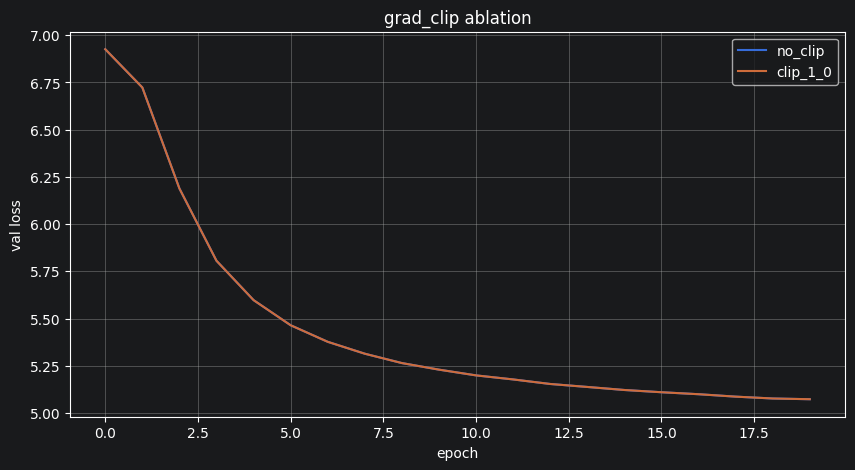

no_clip final val: 5.0733 best val: 5.0733 elapsed: 52.8
clip_1_0 final val: 5.0733 best val: 5.0733 elapsed: 51.5


In [47]:
# ABLATION_GRAD_CLIP
grad_clip_results = run_ablation(
    "grad_clip",
    [
        ("no_clip", {}),
        ("clip_1_0", {"grad_clip": 1.0}),
    ],
    epochs=20,
)


## 50 epoch ablation

Basic 설정을 기준으로 hyperparameter를 하나씩 바꿔 50 epoch씩 비교한다. 각 실험은 한 번에 하나의 값만 바꿔 영향 범위를 좁힌다.


이건 35번째 코드 셀이에요


In [48]:
# ABLATION50_COMMON_SETUP
# 50 epoch 실험에서 공통으로 쓰는 설정과 ablation 실행 함수를 모아둔 셀

from pathlib import Path
import json
import time
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, FeedForward, GELU
from src.train import calc_loss_batch, calc_loss_loader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

TRAIN_TEXT = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")
VAL_TEXT = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")

ABLATION50_EPOCHS = 50
ABLATION50_SEED = 42
ABLATION50_DIR = Path("checkpoints")
ABLATION50_FIG_DIR = Path("figures")
ABLATION50_DIR.mkdir(exist_ok=True)
ABLATION50_FIG_DIR.mkdir(exist_ok=True)

TOKENIZER_CACHE = {}
IDS_CACHE = {}

BASE_CONFIG_50 = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


def set_seed(seed=ABLATION50_SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_tokenizer50(vocab_size):
    if vocab_size in TOKENIZER_CACHE:
        return TOKENIZER_CACHE[vocab_size]

    path = Path(f"data/vocab_ablation_{vocab_size}.json")
    tokenizer = BPETokenizer(vocab_size=vocab_size)

    if path.exists():
        tokenizer.load(path)
        print(f"tokenizer loaded: {path}")
    else:
        print(f"train tokenizer: vocab_size={vocab_size}")
        tokenizer.train(TRAIN_TEXT)
        tokenizer.save(path)
        print(f"tokenizer saved: {path}")

    TOKENIZER_CACHE[vocab_size] = tokenizer
    return tokenizer


def get_ids50(vocab_size):
    if vocab_size in IDS_CACHE:
        return IDS_CACHE[vocab_size]

    tokenizer = get_tokenizer50(vocab_size)
    train_ids = tokenizer.encode(TRAIN_TEXT, add_bos_eos=False)
    val_ids = tokenizer.encode(VAL_TEXT, add_bos_eos=False)
    IDS_CACHE[vocab_size] = (train_ids, val_ids)
    print(f"encoded vocab={vocab_size}: train={len(train_ids)}, val={len(val_ids)}")
    return train_ids, val_ids


def make_activation50(name):
    if name == "gelu":
        return GELU()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    raise ValueError(name)


def apply_model_overrides50(model, config, overrides):
    activation = overrides.get("activation", "gelu")
    ffn_mult = overrides.get("ffn_mult", 4)

    for block in model.blocks:
        block.ffn = FeedForward(
            config["emb_dim"],
            dropout=config["drop_rate"],
            mult=ffn_mult,
        ).to(DEVICE)
        block.ffn.net[1] = make_activation50(activation)


def make_loader50(token_ids, context_length, batch_size, shuffle, seed):
    dataset = GPTDataset(token_ids, context_length)
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        drop_last=False,
        num_workers=0,
    )


def make_optimizer50(model, overrides):
    lr = overrides.get("learning_rate", 3e-4)
    weight_decay = overrides.get("weight_decay", 0.0)
    optimizer_name = overrides.get("optimizer", "adamw")

    if optimizer_name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(optimizer_name)


def run_one_variant50(category, label, overrides, epochs=ABLATION50_EPOCHS, seed=ABLATION50_SEED):
    set_seed(seed)

    config = dict(BASE_CONFIG_50)
    for key in ["vocab_size", "context_length", "emb_dim", "n_heads", "n_layers", "drop_rate", "qkv_bias"]:
        if key in overrides:
            config[key] = overrides[key]

    batch_size = overrides.get("batch_size", 32)
    vocab_size = config["vocab_size"]
    context_length = config["context_length"]

    train_ids, val_ids = get_ids50(vocab_size)
    train_loader = make_loader50(train_ids, context_length, batch_size, True, seed)
    val_loader = make_loader50(val_ids, context_length, batch_size, False, seed)

    model = GPTModel(config).to(DEVICE)
    apply_model_overrides50(model, config, overrides)
    optimizer = make_optimizer50(model, overrides)

    train_losses = []
    val_losses = []
    start = time.perf_counter()

    print(f"\n[{category}/{label}] start epochs={epochs} overrides={overrides}")
    print(f"train batches={len(train_loader)}, val batches={len(val_loader)}")

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()

            if overrides.get("grad_clip") is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), overrides["grad_clip"])

            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = float(sum(epoch_losses) / len(epoch_losses))
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=None)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"{category}/{label} epoch {epoch:03d}/{epochs} "
            f"train {train_loss:.4f} val {val_loss:.4f}"
        )

    elapsed = time.perf_counter() - start
    return {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "elapsed": elapsed,
        "overrides": overrides,
        "config": config,
        "batch_size": batch_size,
        "epochs": epochs,
        "seed": seed,
    }


def run_ablation50(category, variants, epochs=ABLATION50_EPOCHS, seed=ABLATION50_SEED):
    results = {}
    for label, overrides in variants:
        results[label] = run_one_variant50(category, label, overrides, epochs=epochs, seed=seed)

    out_path = ABLATION50_DIR / f"ablation50_{category}.json"
    out_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"saved: {out_path}")
    return results


def plot_ablation50(category, title=None):
    path = ABLATION50_DIR / f"ablation50_{category}.json"
    data = json.loads(path.read_text(encoding="utf-8"))

    labels = list(data.keys())
    final_vals = [data[label]["val_loss"][-1] for label in labels]
    best_idx = min(range(len(final_vals)), key=lambda i: final_vals[i])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for label in labels:
        vals = data[label]["val_loss"]
        axes[0].plot(range(1, len(vals) + 1), vals, marker="o", markersize=3, label=label)

    axes[0].set_title(f"{title or category} validation loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("validation loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    colors = ["#4e79a7"] * len(labels)
    colors[best_idx] = "#59a14f"
    bars = axes[1].bar(labels, final_vals, color=colors)
    axes[1].set_title("final validation loss")
    axes[1].set_ylabel("validation loss")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].tick_params(axis="x", rotation=25)

    for bar, val in zip(bars, final_vals):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    fig.suptitle(f"50 epoch ablation: {title or category}")
    fig.tight_layout()

    out_path = ABLATION50_FIG_DIR / f"ablation50_{category}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"saved: {out_path}")


device: cuda


### ABLATION50 - Activation


이건 36번째 코드 셀이에요


In [49]:
# ABLATION50_ACTIVATION_TRAIN
activation50_results = run_ablation50(
    "activation",
    [
        ("gelu", {"activation": "gelu"}),
        ("relu", {"activation": "relu"}),
        ("silu", {"activation": "silu"}),
        ("sigmoid", {"activation": "sigmoid"}),
    ],
    epochs=50,
)


tokenizer loaded: data\vocab_ablation_2000.json
encoded vocab=2000: train=900849, val=78686

[activation/gelu] start epochs=50 overrides={'activation': 'gelu'}
train batches=220, val batches=20
activation/gelu epoch 001/50 train 7.0622 val 6.9266
activation/gelu epoch 002/50 train 6.8764 val 6.7386
activation/gelu epoch 003/50 train 6.5212 val 6.1774
activation/gelu epoch 004/50 train 6.0501 val 5.7988
activation/gelu epoch 005/50 train 5.7660 val 5.5858
activation/gelu epoch 006/50 train 5.5889 val 5.4563
activation/gelu epoch 007/50 train 5.4683 val 5.3702
activation/gelu epoch 008/50 train 5.3792 val 5.3074
activation/gelu epoch 009/50 train 5.3115 val 5.2601
activation/gelu epoch 010/50 train 5.2573 val 5.2232
activation/gelu epoch 011/50 train 5.2140 val 5.1986
activation/gelu epoch 012/50 train 5.1765 val 5.1701
activation/gelu epoch 013/50 train 5.1441 val 5.1517
activation/gelu epoch 014/50 train 5.1156 val 5.1347
activation/gelu epoch 015/50 train 5.0911 val 5.1184
activation/

이건 37번째 코드 셀이에요


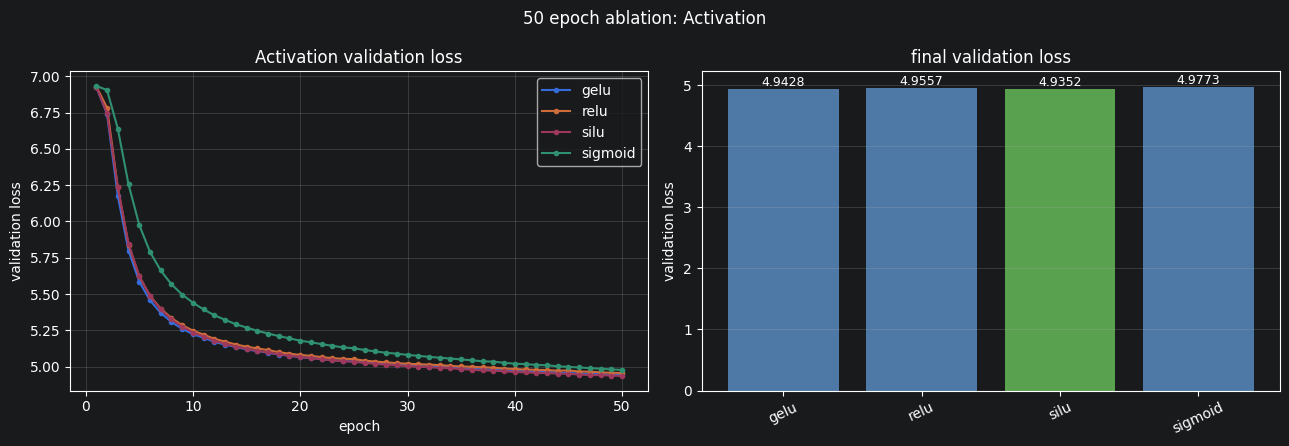

saved: figures\ablation50_activation.png


In [50]:
# ABLATION50_ACTIVATION_PLOT
plot_ablation50("activation", "Activation")


### ABLATION50 - Dropout


이건 38번째 코드 셀이에요


In [51]:
# ABLATION50_DROPOUT_TRAIN
dropout50_results = run_ablation50(
    "dropout",
    [
        ("drop_0_0", {"drop_rate": 0.0}),
        ("drop_0_1", {"drop_rate": 0.1}),
        ("drop_0_3", {"drop_rate": 0.3}),
    ],
    epochs=50,
)



[dropout/drop_0_0] start epochs=50 overrides={'drop_rate': 0.0}
train batches=220, val batches=20
dropout/drop_0_0 epoch 001/50 train 7.0505 val 6.9235
dropout/drop_0_0 epoch 002/50 train 6.8243 val 6.6307
dropout/drop_0_0 epoch 003/50 train 6.2732 val 5.9926
dropout/drop_0_0 epoch 004/50 train 5.7764 val 5.6667
dropout/drop_0_0 epoch 005/50 train 5.5071 val 5.4798
dropout/drop_0_0 epoch 006/50 train 5.3412 val 5.3692
dropout/drop_0_0 epoch 007/50 train 5.2282 val 5.2968
dropout/drop_0_0 epoch 008/50 train 5.1443 val 5.2438
dropout/drop_0_0 epoch 009/50 train 5.0778 val 5.2052
dropout/drop_0_0 epoch 010/50 train 5.0237 val 5.1787
dropout/drop_0_0 epoch 011/50 train 4.9770 val 5.1595
dropout/drop_0_0 epoch 012/50 train 4.9363 val 5.1388
dropout/drop_0_0 epoch 013/50 train 4.9001 val 5.1269
dropout/drop_0_0 epoch 014/50 train 4.8667 val 5.1168
dropout/drop_0_0 epoch 015/50 train 4.8362 val 5.1095
dropout/drop_0_0 epoch 016/50 train 4.8078 val 5.1047
dropout/drop_0_0 epoch 017/50 train 4

이건 39번째 코드 셀이에요


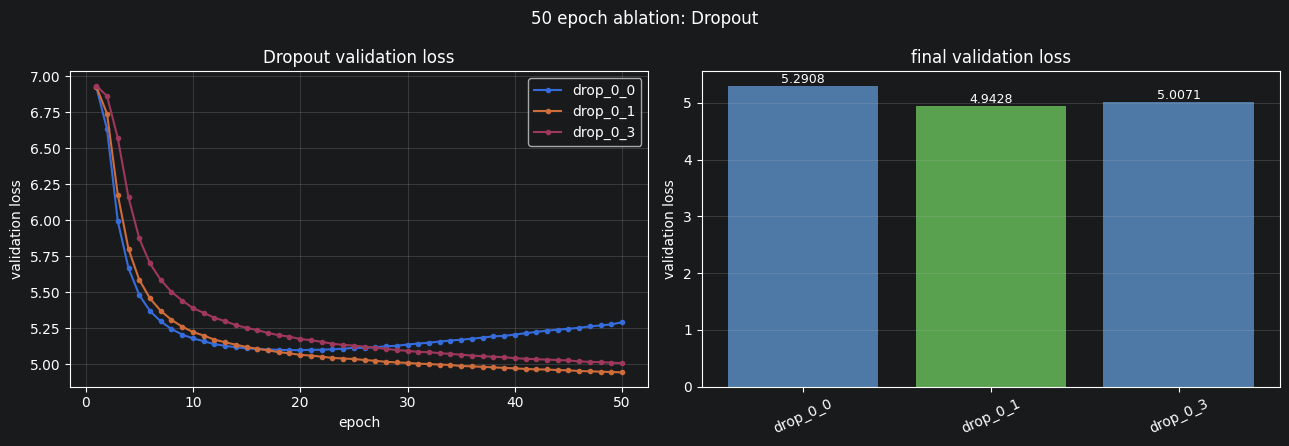

saved: figures\ablation50_dropout.png


In [52]:
# ABLATION50_DROPOUT_PLOT
plot_ablation50("dropout", "Dropout")


### ABLATION50 - Learning rate


이건 40번째 코드 셀이에요


In [53]:
# ABLATION50_LEARNING_RATE_TRAIN
learning_rate50_results = run_ablation50(
    "learning_rate",
    [
        ("lr_1e_4", {"learning_rate": 1e-4}),
        ("lr_3e_4", {"learning_rate": 3e-4}),
        ("lr_1e_3", {"learning_rate": 1e-3}),
    ],
    epochs=50,
)



[learning_rate/lr_1e_4] start epochs=50 overrides={'learning_rate': 0.0001}
train batches=220, val batches=20
learning_rate/lr_1e_4 epoch 001/50 train 7.2626 val 6.9456
learning_rate/lr_1e_4 epoch 002/50 train 6.9416 val 6.9307
learning_rate/lr_1e_4 epoch 003/50 train 6.9317 val 6.9213
learning_rate/lr_1e_4 epoch 004/50 train 6.9152 val 6.8937
learning_rate/lr_1e_4 epoch 005/50 train 6.8654 val 6.8118
learning_rate/lr_1e_4 epoch 006/50 train 6.7660 val 6.6799
learning_rate/lr_1e_4 epoch 007/50 train 6.6275 val 6.5076
learning_rate/lr_1e_4 epoch 008/50 train 6.4563 val 6.3079
learning_rate/lr_1e_4 epoch 009/50 train 6.2844 val 6.1428
learning_rate/lr_1e_4 epoch 010/50 train 6.1431 val 6.0094
learning_rate/lr_1e_4 epoch 011/50 train 6.0277 val 5.9006
learning_rate/lr_1e_4 epoch 012/50 train 5.9310 val 5.8103
learning_rate/lr_1e_4 epoch 013/50 train 5.8468 val 5.7339
learning_rate/lr_1e_4 epoch 014/50 train 5.7743 val 5.6689
learning_rate/lr_1e_4 epoch 015/50 train 5.7114 val 5.6116
lear

이건 41번째 코드 셀이에요


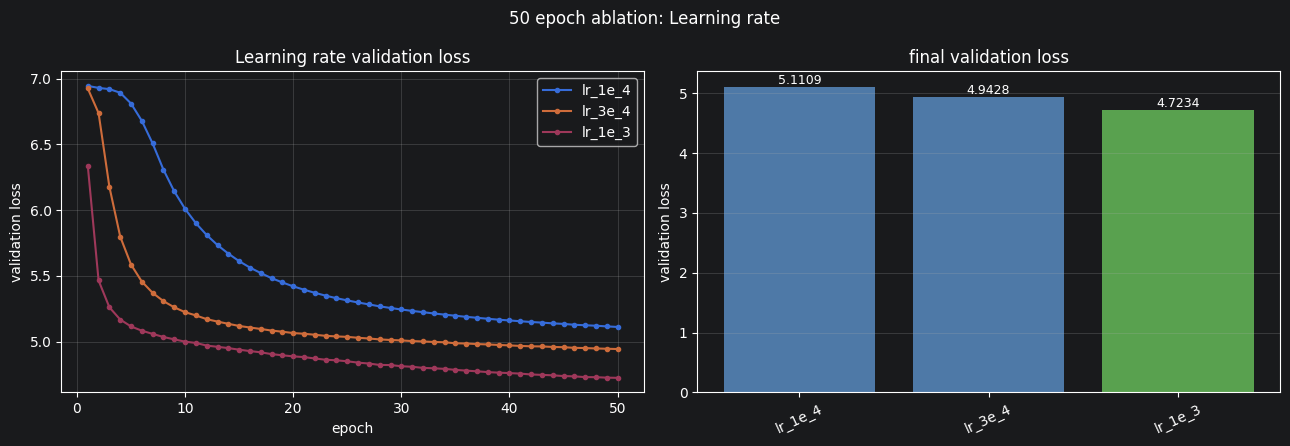

saved: figures\ablation50_learning_rate.png


In [54]:
# ABLATION50_LEARNING_RATE_PLOT
plot_ablation50("learning_rate", "Learning rate")


### ABLATION50 - Optimizer and weight decay


이건 42번째 코드 셀이에요


In [55]:
# ABLATION50_OPTIMIZER_WEIGHT_DECAY_TRAIN
optimizer_weight_decay50_results = run_ablation50(
    "optimizer_weight_decay",
    [
        ("adamw_wd_0", {"optimizer": "adamw", "weight_decay": 0.0}),
        ("adamw_wd_0_01", {"optimizer": "adamw", "weight_decay": 0.01}),
        ("adam_wd_0", {"optimizer": "adam", "weight_decay": 0.0}),
        ("sgd_lr_1e_2", {"optimizer": "sgd", "learning_rate": 1e-2}),
    ],
    epochs=50,
)



[optimizer_weight_decay/adamw_wd_0] start epochs=50 overrides={'optimizer': 'adamw', 'weight_decay': 0.0}
train batches=220, val batches=20
optimizer_weight_decay/adamw_wd_0 epoch 001/50 train 7.0622 val 6.9266
optimizer_weight_decay/adamw_wd_0 epoch 002/50 train 6.8764 val 6.7386
optimizer_weight_decay/adamw_wd_0 epoch 003/50 train 6.5212 val 6.1774
optimizer_weight_decay/adamw_wd_0 epoch 004/50 train 6.0501 val 5.7988
optimizer_weight_decay/adamw_wd_0 epoch 005/50 train 5.7660 val 5.5858
optimizer_weight_decay/adamw_wd_0 epoch 006/50 train 5.5889 val 5.4563
optimizer_weight_decay/adamw_wd_0 epoch 007/50 train 5.4683 val 5.3702
optimizer_weight_decay/adamw_wd_0 epoch 008/50 train 5.3792 val 5.3074
optimizer_weight_decay/adamw_wd_0 epoch 009/50 train 5.3115 val 5.2601
optimizer_weight_decay/adamw_wd_0 epoch 010/50 train 5.2573 val 5.2232
optimizer_weight_decay/adamw_wd_0 epoch 011/50 train 5.2140 val 5.1986
optimizer_weight_decay/adamw_wd_0 epoch 012/50 train 5.1765 val 5.1701
optimiz

이건 43번째 코드 셀이에요


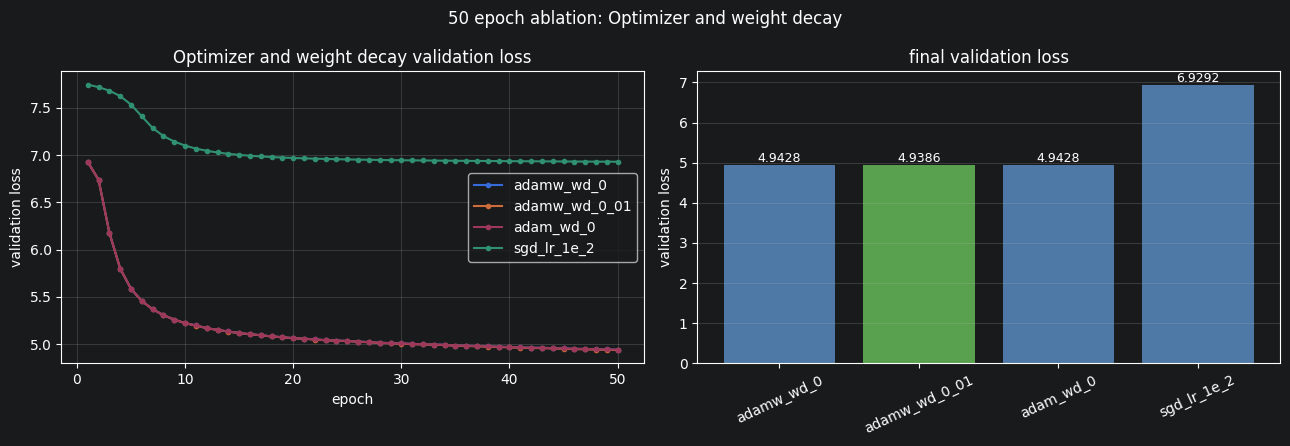

saved: figures\ablation50_optimizer_weight_decay.png


In [56]:
# ABLATION50_OPTIMIZER_WEIGHT_DECAY_PLOT
plot_ablation50("optimizer_weight_decay", "Optimizer and weight decay")


### ABLATION50 - Context length


이건 44번째 코드 셀이에요


In [57]:
# ABLATION50_CONTEXT_LENGTH_TRAIN
context_length50_results = run_ablation50(
    "context_length",
    [
        ("ctx_64", {"context_length": 64}),
        ("ctx_128", {"context_length": 128}),
        ("ctx_256", {"context_length": 256}),
    ],
    epochs=50,
)



[context_length/ctx_64] start epochs=50 overrides={'context_length': 64}
train batches=440, val batches=39
context_length/ctx_64 epoch 001/50 train 7.0005 val 6.8697
context_length/ctx_64 epoch 002/50 train 6.5559 val 6.0686
context_length/ctx_64 epoch 003/50 train 5.9072 val 5.6117
context_length/ctx_64 epoch 004/50 train 5.5870 val 5.4054
context_length/ctx_64 epoch 005/50 train 5.4140 val 5.2949
context_length/ctx_64 epoch 006/50 train 5.3044 val 5.2193
context_length/ctx_64 epoch 007/50 train 5.2286 val 5.1734
context_length/ctx_64 epoch 008/50 train 5.1708 val 5.1310
context_length/ctx_64 epoch 009/50 train 5.1242 val 5.1025
context_length/ctx_64 epoch 010/50 train 5.0849 val 5.0762
context_length/ctx_64 epoch 011/50 train 5.0495 val 5.0554
context_length/ctx_64 epoch 012/50 train 5.0216 val 5.0361
context_length/ctx_64 epoch 013/50 train 4.9948 val 5.0191
context_length/ctx_64 epoch 014/50 train 4.9699 val 5.0049
context_length/ctx_64 epoch 015/50 train 4.9480 val 4.9879
context

이건 45번째 코드 셀이에요


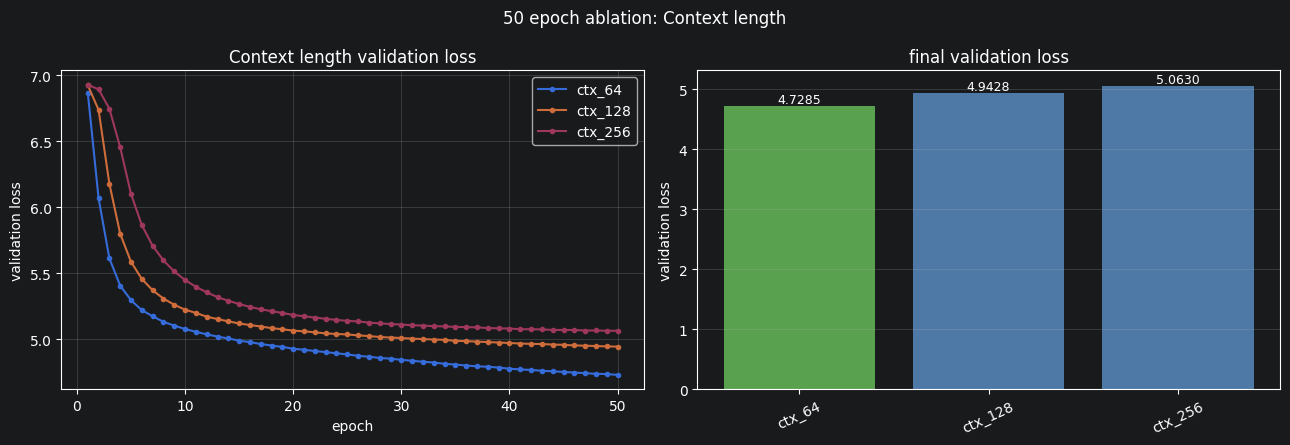

saved: figures\ablation50_context_length.png


In [58]:
# ABLATION50_CONTEXT_LENGTH_PLOT
plot_ablation50("context_length", "Context length")


### ABLATION50 - Vocab size


이건 46번째 코드 셀이에요


In [59]:
# ABLATION50_VOCAB_SIZE_TRAIN
vocab_size50_results = run_ablation50(
    "vocab_size",
    [
        ("vocab_1000", {"vocab_size": 1000}),
        ("vocab_2000", {"vocab_size": 2000}),
        ("vocab_4000", {"vocab_size": 4000}),
    ],
    epochs=50,
)


tokenizer loaded: data\vocab_ablation_1000.json
encoded vocab=1000: train=1138662, val=99258

[vocab_size/vocab_1000] start epochs=50 overrides={'vocab_size': 1000}
train batches=278, val batches=25
vocab_size/vocab_1000 epoch 001/50 train 6.2620 val 5.8322
vocab_size/vocab_1000 epoch 002/50 train 5.4127 val 4.9932
vocab_size/vocab_1000 epoch 003/50 train 4.9290 val 4.7131
vocab_size/vocab_1000 epoch 004/50 train 4.7259 val 4.5840
vocab_size/vocab_1000 epoch 005/50 train 4.6148 val 4.5117
vocab_size/vocab_1000 epoch 006/50 train 4.5432 val 4.4598
vocab_size/vocab_1000 epoch 007/50 train 4.4911 val 4.4195
vocab_size/vocab_1000 epoch 008/50 train 4.4484 val 4.3882
vocab_size/vocab_1000 epoch 009/50 train 4.4117 val 4.3612
vocab_size/vocab_1000 epoch 010/50 train 4.3804 val 4.3322
vocab_size/vocab_1000 epoch 011/50 train 4.3516 val 4.3042
vocab_size/vocab_1000 epoch 012/50 train 4.3242 val 4.2815
vocab_size/vocab_1000 epoch 013/50 train 4.2995 val 4.2588
vocab_size/vocab_1000 epoch 014/50

이건 47번째 코드 셀이에요


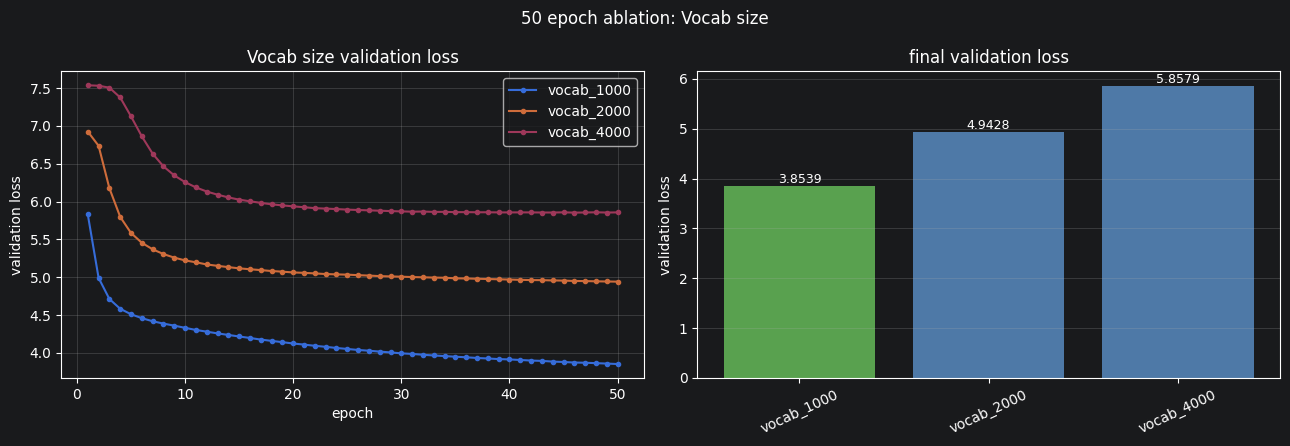

saved: figures\ablation50_vocab_size.png


In [60]:
# ABLATION50_VOCAB_SIZE_PLOT
plot_ablation50("vocab_size", "Vocab size")


### ABLATION50 - Embedding dimension


이건 48번째 코드 셀이에요


In [61]:
# ABLATION50_EMB_DIM_TRAIN
emb_dim50_results = run_ablation50(
    "emb_dim",
    [
        ("emb_64", {"emb_dim": 64}),
        ("emb_128", {"emb_dim": 128}),
        ("emb_256", {"emb_dim": 256}),
    ],
    epochs=50,
)



[emb_dim/emb_64] start epochs=50 overrides={'emb_dim': 64}
train batches=220, val batches=20
emb_dim/emb_64 epoch 001/50 train 7.1534 val 6.9366
emb_dim/emb_64 epoch 002/50 train 6.9371 val 6.9263
emb_dim/emb_64 epoch 003/50 train 6.9167 val 6.8822
emb_dim/emb_64 epoch 004/50 train 6.8282 val 6.7238
emb_dim/emb_64 epoch 005/50 train 6.6440 val 6.4772
emb_dim/emb_64 epoch 006/50 train 6.4186 val 6.2289
emb_dim/emb_64 epoch 007/50 train 6.2127 val 6.0344
emb_dim/emb_64 epoch 008/50 train 6.0493 val 5.8835
emb_dim/emb_64 epoch 009/50 train 5.9219 val 5.7701
emb_dim/emb_64 epoch 010/50 train 5.8196 val 5.6801
emb_dim/emb_64 epoch 011/50 train 5.7363 val 5.6106
emb_dim/emb_64 epoch 012/50 train 5.6693 val 5.5510
emb_dim/emb_64 epoch 013/50 train 5.6105 val 5.5022
emb_dim/emb_64 epoch 014/50 train 5.5616 val 5.4597
emb_dim/emb_64 epoch 015/50 train 5.5185 val 5.4242
emb_dim/emb_64 epoch 016/50 train 5.4804 val 5.3931
emb_dim/emb_64 epoch 017/50 train 5.4467 val 5.3670
emb_dim/emb_64 epoch 0

이건 49번째 코드 셀이에요


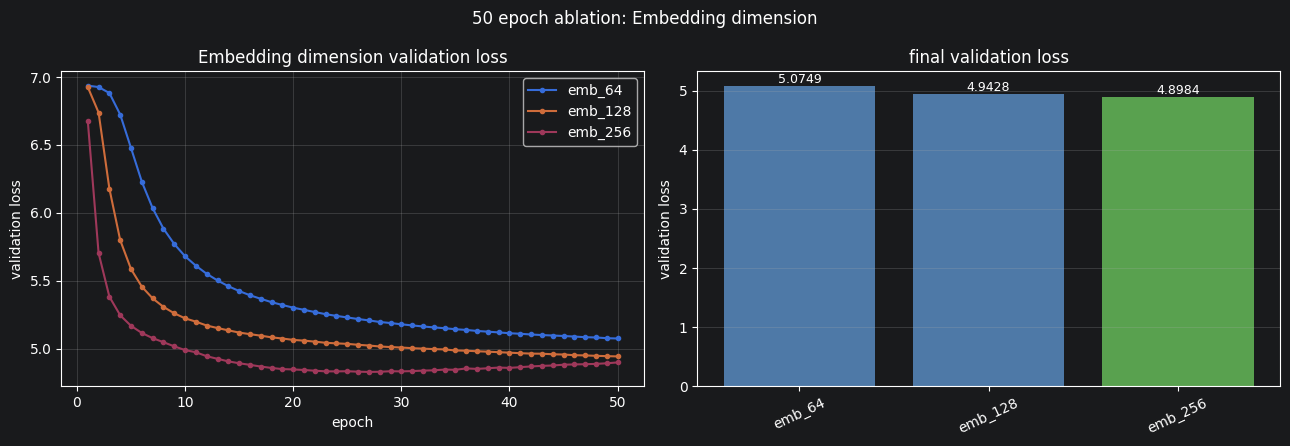

saved: figures\ablation50_emb_dim.png


In [62]:
# ABLATION50_EMB_DIM_PLOT
plot_ablation50("emb_dim", "Embedding dimension")


### ABLATION50 - Number of layers


이건 50번째 코드 셀이에요


In [63]:
# ABLATION50_N_LAYERS_TRAIN
n_layers50_results = run_ablation50(
    "n_layers",
    [
        ("layers_1", {"n_layers": 1}),
        ("layers_2", {"n_layers": 2}),
        ("layers_4", {"n_layers": 4}),
    ],
    epochs=50,
)



[n_layers/layers_1] start epochs=50 overrides={'n_layers': 1}
train batches=220, val batches=20
n_layers/layers_1 epoch 001/50 train 7.1132 val 6.9125
n_layers/layers_1 epoch 002/50 train 6.8690 val 6.7612
n_layers/layers_1 epoch 003/50 train 6.6252 val 6.3897
n_layers/layers_1 epoch 004/50 train 6.2470 val 5.9803
n_layers/layers_1 epoch 005/50 train 5.9212 val 5.7171
n_layers/layers_1 epoch 006/50 train 5.7120 val 5.5639
n_layers/layers_1 epoch 007/50 train 5.5757 val 5.4665
n_layers/layers_1 epoch 008/50 train 5.4802 val 5.3955
n_layers/layers_1 epoch 009/50 train 5.4081 val 5.3445
n_layers/layers_1 epoch 010/50 train 5.3503 val 5.3041
n_layers/layers_1 epoch 011/50 train 5.3043 val 5.2729
n_layers/layers_1 epoch 012/50 train 5.2662 val 5.2448
n_layers/layers_1 epoch 013/50 train 5.2324 val 5.2224
n_layers/layers_1 epoch 014/50 train 5.2014 val 5.2031
n_layers/layers_1 epoch 015/50 train 5.1758 val 5.1850
n_layers/layers_1 epoch 016/50 train 5.1517 val 5.1705
n_layers/layers_1 epoch

이건 51번째 코드 셀이에요


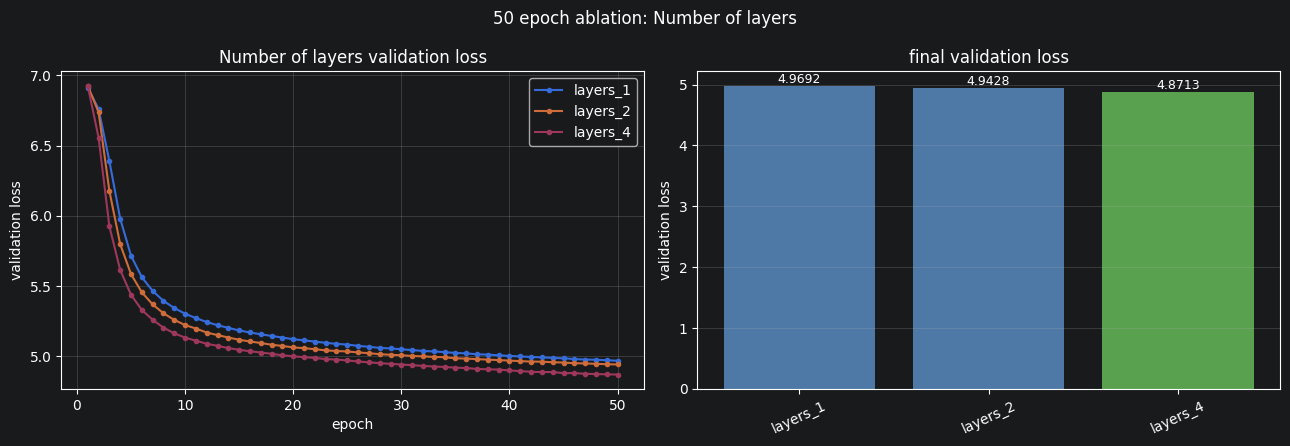

saved: figures\ablation50_n_layers.png


In [64]:
# ABLATION50_N_LAYERS_PLOT
plot_ablation50("n_layers", "Number of layers")


### ABLATION50 - Number of heads


이건 52번째 코드 셀이에요


In [65]:
# ABLATION50_N_HEADS_TRAIN
n_heads50_results = run_ablation50(
    "n_heads",
    [
        ("heads_2", {"n_heads": 2}),
        ("heads_4", {"n_heads": 4}),
        ("heads_8", {"n_heads": 8}),
    ],
    epochs=50,
)



[n_heads/heads_2] start epochs=50 overrides={'n_heads': 2}
train batches=220, val batches=20
n_heads/heads_2 epoch 001/50 train 7.0624 val 6.9267
n_heads/heads_2 epoch 002/50 train 6.8768 val 6.7391
n_heads/heads_2 epoch 003/50 train 6.5222 val 6.1799
n_heads/heads_2 epoch 004/50 train 6.0526 val 5.8043
n_heads/heads_2 epoch 005/50 train 5.7700 val 5.5906
n_heads/heads_2 epoch 006/50 train 5.5925 val 5.4602
n_heads/heads_2 epoch 007/50 train 5.4711 val 5.3741
n_heads/heads_2 epoch 008/50 train 5.3825 val 5.3092
n_heads/heads_2 epoch 009/50 train 5.3144 val 5.2621
n_heads/heads_2 epoch 010/50 train 5.2616 val 5.2249
n_heads/heads_2 epoch 011/50 train 5.2167 val 5.1980
n_heads/heads_2 epoch 012/50 train 5.1789 val 5.1709
n_heads/heads_2 epoch 013/50 train 5.1470 val 5.1524
n_heads/heads_2 epoch 014/50 train 5.1175 val 5.1354
n_heads/heads_2 epoch 015/50 train 5.0940 val 5.1187
n_heads/heads_2 epoch 016/50 train 5.0709 val 5.1055
n_heads/heads_2 epoch 017/50 train 5.0499 val 5.0937
n_hea

이건 53번째 코드 셀이에요


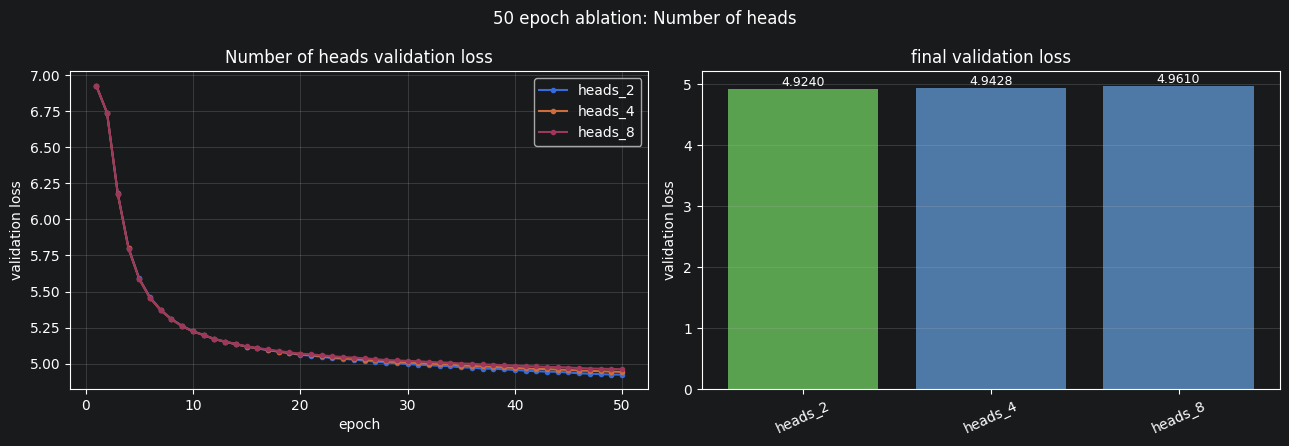

saved: figures\ablation50_n_heads.png


In [66]:
# ABLATION50_N_HEADS_PLOT
plot_ablation50("n_heads", "Number of heads")


### ABLATION50 - FFN expansion ratio


이건 54번째 코드 셀이에요


In [67]:
# ABLATION50_FFN_MULT_TRAIN
ffn_mult50_results = run_ablation50(
    "ffn_mult",
    [
        ("mult_2", {"ffn_mult": 2}),
        ("mult_4", {"ffn_mult": 4}),
        ("mult_8", {"ffn_mult": 8}),
    ],
    epochs=50,
)



[ffn_mult/mult_2] start epochs=50 overrides={'ffn_mult': 2}
train batches=220, val batches=20
ffn_mult/mult_2 epoch 001/50 train 7.0785 val 6.9282
ffn_mult/mult_2 epoch 002/50 train 6.9005 val 6.8149
ffn_mult/mult_2 epoch 003/50 train 6.6549 val 6.3841
ffn_mult/mult_2 epoch 004/50 train 6.2198 val 5.9576
ffn_mult/mult_2 epoch 005/50 train 5.9029 val 5.7195
ffn_mult/mult_2 epoch 006/50 train 5.7093 val 5.5732
ffn_mult/mult_2 epoch 007/50 train 5.5784 val 5.4759
ffn_mult/mult_2 epoch 008/50 train 5.4819 val 5.4042
ffn_mult/mult_2 epoch 009/50 train 5.4089 val 5.3497
ffn_mult/mult_2 epoch 010/50 train 5.3498 val 5.3059
ffn_mult/mult_2 epoch 011/50 train 5.3020 val 5.2736
ffn_mult/mult_2 epoch 012/50 train 5.2605 val 5.2432
ffn_mult/mult_2 epoch 013/50 train 5.2243 val 5.2189
ffn_mult/mult_2 epoch 014/50 train 5.1941 val 5.1974
ffn_mult/mult_2 epoch 015/50 train 5.1677 val 5.1804
ffn_mult/mult_2 epoch 016/50 train 5.1420 val 5.1634
ffn_mult/mult_2 epoch 017/50 train 5.1189 val 5.1501
ffn_

이건 55번째 코드 셀이에요


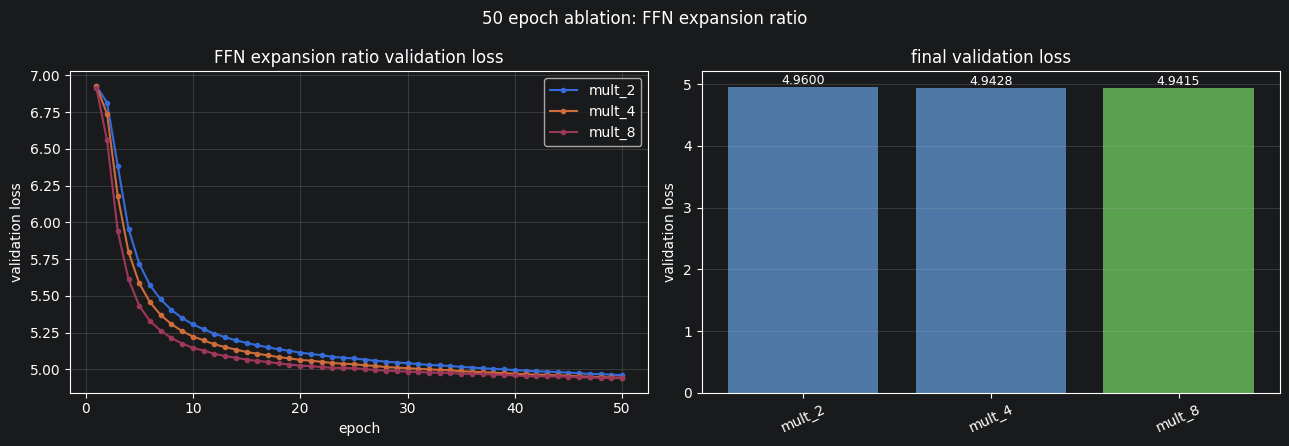

saved: figures\ablation50_ffn_mult.png


In [68]:
# ABLATION50_FFN_MULT_PLOT
plot_ablation50("ffn_mult", "FFN expansion ratio")


### ABLATION50 - Gradient clipping


이건 56번째 코드 셀이에요


In [69]:
# ABLATION50_GRAD_CLIP_TRAIN
grad_clip50_results = run_ablation50(
    "grad_clip",
    [
        ("no_clip", {}),
        ("clip_1_0", {"grad_clip": 1.0}),
    ],
    epochs=50,
)



[grad_clip/no_clip] start epochs=50 overrides={}
train batches=220, val batches=20
grad_clip/no_clip epoch 001/50 train 7.0622 val 6.9266
grad_clip/no_clip epoch 002/50 train 6.8764 val 6.7386
grad_clip/no_clip epoch 003/50 train 6.5212 val 6.1774
grad_clip/no_clip epoch 004/50 train 6.0501 val 5.7988
grad_clip/no_clip epoch 005/50 train 5.7660 val 5.5858
grad_clip/no_clip epoch 006/50 train 5.5889 val 5.4563
grad_clip/no_clip epoch 007/50 train 5.4683 val 5.3702
grad_clip/no_clip epoch 008/50 train 5.3792 val 5.3074
grad_clip/no_clip epoch 009/50 train 5.3115 val 5.2601
grad_clip/no_clip epoch 010/50 train 5.2573 val 5.2232
grad_clip/no_clip epoch 011/50 train 5.2140 val 5.1986
grad_clip/no_clip epoch 012/50 train 5.1765 val 5.1701
grad_clip/no_clip epoch 013/50 train 5.1441 val 5.1517
grad_clip/no_clip epoch 014/50 train 5.1156 val 5.1347
grad_clip/no_clip epoch 015/50 train 5.0911 val 5.1184
grad_clip/no_clip epoch 016/50 train 5.0684 val 5.1066
grad_clip/no_clip epoch 017/50 train

이건 57번째 코드 셀이에요


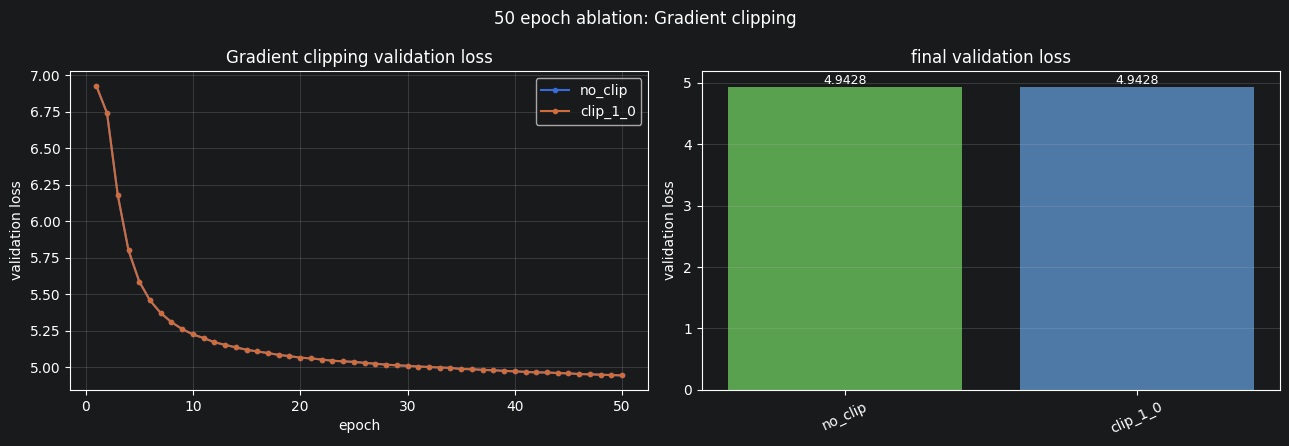

saved: figures\ablation50_grad_clip.png


In [70]:
# ABLATION50_GRAD_CLIP_PLOT
plot_ablation50("grad_clip", "Gradient clipping")


### ABLATION50 - Batch size


이건 58번째 코드 셀이에요


In [71]:
# ABLATION50_BATCH_SIZE_TRAIN
batch_size50_results = run_ablation50(
    "batch_size",
    [
        ("bs_16", {"batch_size": 16}),
        ("bs_32", {"batch_size": 32}),
        ("bs_64", {"batch_size": 64}),
    ],
    epochs=50,
)



[batch_size/bs_16] start epochs=50 overrides={'batch_size': 16}
train batches=440, val batches=39
batch_size/bs_16 epoch 001/50 train 7.0057 val 6.8828
batch_size/bs_16 epoch 002/50 train 6.6224 val 6.1771
batch_size/bs_16 epoch 003/50 train 5.9851 val 5.6921
batch_size/bs_16 epoch 004/50 train 5.6521 val 5.4753
batch_size/bs_16 epoch 005/50 train 5.4711 val 5.3566
batch_size/bs_16 epoch 006/50 train 5.3578 val 5.2820
batch_size/bs_16 epoch 007/50 train 5.2760 val 5.2340
batch_size/bs_16 epoch 008/50 train 5.2151 val 5.1925
batch_size/bs_16 epoch 009/50 train 5.1673 val 5.1617
batch_size/bs_16 epoch 010/50 train 5.1265 val 5.1381
batch_size/bs_16 epoch 011/50 train 5.0927 val 5.1228
batch_size/bs_16 epoch 012/50 train 5.0624 val 5.1007
batch_size/bs_16 epoch 013/50 train 5.0368 val 5.0864
batch_size/bs_16 epoch 014/50 train 5.0129 val 5.0735
batch_size/bs_16 epoch 015/50 train 4.9919 val 5.0631
batch_size/bs_16 epoch 016/50 train 4.9739 val 5.0497
batch_size/bs_16 epoch 017/50 train 4

이건 59번째 코드 셀이에요


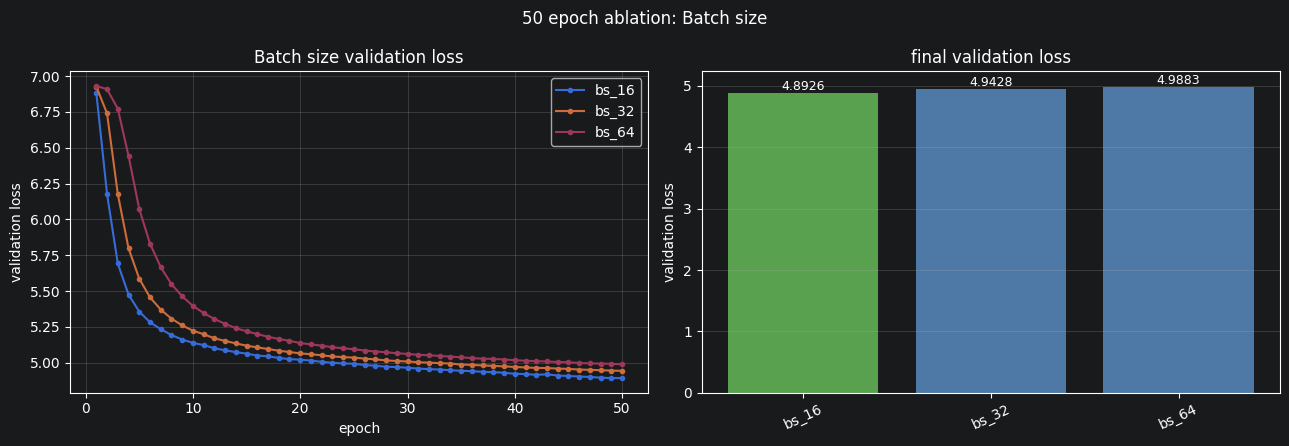

saved: figures\ablation50_batch_size.png


In [72]:
# ABLATION50_BATCH_SIZE_PLOT
plot_ablation50("batch_size", "Batch size")


## Report booster experiments

Additional cells for REPORT.md: model summary, final generation samples, and fine-tuning accuracy. The fine-tuning cell uses subset limits by default and can be expanded by setting the limits to None.


이건 60번째 코드 셀이에요


In [1]:
# REPORT_MODEL_SUMMARY
from pathlib import Path
import json

from src.model import GPTModel

REPORT_MODEL_CONFIG = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(REPORT_MODEL_CONFIG)

module_counts = {
    "embedding": sum(p.numel() for p in model.embedding.parameters()),
    "transformer_blocks": sum(p.numel() for p in model.blocks.parameters()),
    "final_norm": sum(p.numel() for p in model.final_norm.parameters()),
    "lm_head": sum(p.numel() for p in model.lm_head.parameters()),
}

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

summary = {
    "config": REPORT_MODEL_CONFIG,
    "parameter_count": total_params,
    "trainable_parameter_count": trainable_params,
    "module_parameter_counts": module_counts,
}

Path("checkpoints").mkdir(exist_ok=True)
Path("checkpoints/report_model_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("parameter count:", f"{total_params:,}")
print("trainable parameters:", f"{trainable_params:,}")
for name, count in module_counts.items():
    print(f"{name}: {count:,}")
print("saved: checkpoints/report_model_summary.json")


parameter count: 924,416
trainable parameters: 924,416
embedding: 272,384
transformer_blocks: 395,776
final_norm: 256
lm_head: 256,000
saved: checkpoints/report_model_summary.json


이건 61번째 코드 셀이에요


In [2]:
# REPORT_FINAL_GENERATION_SAMPLES
from pathlib import Path
import json

import torch

from src.bpe import BPETokenizer
from src.model import GPTModel
from src.train import load_checkpoint, generate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 123
PROMPTS = ["\uc601\ud654\uac00", "\uc815\ub9d0", "\ubc30\uc6b0\uac00", "\uc2a4\ud1a0\ub9ac\ub294"]
MAX_NEW_TOKENS = 80
TEMPERATURE = 0.8
TOP_K = 40
CHECKPOINT_PATH = "checkpoints/basic_monitor_best.pt"
TOKENIZER_PATH = "data/vocab_basic_2000.json"

config = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

tokenizer = BPETokenizer(vocab_size=config["vocab_size"])
tokenizer.load(TOKENIZER_PATH)

model = GPTModel(config).to(DEVICE)
epoch, global_step = load_checkpoint(model, None, CHECKPOINT_PATH, DEVICE)
model.eval()

samples = {
    "checkpoint": CHECKPOINT_PATH,
    "epoch": epoch,
    "global_step": global_step,
    "max_new_tokens": MAX_NEW_TOKENS,
    "temperature": TEMPERATURE,
    "top_k": TOP_K,
    "seed": SEED,
    "samples": {},
}

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

for prompt in PROMPTS:
    input_ids = tokenizer.encode(prompt, add_bos_eos=False)
    idx = torch.tensor(input_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    out = generate(
        model=model,
        idx=idx,
        max_new_tokens=MAX_NEW_TOKENS,
        context_size=config["context_length"],
        temperature=TEMPERATURE,
        top_k=TOP_K,
        eos_id=tokenizer.get_eos_id(),
    )
    text = tokenizer.decode(out[0].tolist(), skip_special=True)
    samples["samples"][prompt] = text
    print("=" * 60)
    print("prompt:", prompt)
    print(text)

Path("checkpoints").mkdir(exist_ok=True)
Path("checkpoints/report_final_generation_samples.json").write_text(
    json.dumps(samples, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("saved: checkpoints/report_final_generation_samples.json")


prompt: 영화가
영화가 몇번이나 본 영화인데도 이런 영화는 보면서 다시 보니깐 돌고갔네 ㅡ,ㅡ
김탁 김지커플리 매력있더라요
마지막 장면을 둘째치고 연기파주의 연주가 매력넘좋았습니다ㅎ
감동은 최강인은 어떤 궤벨로 상영하는 듯
prompt: 정말
정말정말너무 좋아요!
배우들의 연기는 좋으나 특별한 것을 보여주는 영화, 내용이 부여 산만하지만 영화보면서도 긴장감도 너무 지루하고, 연기가 연출도 너무 좋았고 스토리 전개도 유치하고 뻔함으로 전개도 아쉬운 부분도 있고 재미 있다는 말밖에 못하지 않을까.
이건.. 내가 15세 이상은 내 인생은 더
prompt: 배우가
배우가 다르겠는데 이건 뭐 이뻐서 1점도아깝네..
최고에요
감동적이다.
이영화는 왜이래?
아이들이 잘 봤어요!
너무 재미없는영화도 어이없음
그냥 쓰레기같은 영화. 한국영화에서 영화관에서 보시라면 더욱 공감되네요..그저그런 비슷하네요... 이영화는 미국식사회에서
prompt: 스토리는
스토리는 어쩔 수 없었음.
그냥 쓰레기통 역할인건 안쓰는데...ㅡㅡ;;;;;
그리고 이 영화는 정말 OOO기 영화...ㅡㅡ;;;
그 당신을 위한 영국, 한심한 그것만으로도 충분히 현실성을 주는 것이 아닌 흑백의 정체성이 너무 많아서 좋았어요. 특히 땜에님
saved: checkpoints/report_final_generation_samples.json


이건 62번째 코드 셀이에요


In [3]:
# REPORT_FINETUNE_ACCURACY
from pathlib import Path
import json
import random
import time

import torch
from torch.utils.data import Dataset, DataLoader

from src.bpe import BPETokenizer
from src.model import GPTModel
from src.train import load_checkpoint
from src.finetune import GPTForSequenceClassification, train_epoch_sentiment, evaluate_sentiment

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 123

# Set these limits to None to use the full dataset. Defaults use subsets for report supplementation.
TRAIN_LIMIT = 30000
VAL_LIMIT = 6000
TEST_LIMIT = 6000

NUM_EPOCHS = 3
MAX_LENGTH = 128
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
FREEZE_BACKBONE = False

TOKENIZER_PATH = "data/vocab_basic_2000.json"
CHECKPOINT_PATH = "checkpoints/basic_monitor_best.pt"
RESULT_PATH = Path("checkpoints/finetune_accuracy_report.json")

config = {
    "vocab_size": 2000,
    "context_length": 128,
    "emb_dim": 128,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}


def read_jsonl(path):
    rows = []
    with Path(path).open("r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


def stratified_limit(rows, limit, seed):
    if limit is None or limit >= len(rows):
        return rows
    rng = random.Random(seed)
    by_label = {0: [], 1: []}
    for row in rows:
        by_label[int(row["label"])].append(row)
    for label_rows in by_label.values():
        rng.shuffle(label_rows)
    half = limit // 2
    selected = by_label[0][:half] + by_label[1][: limit - half]
    rng.shuffle(selected)
    return selected


class CachedSentimentDataset(Dataset):
    def __init__(self, rows, tokenizer, max_length):
        self.items = []
        pad_id = tokenizer.get_pad_id()
        for row in rows:
            ids = tokenizer.encode(row["text"], add_bos_eos=True)[:max_length]
            ids = ids + [pad_id] * (max_length - len(ids))
            self.items.append((torch.tensor(ids, dtype=torch.long), int(row["label"])))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        return self.items[idx]


def make_loader(rows, tokenizer, shuffle, seed):
    dataset = CachedSentimentDataset(rows, tokenizer, MAX_LENGTH)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
    )


random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("device:", DEVICE)
print("load tokenizer")
tokenizer = BPETokenizer(vocab_size=config["vocab_size"])
tokenizer.load(TOKENIZER_PATH)

print("load data")
train_rows = stratified_limit(read_jsonl("data/nsmc_sentiment_train.jsonl"), TRAIN_LIMIT, SEED)
val_rows = stratified_limit(read_jsonl("data/nsmc_sentiment_val.jsonl"), VAL_LIMIT, SEED)
test_rows = stratified_limit(read_jsonl("data/nsmc_sentiment_test.jsonl"), TEST_LIMIT, SEED)
print("rows:", {"train": len(train_rows), "val": len(val_rows), "test": len(test_rows)})

print("tokenize and build loaders")
train_loader = make_loader(train_rows, tokenizer, shuffle=True, seed=SEED)
val_loader = make_loader(val_rows, tokenizer, shuffle=False, seed=SEED)
test_loader = make_loader(test_rows, tokenizer, shuffle=False, seed=SEED)

backbone = GPTModel(config).to(DEVICE)
pretrain_epoch, pretrain_step = load_checkpoint(backbone, None, CHECKPOINT_PATH, DEVICE)
model = GPTForSequenceClassification(backbone, num_labels=2, drop_rate=0.1).to(DEVICE)
model.pad_id = tokenizer.get_pad_id()

if FREEZE_BACKBONE:
    for parameter in model.gpt.parameters():
        parameter.requires_grad = False

optimizer = torch.optim.AdamW(
    [parameter for parameter in model.parameters() if parameter.requires_grad],
    lr=LEARNING_RATE,
)

history = []
start = time.perf_counter()

initial_val_loss, initial_val_acc = evaluate_sentiment(model, val_loader, DEVICE)
print(f"epoch 0: val_loss={initial_val_loss:.4f}, val_acc={initial_val_acc:.4f}")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch_sentiment(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc = evaluate_sentiment(model, val_loader, DEVICE)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    }
    history.append(row)
    print(
        f"epoch {epoch}: "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

test_loss, test_acc = evaluate_sentiment(model, test_loader, DEVICE)
elapsed = time.perf_counter() - start

result = {
    "seed": SEED,
    "checkpoint": CHECKPOINT_PATH,
    "pretrain_epoch": pretrain_epoch,
    "pretrain_global_step": pretrain_step,
    "train_limit": TRAIN_LIMIT,
    "val_limit": VAL_LIMIT,
    "test_limit": TEST_LIMIT,
    "num_epochs": NUM_EPOCHS,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "freeze_backbone": FREEZE_BACKBONE,
    "initial_val_loss": initial_val_loss,
    "initial_val_acc": initial_val_acc,
    "history": history,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "elapsed_sec": elapsed,
}

RESULT_PATH.parent.mkdir(exist_ok=True)
RESULT_PATH.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

print("test_loss:", f"{test_loss:.4f}")
print("test_acc:", f"{test_acc:.4f}")
print("elapsed_sec:", f"{elapsed:.1f}")
print("saved:", RESULT_PATH)


device: cuda
load tokenizer
load data
rows: {'train': 30000, 'val': 6000, 'test': 6000}
tokenize and build loaders
epoch 0: val_loss=1.4921, val_acc=0.5005
epoch 1: train_loss=0.5786, train_acc=0.6996, val_loss=0.4674, val_acc=0.7782
epoch 2: train_loss=0.4779, train_acc=0.7683, val_loss=0.4469, val_acc=0.7907
epoch 3: train_loss=0.4502, train_acc=0.7855, val_loss=0.4273, val_acc=0.8003
test_loss: 0.4224
test_acc: 0.8022
elapsed_sec: 15.8
saved: checkpoints\finetune_accuracy_report.json


이건 63번째 코드 셀이에요


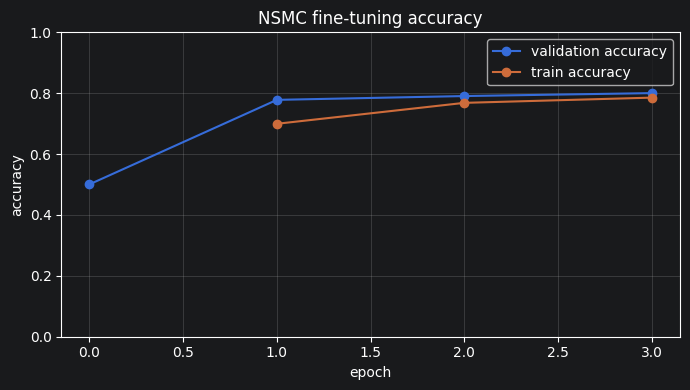

saved: figures\finetune_accuracy.png
final_val_acc: 0.8003
test_acc: 0.8022


In [4]:
# REPORT_FINETUNE_ACCURACY_PLOT
from pathlib import Path
import json

import matplotlib.pyplot as plt

RESULT_PATH = Path("checkpoints/finetune_accuracy_report.json")
FIGURE_PATH = Path("figures/finetune_accuracy.png")

result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
history = result["history"]

epochs = [0] + [row["epoch"] for row in history]
val_acc = [result["initial_val_acc"]] + [row["val_acc"] for row in history]
train_acc = [None] + [row["train_acc"] for row in history]

FIGURE_PATH.parent.mkdir(exist_ok=True)

plt.figure(figsize=(7, 4))
plt.plot(epochs, val_acc, marker="o", label="validation accuracy")
plt.plot(epochs[1:], train_acc[1:], marker="o", label="train accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.ylim(0.0, 1.0)
plt.title("NSMC fine-tuning accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_PATH, dpi=160)
plt.show()

print("saved:", FIGURE_PATH)
print("final_val_acc:", f"{history[-1]['val_acc']:.4f}")
print("test_acc:", f"{result['test_acc']:.4f}")


## Activation gradient analysis

Compare sigmoid, GELU, and ReLU over the same z range. The goal is to see how activation derivatives affect dL/dW and update size during backpropagation.


이건 64번째 코드 셀이에요


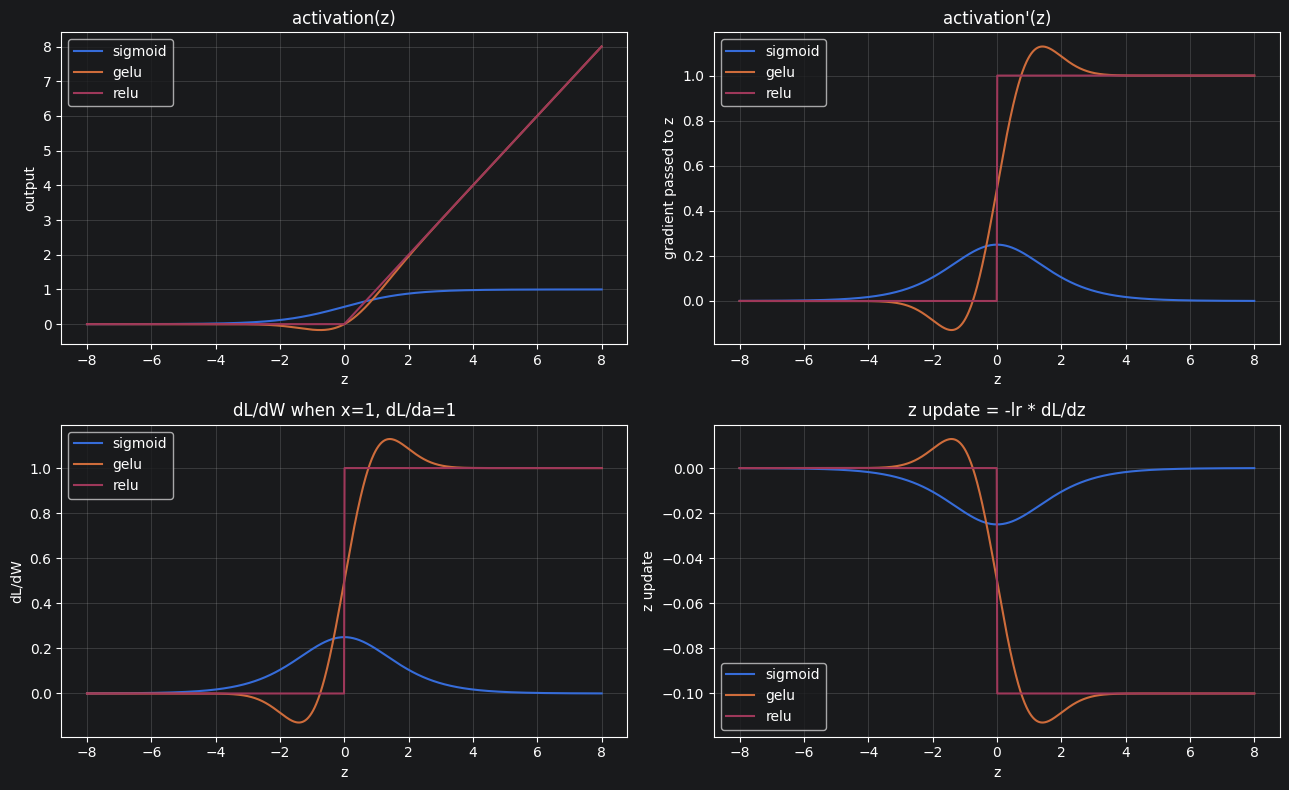

saved figure: figures\activation_gradient_basic.png
saved summary: checkpoints\activation_gradient_basic_summary.json
Key point: sigmoid derivative goes close to zero for large positive/negative z, so dL/dW and update become small.


In [5]:
# ACTIVATION_GRADIENT_COMPARISON_BASIC
# Simplified comparison: x=1 and upstream gradient dL/da=1.
# In this setting, dL/dW = activation'(z), so saturation is easy to see.

from pathlib import Path
import json

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures")
CHECKPOINT_DIR = Path("checkpoints")
FIGURE_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

z_base = torch.linspace(-8, 8, 1000)
learning_rate = 0.1

activations = {
    "sigmoid": torch.sigmoid,
    "gelu": lambda t: F.gelu(t, approximate="none"),
    "relu": torch.relu,
}

results = {}

for name, fn in activations.items():
    z = z_base.clone().detach().requires_grad_(True)
    a = fn(z)
    da_dz = torch.autograd.grad(a.sum(), z, create_graph=False)[0]

    upstream_grad = 1.0
    x = 1.0
    dL_dz = upstream_grad * da_dz
    dL_dW = dL_dz * x
    z_update = -learning_rate * dL_dz

    results[name] = {
        "activation": a.detach(),
        "derivative": da_dz.detach(),
        "dL_dW": dL_dW.detach(),
        "z_update": z_update.detach(),
    }

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for name, row in results.items():
    axes[0, 0].plot(z_base, row["activation"], label=name)
    axes[0, 1].plot(z_base, row["derivative"], label=name)
    axes[1, 0].plot(z_base, row["dL_dW"], label=name)
    axes[1, 1].plot(z_base, row["z_update"], label=name)

axes[0, 0].set_title("activation(z)")
axes[0, 0].set_ylabel("output")

axes[0, 1].set_title("activation'(z)")
axes[0, 1].set_ylabel("gradient passed to z")

axes[1, 0].set_title("dL/dW when x=1, dL/da=1")
axes[1, 0].set_ylabel("dL/dW")

axes[1, 1].set_title("z update = -lr * dL/dz")
axes[1, 1].set_ylabel("z update")

for ax in axes.ravel():
    ax.set_xlabel("z")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
figure_path = FIGURE_DIR / "activation_gradient_basic.png"
fig.savefig(figure_path, dpi=160)
plt.show()

sample_points = torch.tensor([-8.0, -4.0, 0.0, 4.0, 8.0])
summary = {}
for name, fn in activations.items():
    z = sample_points.clone().detach().requires_grad_(True)
    a = fn(z)
    da_dz = torch.autograd.grad(a.sum(), z, create_graph=False)[0]
    summary[name] = [
        {
            "z": float(z_i),
            "activation": float(a_i),
            "activation_derivative": float(g_i),
            "dL_dW_when_x_1_upstream_1": float(g_i),
            "z_update_when_lr_0_1": float(-learning_rate * g_i),
        }
        for z_i, a_i, g_i in zip(z.detach(), a.detach(), da_dz.detach())
    ]

summary_path = CHECKPOINT_DIR / "activation_gradient_basic_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved figure:", figure_path)
print("saved summary:", summary_path)
print("Key point: sigmoid derivative goes close to zero for large positive/negative z, so dL/dW and update become small.")


이건 65번째 코드 셀이에요


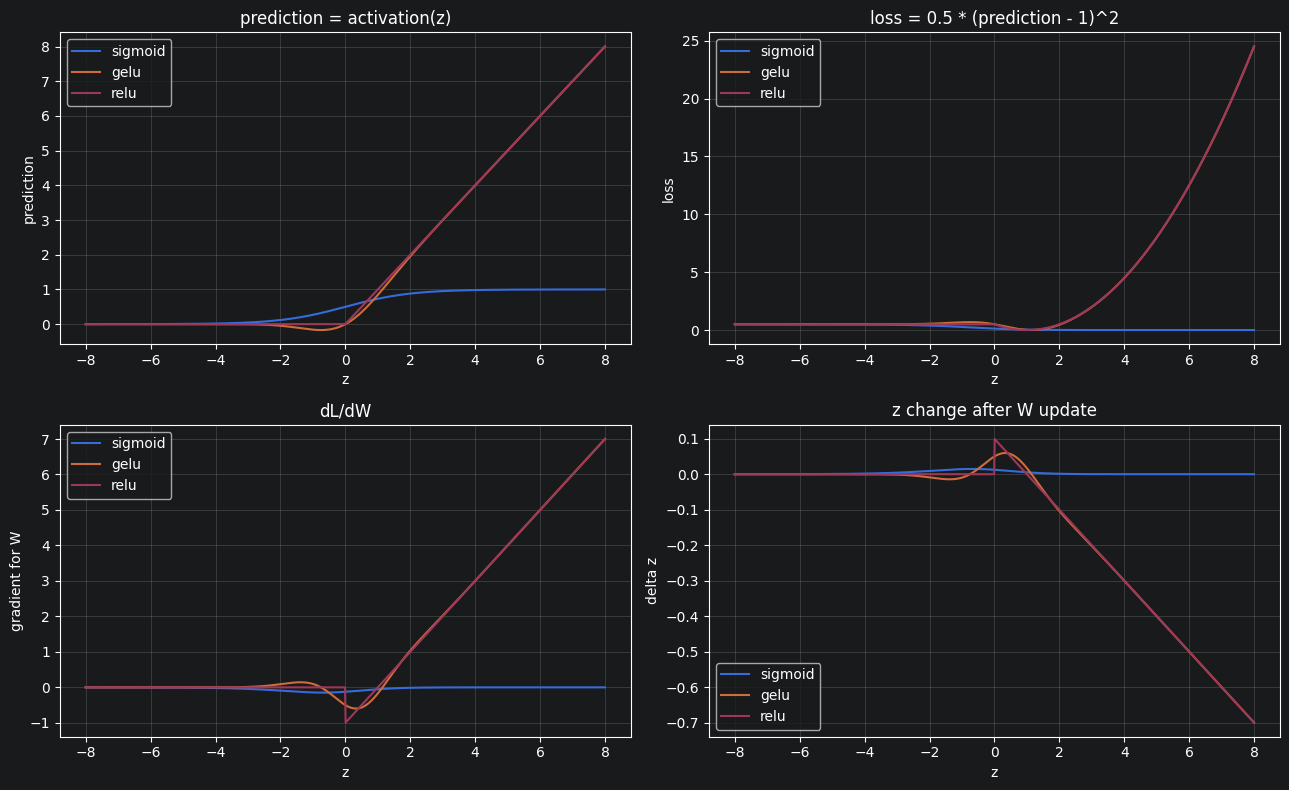

saved figure: figures\activation_weight_update_mse.png
saved summary: checkpoints\activation_weight_update_mse_summary.json
Interpretation: sigmoid can have high loss at negative z but tiny dL/dW, so the weight update is also tiny.


In [6]:
# ACTIVATION_WEIGHT_UPDATE_WITH_MSE
# Slightly more concrete one-neuron example.
# z = xW + b, x=1, b=0, target=1, L = 0.5 * (activation(z) - target)^2.
# Here dL/dW = (activation(z) - target) * activation'(z) * x.

from pathlib import Path
import json

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures")
CHECKPOINT_DIR = Path("checkpoints")
FIGURE_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

z_values = torch.linspace(-8, 8, 1000)
learning_rate = 0.1
x = 1.0
target = 1.0

activations = {
    "sigmoid": torch.sigmoid,
    "gelu": lambda t: F.gelu(t, approximate="none"),
    "relu": torch.relu,
}

results = {}

for name, fn in activations.items():
    z = z_values.clone().detach().requires_grad_(True)
    prediction = fn(z)
    loss = 0.5 * (prediction - target) ** 2
    dL_dz = torch.autograd.grad(loss.sum(), z, create_graph=False)[0]

    dL_dW = dL_dz * x
    weight_update = -learning_rate * dL_dW
    z_after_update = z.detach() + weight_update
    z_delta = z_after_update - z.detach()

    results[name] = {
        "prediction": prediction.detach(),
        "loss": loss.detach(),
        "dL_dz": dL_dz.detach(),
        "dL_dW": dL_dW.detach(),
        "weight_update": weight_update.detach(),
        "z_delta_after_weight_update": z_delta.detach(),
    }

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for name, row in results.items():
    axes[0, 0].plot(z_values, row["prediction"], label=name)
    axes[0, 1].plot(z_values, row["loss"], label=name)
    axes[1, 0].plot(z_values, row["dL_dW"], label=name)
    axes[1, 1].plot(z_values, row["z_delta_after_weight_update"], label=name)

axes[0, 0].set_title("prediction = activation(z)")
axes[0, 0].set_ylabel("prediction")

axes[0, 1].set_title("loss = 0.5 * (prediction - 1)^2")
axes[0, 1].set_ylabel("loss")

axes[1, 0].set_title("dL/dW")
axes[1, 0].set_ylabel("gradient for W")

axes[1, 1].set_title("z change after W update")
axes[1, 1].set_ylabel("delta z")

for ax in axes.ravel():
    ax.set_xlabel("z")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
figure_path = FIGURE_DIR / "activation_weight_update_mse.png"
fig.savefig(figure_path, dpi=160)
plt.show()

sample_points = torch.tensor([-8.0, -4.0, 0.0, 4.0, 8.0])
summary = {}
for name, fn in activations.items():
    z = sample_points.clone().detach().requires_grad_(True)
    prediction = fn(z)
    loss = 0.5 * (prediction - target) ** 2
    dL_dz = torch.autograd.grad(loss.sum(), z, create_graph=False)[0]
    dL_dW = dL_dz * x
    weight_update = -learning_rate * dL_dW
    summary[name] = [
        {
            "z": float(z_i),
            "prediction": float(pred_i),
            "loss": float(loss_i),
            "dL_dW": float(grad_i),
            "weight_update": float(update_i),
            "z_delta_after_update": float(update_i),
        }
        for z_i, pred_i, loss_i, grad_i, update_i in zip(
            z.detach(), prediction.detach(), loss.detach(), dL_dW.detach(), weight_update.detach()
        )
    ]

summary_path = CHECKPOINT_DIR / "activation_weight_update_mse_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved figure:", figure_path)
print("saved summary:", summary_path)
print("Interpretation: sigmoid can have high loss at negative z but tiny dL/dW, so the weight update is also tiny.")


## FFN z distribution by epoch

Compare sigmoid and GELU by collecting the pre-activation z values from the first Linear layer inside each FeedForward module. The plot uses count on the x-axis and z value on the y-axis.


이건 66번째 코드 셀이에요


In [7]:
# ACTIVATION_Z_DISTRIBUTION_BY_EPOCH_TRAIN
# Controlled experiment: train two small GPT models with the same setup, changing only FFN activation.
# z is collected from block.ffn.net[0], the first Linear layer before the activation function.

from pathlib import Path
import json
import random
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, GELU
from src.train import calc_loss_batch, calc_loss_loader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 123

ACTIVATION_NAMES = ["gelu", "sigmoid"]
NUM_EPOCHS = 30
SNAPSHOT_EVERY = 5
SNAPSHOT_BATCHES = 4
MAX_Z_SAMPLES = 200_000

TRAIN_CHAR_LIMIT = 100_000
VAL_CHAR_LIMIT = 20_000
CONTEXT_LENGTH = 64
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
EVAL_BATCHES = 20

HIST_MIN = -8.0
HIST_MAX = 8.0
HIST_BINS = 80

CONFIG = {
    "vocab_size": 2000,
    "context_length": CONTEXT_LENGTH,
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

RESULT_PATH = Path("checkpoints/activation_z_distribution_by_epoch.json")
RESULT_PATH.parent.mkdir(exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_activation(name):
    if name == "gelu":
        return GELU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "relu":
        return nn.ReLU()
    raise ValueError(name)


def activation_derivative(name, z_values):
    z = z_values.detach().clone().requires_grad_(True)
    if name == "gelu":
        y = F.gelu(z, approximate="none")
    elif name == "sigmoid":
        y = torch.sigmoid(z)
    elif name == "relu":
        y = torch.relu(z)
    else:
        raise ValueError(name)
    return torch.autograd.grad(y.sum(), z, create_graph=False)[0].detach()


def replace_ffn_activation(model, activation_name):
    for block in model.blocks:
        block.ffn.net[1] = make_activation(activation_name)


def make_loader(token_ids, shuffle, seed):
    dataset = GPTDataset(token_ids, CONTEXT_LENGTH)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)


def collect_z_snapshot(model, loader, activation_name, epoch):
    z_chunks = []
    handles = []

    def hook(module, inputs, output):
        z_chunks.append(output.detach().float().cpu().reshape(-1))

    for block in model.blocks:
        handles.append(block.ffn.net[0].register_forward_hook(hook))

    was_training = model.training
    model.eval()
    with torch.no_grad():
        for batch_idx, (input_batch, _) in enumerate(loader):
            if batch_idx >= SNAPSHOT_BATCHES:
                break
            _ = model(input_batch.to(DEVICE))

    for handle in handles:
        handle.remove()
    if was_training:
        model.train()

    z_flat = torch.cat(z_chunks) if z_chunks else torch.empty(0)
    if z_flat.numel() > MAX_Z_SAMPLES:
        sample_generator = torch.Generator()
        sample_generator.manual_seed(SEED + epoch)
        indices = torch.randperm(z_flat.numel(), generator=sample_generator)[:MAX_Z_SAMPLES]
        z_flat = z_flat[indices]

    hist = torch.histc(z_flat, bins=HIST_BINS, min=HIST_MIN, max=HIST_MAX)
    derivative = activation_derivative(activation_name, z_flat)

    return {
        "epoch": epoch,
        "num_values": int(z_flat.numel()),
        "hist_counts": [int(v) for v in hist.tolist()],
        "mean": float(z_flat.mean().item()),
        "std": float(z_flat.std(unbiased=False).item()),
        "min": float(z_flat.min().item()),
        "max": float(z_flat.max().item()),
        "p01": float(torch.quantile(z_flat, 0.01).item()),
        "p50": float(torch.quantile(z_flat, 0.50).item()),
        "p99": float(torch.quantile(z_flat, 0.99).item()),
        "frac_abs_gt_4": float((z_flat.abs() > 4).float().mean().item()),
        "frac_abs_gt_6": float((z_flat.abs() > 6).float().mean().item()),
        "frac_activation_grad_lt_0_01": float((derivative.abs() < 0.01).float().mean().item()),
    }


set_seed(SEED)
print("device:", DEVICE)

print("load tokenizer and data")
tokenizer = BPETokenizer(vocab_size=CONFIG["vocab_size"])
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:TRAIN_CHAR_LIMIT]
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")[:VAL_CHAR_LIMIT]

train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

probe_loader = make_loader(val_ids, shuffle=False, seed=SEED)

bin_edges = torch.linspace(HIST_MIN, HIST_MAX, HIST_BINS + 1)
result = {
    "config": CONFIG,
    "seed": SEED,
    "activation_names": ACTIVATION_NAMES,
    "num_epochs": NUM_EPOCHS,
    "snapshot_every": SNAPSHOT_EVERY,
    "snapshot_batches": SNAPSHOT_BATCHES,
    "train_char_limit": TRAIN_CHAR_LIMIT,
    "val_char_limit": VAL_CHAR_LIMIT,
    "train_tokens": len(train_ids),
    "val_tokens": len(val_ids),
    "hist_min": HIST_MIN,
    "hist_max": HIST_MAX,
    "hist_bins": HIST_BINS,
    "bin_edges": [float(v) for v in bin_edges.tolist()],
    "runs": {},
}

for activation_name in ACTIVATION_NAMES:
    print("=" * 60)
    print("activation:", activation_name)
    set_seed(SEED)

    model = GPTModel(CONFIG).to(DEVICE)
    replace_ffn_activation(model, activation_name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    train_loader = make_loader(train_ids, shuffle=True, seed=SEED)
    val_loader = make_loader(val_ids, shuffle=False, seed=SEED)

    run = {
        "train_loss": [],
        "val_loss": [],
        "snapshots": [],
    }

    run["snapshots"].append(collect_z_snapshot(model, probe_loader, activation_name, epoch=0))
    start = time.perf_counter()

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        losses = []
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        train_loss = sum(losses) / max(len(losses), 1)
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=EVAL_BATCHES)
        run["train_loss"].append(train_loss)
        run["val_loss"].append(val_loss)

        if epoch % SNAPSHOT_EVERY == 0 or epoch == NUM_EPOCHS:
            snapshot = collect_z_snapshot(model, probe_loader, activation_name, epoch=epoch)
            run["snapshots"].append(snapshot)
            print(
                f"epoch {epoch:>3}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
                f"z_mean={snapshot['mean']:.4f}, z_std={snapshot['std']:.4f}, "
                f"low_grad_frac={snapshot['frac_activation_grad_lt_0_01']:.4f}"
            )

    run["elapsed_sec"] = time.perf_counter() - start
    result["runs"][activation_name] = run
    print("elapsed_sec:", f"{run['elapsed_sec']:.1f}")

RESULT_PATH.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved:", RESULT_PATH)


device: cuda
load tokenizer and data
activation: gelu
epoch   5: train_loss=6.9501, val_loss=6.9679, z_mean=0.4044, z_std=0.8492, low_grad_frac=0.0089
epoch  10: train_loss=6.9098, val_loss=6.9567, z_mean=0.3125, z_std=0.7409, low_grad_frac=0.0086
epoch  15: train_loss=6.8673, val_loss=6.9462, z_mean=0.2073, z_std=0.6550, low_grad_frac=0.0092
epoch  20: train_loss=6.7708, val_loss=6.9100, z_mean=0.1809, z_std=0.7007, low_grad_frac=0.0107
epoch  25: train_loss=6.6298, val_loss=6.8468, z_mean=0.1259, z_std=0.7596, low_grad_frac=0.0123
epoch  30: train_loss=6.4636, val_loss=6.7581, z_mean=0.0663, z_std=0.8145, low_grad_frac=0.0135
elapsed_sec: 12.7
activation: sigmoid
epoch   5: train_loss=6.9491, val_loss=6.9697, z_mean=0.4067, z_std=0.7656, low_grad_frac=0.0000
epoch  10: train_loss=6.9193, val_loss=6.9601, z_mean=0.3929, z_std=0.7608, low_grad_frac=0.0000
epoch  15: train_loss=6.9077, val_loss=6.9558, z_mean=0.1852, z_std=0.6785, low_grad_frac=0.0000
epoch  20: train_loss=6.8734, val_l

이건 67번째 코드 셀이에요


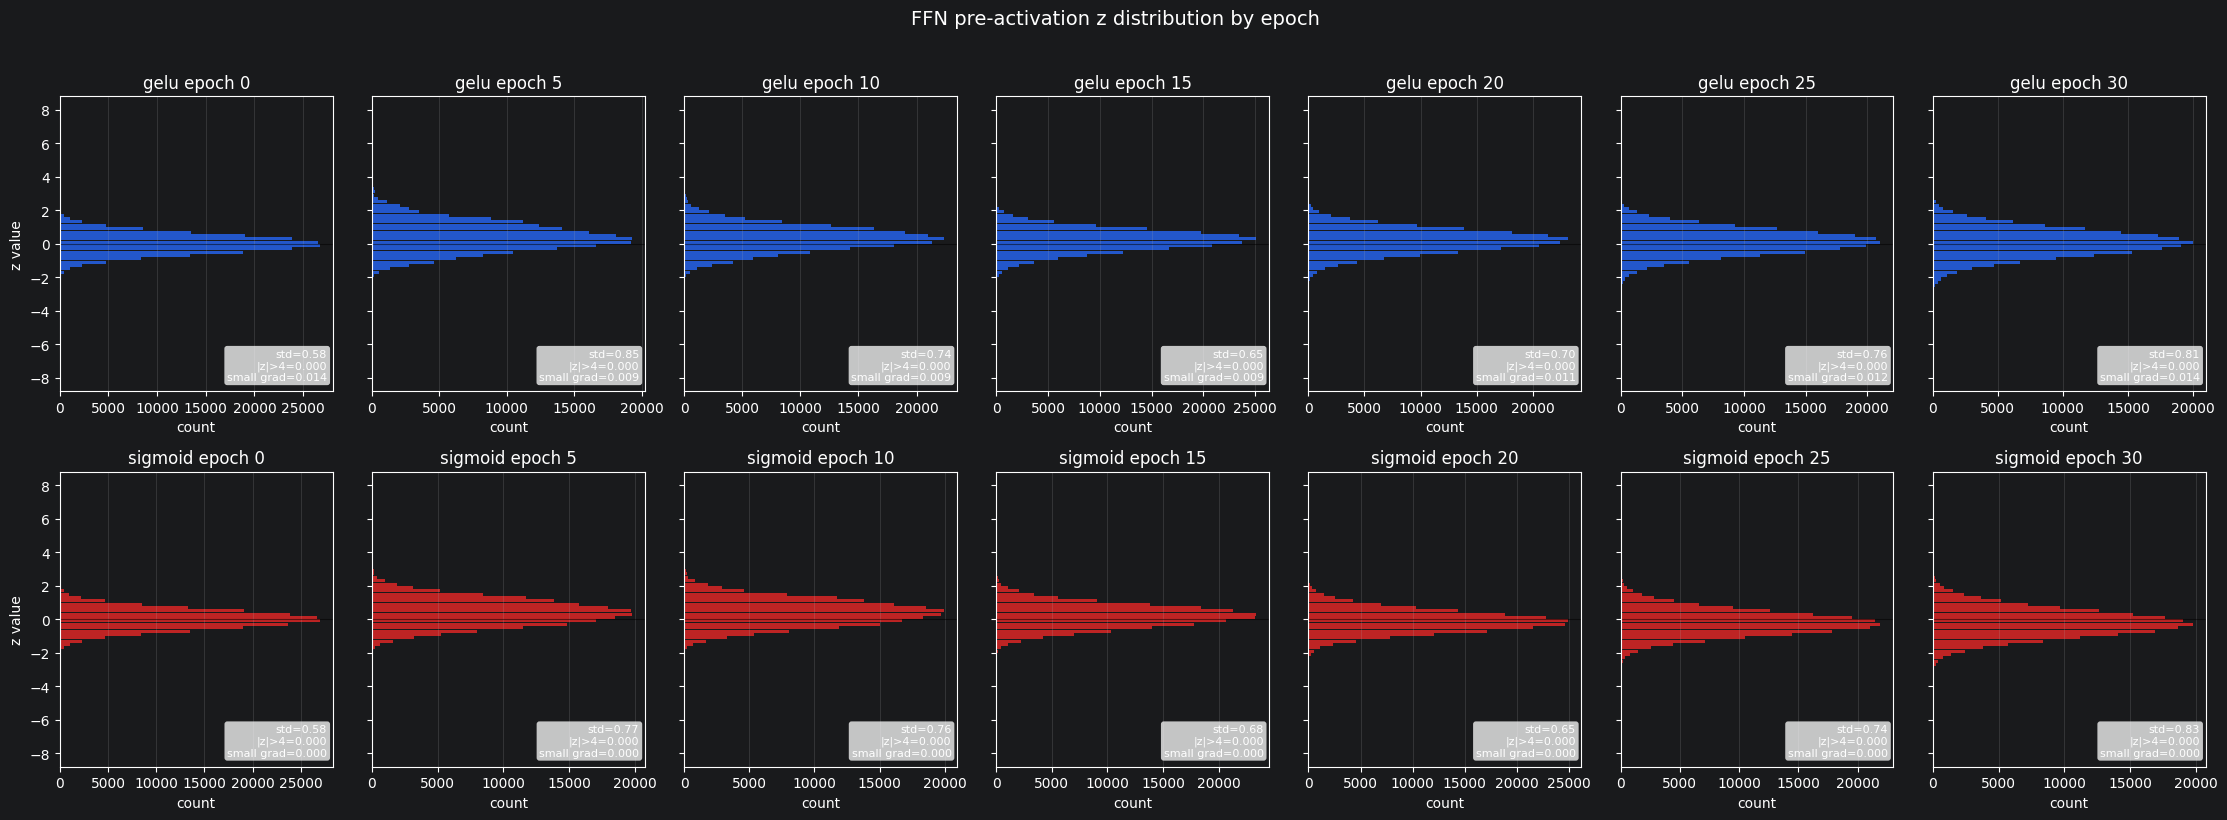

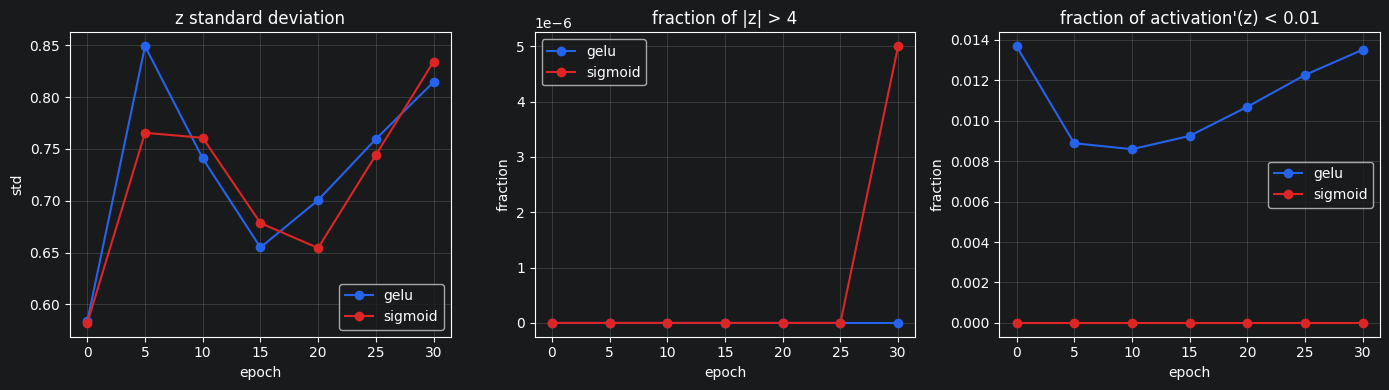

saved: figures\activation_z_distribution_by_epoch.png
saved: figures\activation_z_distribution_stats.png
Interpretation tip: sigmoid becomes problematic when many z values move to regions where activation'(z) is close to 0.


In [8]:
# ACTIVATION_Z_DISTRIBUTION_BY_EPOCH_PLOT
# Horizontal histogram: x-axis is count, y-axis is z value.
# This makes it easy to see whether z values move into large magnitude regions over epochs.

from pathlib import Path
import json

import matplotlib.pyplot as plt

RESULT_PATH = Path("checkpoints/activation_z_distribution_by_epoch.json")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
bin_edges = result["bin_edges"]
bin_centers = [(left + right) / 2 for left, right in zip(bin_edges[:-1], bin_edges[1:])]
bin_height = bin_edges[1] - bin_edges[0]

activation_names = result["activation_names"]
snapshot_epochs = [snapshot["epoch"] for snapshot in result["runs"][activation_names[0]]["snapshots"]]

fig, axes = plt.subplots(
    len(activation_names),
    len(snapshot_epochs),
    figsize=(3.2 * len(snapshot_epochs), 4.0 * len(activation_names)),
    sharey=True,
)

if len(activation_names) == 1:
    axes = [axes]

colors = {
    "gelu": "#2563eb",
    "sigmoid": "#dc2626",
    "relu": "#16a34a",
}

for row_idx, activation_name in enumerate(activation_names):
    snapshots = result["runs"][activation_name]["snapshots"]
    for col_idx, snapshot in enumerate(snapshots):
        ax = axes[row_idx][col_idx] if len(activation_names) > 1 else axes[col_idx]
        counts = snapshot["hist_counts"]
        ax.barh(
            bin_centers,
            counts,
            height=bin_height * 0.9,
            color=colors.get(activation_name, "#6b7280"),
            alpha=0.85,
        )
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.set_title(f"{activation_name} epoch {snapshot['epoch']}")
        ax.set_xlabel("count")
        if col_idx == 0:
            ax.set_ylabel("z value")
        ax.grid(True, axis="x", alpha=0.25)
        ax.text(
            0.98,
            0.03,
            f"std={snapshot['std']:.2f}\n|z|>4={snapshot['frac_abs_gt_4']:.3f}\nsmall grad={snapshot['frac_activation_grad_lt_0_01']:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )

fig.suptitle("FFN pre-activation z distribution by epoch", y=1.02, fontsize=14)
fig.tight_layout()
figure_path = FIGURE_DIR / "activation_z_distribution_by_epoch.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for activation_name in activation_names:
    snapshots = result["runs"][activation_name]["snapshots"]
    epochs = [snapshot["epoch"] for snapshot in snapshots]
    z_std = [snapshot["std"] for snapshot in snapshots]
    abs_gt_4 = [snapshot["frac_abs_gt_4"] for snapshot in snapshots]
    small_grad = [snapshot["frac_activation_grad_lt_0_01"] for snapshot in snapshots]
    color = colors.get(activation_name, None)
    axes[0].plot(epochs, z_std, marker="o", label=activation_name, color=color)
    axes[1].plot(epochs, abs_gt_4, marker="o", label=activation_name, color=color)
    axes[2].plot(epochs, small_grad, marker="o", label=activation_name, color=color)

axes[0].set_title("z standard deviation")
axes[0].set_ylabel("std")
axes[1].set_title("fraction of |z| > 4")
axes[1].set_ylabel("fraction")
axes[2].set_title("fraction of activation'(z) < 0.01")
axes[2].set_ylabel("fraction")

for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
summary_figure_path = FIGURE_DIR / "activation_z_distribution_stats.png"
fig.savefig(summary_figure_path, dpi=160)
plt.show()

print("saved:", figure_path)
print("saved:", summary_figure_path)
print("Interpretation tip: sigmoid becomes problematic when many z values move to regions where activation'(z) is close to 0.")


## FFN dL/dW distribution by epoch

Collect only the gradient of the first FFN Linear weight. This isolates dL/dW for the layer that directly receives activation backpropagation.


이건 68번째 코드 셀이에요


In [2]:
# ACTIVATION_DLDW_DISTRIBUTION_BY_EPOCH_TRAIN
# Collect dL/dW for block.ffn.net[0].weight during training.
# This compares sigmoid and GELU using the same small model/data setup.

from pathlib import Path
import json
import random
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, GELU
from src.train import calc_loss_batch, calc_loss_loader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 123

ACTIVATION_NAMES = ["gelu", "sigmoid"]
NUM_EPOCHS = 30
SNAPSHOT_EVERY = 5
SNAPSHOT_BATCHES = 8
MAX_GRAD_SAMPLES = 200_000

TRAIN_CHAR_LIMIT = 100_000
VAL_CHAR_LIMIT = 20_000
CONTEXT_LENGTH = 64
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
EVAL_BATCHES = 20

HIST_MIN = -0.02
HIST_MAX = 0.02
HIST_BINS = 80
ABS_HIST_MAX = 0.02
FINE_ABS_HIST_MAX = 0.001
FINE_ABS_HIST_BINS = 100
TINY_THRESHOLDS = [
    1e-8,
    3e-8,
    1e-7,
    3e-7,
    1e-6,
    3e-6,
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3,
]

CONFIG = {
    "vocab_size": 2000,
    "context_length": CONTEXT_LENGTH,
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

RESULT_PATH = Path("checkpoints/activation_dldw_distribution_by_epoch.json")
RESULT_PATH.parent.mkdir(exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_activation(name):
    if name == "gelu":
        return GELU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "relu":
        return nn.ReLU()
    raise ValueError(name)


def replace_ffn_activation(model, activation_name):
    for block in model.blocks:
        block.ffn.net[1] = make_activation(activation_name)


def make_loader(token_ids, shuffle, seed):
    dataset = GPTDataset(token_ids, CONTEXT_LENGTH)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)


def collect_dldw_snapshot(model, loader, activation_name, epoch):
    model.train()
    grad_chunks = []

    for batch_idx, (input_batch, target_batch) in enumerate(loader):
        if batch_idx >= SNAPSHOT_BATCHES:
            break
        model.zero_grad(set_to_none=True)
        loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
        loss.backward()
        for block in model.blocks:
            grad = block.ffn.net[0].weight.grad
            if grad is not None:
                grad_chunks.append(grad.detach().float().cpu().reshape(-1))

    model.zero_grad(set_to_none=True)

    grads = torch.cat(grad_chunks) if grad_chunks else torch.empty(0)
    if grads.numel() > MAX_GRAD_SAMPLES:
        sample_generator = torch.Generator()
        sample_generator.manual_seed(SEED + epoch)
        indices = torch.randperm(grads.numel(), generator=sample_generator)[:MAX_GRAD_SAMPLES]
        grads = grads[indices]

    hist_signed = torch.histc(grads, bins=HIST_BINS, min=HIST_MIN, max=HIST_MAX)
    hist_abs = torch.histc(grads.abs(), bins=HIST_BINS, min=0.0, max=ABS_HIST_MAX)
    hist_abs_fine = torch.histc(grads.abs(), bins=FINE_ABS_HIST_BINS, min=0.0, max=FINE_ABS_HIST_MAX)

    abs_grads = grads.abs()
    return {
        "epoch": epoch,
        "num_values": int(grads.numel()),
        "hist_counts_signed": [int(v) for v in hist_signed.tolist()],
        "hist_counts_abs": [int(v) for v in hist_abs.tolist()],
        "hist_counts_abs_fine": [int(v) for v in hist_abs_fine.tolist()],
        "mean": float(grads.mean().item()),
        "std": float(grads.std(unbiased=False).item()),
        "mean_abs": float(abs_grads.mean().item()),
        "median_abs": float(torch.quantile(abs_grads, 0.50).item()),
        "p90_abs": float(torch.quantile(abs_grads, 0.90).item()),
        "p99_abs": float(torch.quantile(abs_grads, 0.99).item()),
        "frac_abs_lt_1e_6": float((abs_grads < 1e-6).float().mean().item()),
        "frac_abs_lt_1e_5": float((abs_grads < 1e-5).float().mean().item()),
        "frac_abs_lt_1e_4": float((abs_grads < 1e-4).float().mean().item()),
        "frac_abs_lt_threshold": [
            float((abs_grads < threshold).float().mean().item())
            for threshold in TINY_THRESHOLDS
        ],
    }


set_seed(SEED)
print("device:", DEVICE)
print("load tokenizer and data")

tokenizer = BPETokenizer(vocab_size=CONFIG["vocab_size"])
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:TRAIN_CHAR_LIMIT]
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")[:VAL_CHAR_LIMIT]
train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

signed_bin_edges = torch.linspace(HIST_MIN, HIST_MAX, HIST_BINS + 1)
abs_bin_edges = torch.linspace(0.0, ABS_HIST_MAX, HIST_BINS + 1)
fine_abs_bin_edges = torch.linspace(0.0, FINE_ABS_HIST_MAX, FINE_ABS_HIST_BINS + 1)

result = {
    "config": CONFIG,
    "seed": SEED,
    "activation_names": ACTIVATION_NAMES,
    "num_epochs": NUM_EPOCHS,
    "snapshot_every": SNAPSHOT_EVERY,
    "snapshot_batches": SNAPSHOT_BATCHES,
    "train_char_limit": TRAIN_CHAR_LIMIT,
    "val_char_limit": VAL_CHAR_LIMIT,
    "train_tokens": len(train_ids),
    "val_tokens": len(val_ids),
    "hist_min": HIST_MIN,
    "hist_max": HIST_MAX,
    "hist_bins": HIST_BINS,
    "signed_bin_edges": [float(v) for v in signed_bin_edges.tolist()],
    "abs_bin_edges": [float(v) for v in abs_bin_edges.tolist()],
    "fine_abs_hist_max": FINE_ABS_HIST_MAX,
    "fine_abs_hist_bins": FINE_ABS_HIST_BINS,
    "fine_abs_bin_edges": [float(v) for v in fine_abs_bin_edges.tolist()],
    "tiny_thresholds": TINY_THRESHOLDS,
    "runs": {},
}

for activation_name in ACTIVATION_NAMES:
    print("=" * 60)
    print("activation:", activation_name)
    set_seed(SEED)

    model = GPTModel(CONFIG).to(DEVICE)
    replace_ffn_activation(model, activation_name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    train_loader = make_loader(train_ids, shuffle=True, seed=SEED)
    val_loader = make_loader(val_ids, shuffle=False, seed=SEED)
    probe_loader = make_loader(val_ids, shuffle=False, seed=SEED + 99)

    run = {
        "train_loss": [],
        "val_loss": [],
        "snapshots": [],
    }

    run["snapshots"].append(collect_dldw_snapshot(model, probe_loader, activation_name, epoch=0))
    start = time.perf_counter()

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        losses = []
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        train_loss = sum(losses) / max(len(losses), 1)
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=EVAL_BATCHES)
        run["train_loss"].append(train_loss)
        run["val_loss"].append(val_loss)

        if epoch % SNAPSHOT_EVERY == 0 or epoch == NUM_EPOCHS:
            snapshot = collect_dldw_snapshot(model, probe_loader, activation_name, epoch=epoch)
            run["snapshots"].append(snapshot)
            print(
                f"epoch {epoch:>3}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
                f"mean_abs_dLdW={snapshot['mean_abs']:.8f}, p99_abs={snapshot['p99_abs']:.8f}, "
                f"frac_abs_lt_1e_5={snapshot['frac_abs_lt_1e_5']:.4f}"
            )

    run["elapsed_sec"] = time.perf_counter() - start
    result["runs"][activation_name] = run
    print("elapsed_sec:", f"{run['elapsed_sec']:.1f}")

RESULT_PATH.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved:", RESULT_PATH)


device: cuda
load tokenizer and data
activation: gelu
epoch   5: train_loss=6.9503, val_loss=6.9676, mean_abs_dLdW=0.00005177, p99_abs=0.00024577, frac_abs_lt_1e_5=0.1754
epoch  10: train_loss=6.9112, val_loss=6.9567, mean_abs_dLdW=0.00006746, p99_abs=0.00030290, frac_abs_lt_1e_5=0.1305
epoch  15: train_loss=6.8667, val_loss=6.9464, mean_abs_dLdW=0.00013665, p99_abs=0.00055058, frac_abs_lt_1e_5=0.0554
epoch  20: train_loss=6.7708, val_loss=6.9105, mean_abs_dLdW=0.00021473, p99_abs=0.00081865, frac_abs_lt_1e_5=0.0333
epoch  25: train_loss=6.6316, val_loss=6.8486, mean_abs_dLdW=0.00030348, p99_abs=0.00116805, frac_abs_lt_1e_5=0.0232
epoch  30: train_loss=6.4625, val_loss=6.7602, mean_abs_dLdW=0.00040285, p99_abs=0.00161089, frac_abs_lt_1e_5=0.0177
elapsed_sec: 10.1
activation: sigmoid
epoch   5: train_loss=6.9506, val_loss=6.9698, mean_abs_dLdW=0.00001508, p99_abs=0.00006009, frac_abs_lt_1e_5=0.4369
epoch  10: train_loss=6.9213, val_loss=6.9601, mean_abs_dLdW=0.00001435, p99_abs=0.000058

이건 69번째 코드 셀이에요


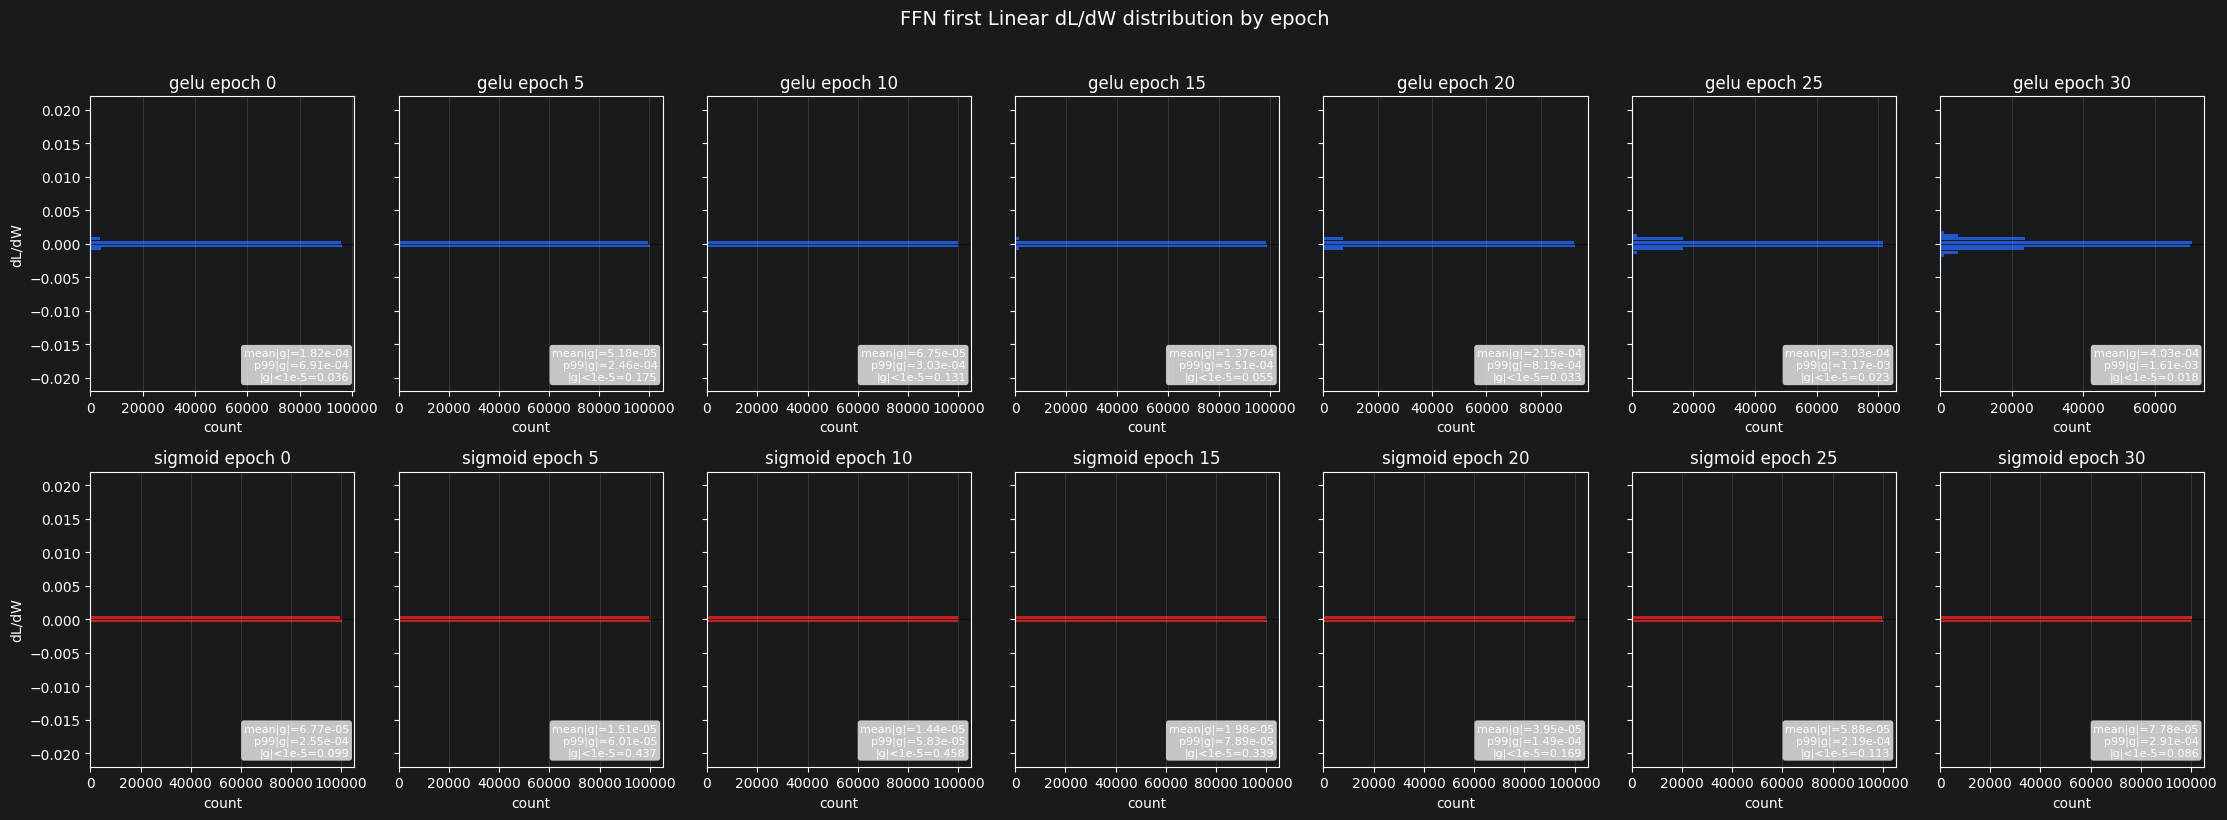

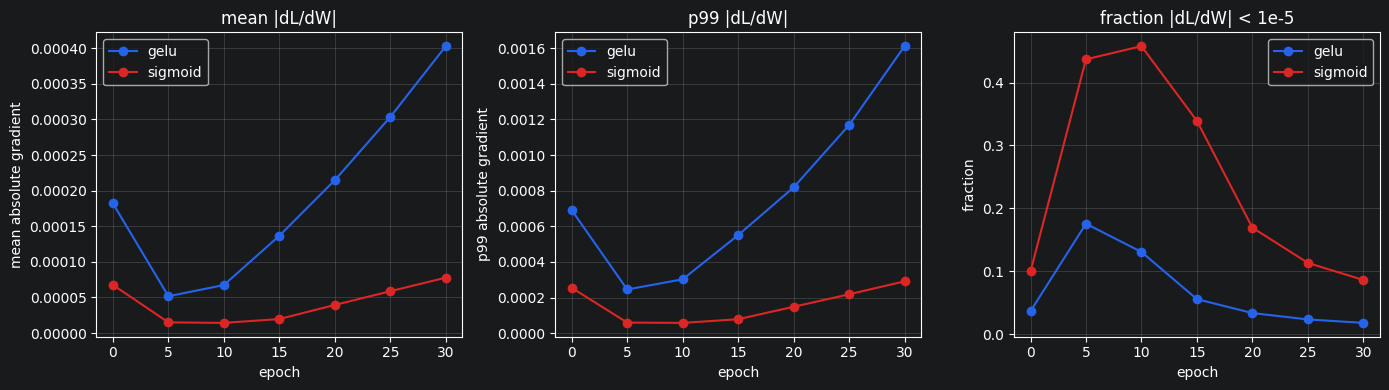

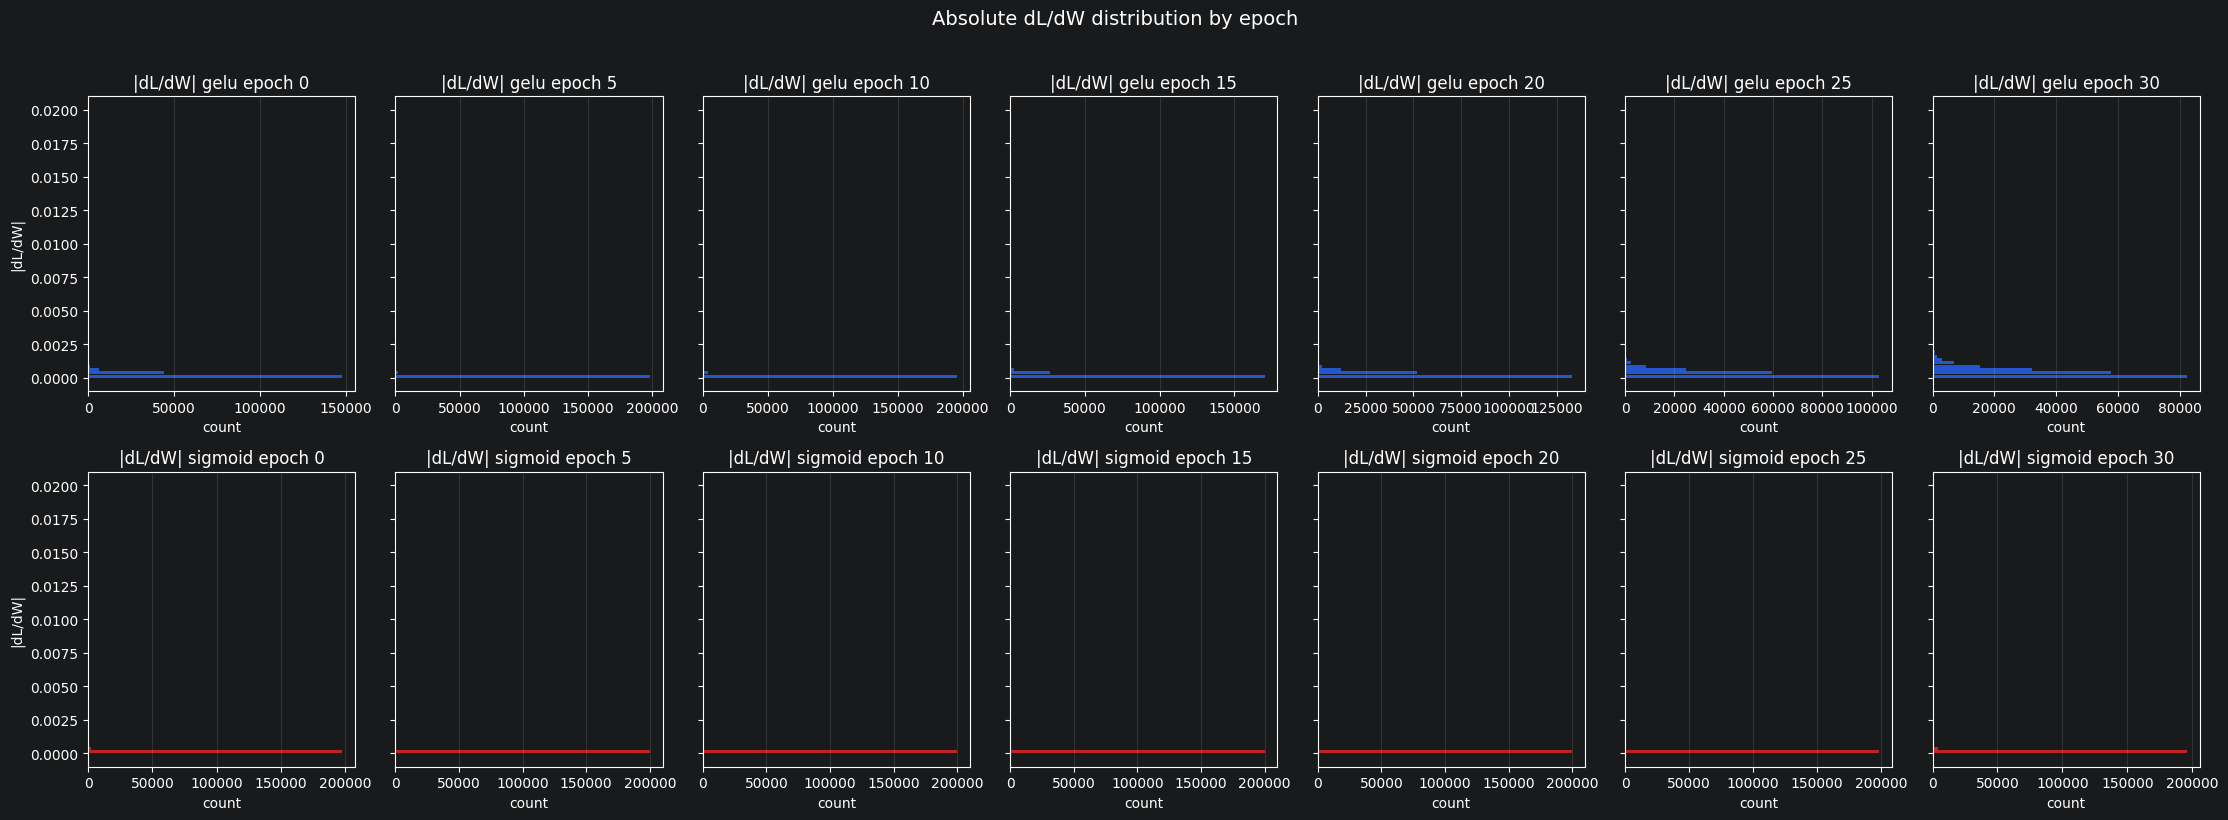

saved: figures\activation_dldw_distribution_by_epoch.png
saved: figures\activation_dldw_stats_by_epoch.png
saved: figures\activation_abs_dldw_distribution_by_epoch.png
Interpretation tip: if sigmoid has a larger fraction of tiny |dL/dW|, the first FFN weight receives weaker updates.


In [3]:
# ACTIVATION_DLDW_DISTRIBUTION_BY_EPOCH_PLOT
# dL/dW only. Horizontal histograms use count on x-axis and dL/dW value on y-axis.

from pathlib import Path
import json

import matplotlib.pyplot as plt

RESULT_PATH = Path("checkpoints/activation_dldw_distribution_by_epoch.json")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
activation_names = result["activation_names"]
signed_edges = result["signed_bin_edges"]
abs_edges = result["abs_bin_edges"]
signed_centers = [(left + right) / 2 for left, right in zip(signed_edges[:-1], signed_edges[1:])]
abs_centers = [(left + right) / 2 for left, right in zip(abs_edges[:-1], abs_edges[1:])]
signed_height = signed_edges[1] - signed_edges[0]
abs_height = abs_edges[1] - abs_edges[0]
snapshot_epochs = [s["epoch"] for s in result["runs"][activation_names[0]]["snapshots"]]
colors = {"gelu": "#2563eb", "sigmoid": "#dc2626", "relu": "#16a34a"}

fig, axes = plt.subplots(
    len(activation_names),
    len(snapshot_epochs),
    figsize=(3.2 * len(snapshot_epochs), 4.0 * len(activation_names)),
    sharey=True,
)

if len(activation_names) == 1:
    axes = [axes]

for row_idx, activation_name in enumerate(activation_names):
    snapshots = result["runs"][activation_name]["snapshots"]
    for col_idx, snapshot in enumerate(snapshots):
        ax = axes[row_idx][col_idx] if len(activation_names) > 1 else axes[col_idx]
        counts = snapshot["hist_counts_signed"]
        ax.barh(
            signed_centers,
            counts,
            height=signed_height * 0.9,
            color=colors.get(activation_name, "#6b7280"),
            alpha=0.85,
        )
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.set_title(f"{activation_name} epoch {snapshot['epoch']}")
        ax.set_xlabel("count")
        if col_idx == 0:
            ax.set_ylabel("dL/dW")
        ax.grid(True, axis="x", alpha=0.25)
        ax.text(
            0.98,
            0.03,
            f"mean|g|={snapshot['mean_abs']:.2e}\np99|g|={snapshot['p99_abs']:.2e}\n|g|<1e-5={snapshot['frac_abs_lt_1e_5']:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )

fig.suptitle("FFN first Linear dL/dW distribution by epoch", y=1.02, fontsize=14)
fig.tight_layout()
figure_path = FIGURE_DIR / "activation_dldw_distribution_by_epoch.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for activation_name in activation_names:
    snapshots = result["runs"][activation_name]["snapshots"]
    epochs = [snapshot["epoch"] for snapshot in snapshots]
    mean_abs = [snapshot["mean_abs"] for snapshot in snapshots]
    p99_abs = [snapshot["p99_abs"] for snapshot in snapshots]
    small_frac = [snapshot["frac_abs_lt_1e_5"] for snapshot in snapshots]
    color = colors.get(activation_name, None)
    axes[0].plot(epochs, mean_abs, marker="o", label=activation_name, color=color)
    axes[1].plot(epochs, p99_abs, marker="o", label=activation_name, color=color)
    axes[2].plot(epochs, small_frac, marker="o", label=activation_name, color=color)

axes[0].set_title("mean |dL/dW|")
axes[0].set_ylabel("mean absolute gradient")
axes[1].set_title("p99 |dL/dW|")
axes[1].set_ylabel("p99 absolute gradient")
axes[2].set_title("fraction |dL/dW| < 1e-5")
axes[2].set_ylabel("fraction")

for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
summary_path = FIGURE_DIR / "activation_dldw_stats_by_epoch.png"
fig.savefig(summary_path, dpi=160)
plt.show()

fig, axes = plt.subplots(len(activation_names), len(snapshot_epochs), figsize=(3.2 * len(snapshot_epochs), 4.0 * len(activation_names)), sharey=True)
if len(activation_names) == 1:
    axes = [axes]
for row_idx, activation_name in enumerate(activation_names):
    snapshots = result["runs"][activation_name]["snapshots"]
    for col_idx, snapshot in enumerate(snapshots):
        ax = axes[row_idx][col_idx] if len(activation_names) > 1 else axes[col_idx]
        counts = snapshot["hist_counts_abs"]
        ax.barh(abs_centers, counts, height=abs_height * 0.9, color=colors.get(activation_name, "#6b7280"), alpha=0.85)
        ax.set_title(f"|dL/dW| {activation_name} epoch {snapshot['epoch']}")
        ax.set_xlabel("count")
        if col_idx == 0:
            ax.set_ylabel("|dL/dW|")
        ax.grid(True, axis="x", alpha=0.25)
fig.suptitle("Absolute dL/dW distribution by epoch", y=1.02, fontsize=14)
fig.tight_layout()
abs_path = FIGURE_DIR / "activation_abs_dldw_distribution_by_epoch.png"
fig.savefig(abs_path, dpi=160, bbox_inches="tight")
plt.show()

print("saved:", figure_path)
print("saved:", summary_path)
print("saved:", abs_path)
print("Interpretation tip: if sigmoid has a larger fraction of tiny |dL/dW|, the first FFN weight receives weaker updates.")


## Zoomed dL/dW comparison

Zoom into the small-gradient region of dL/dW. This is useful for checking whether sigmoid sends weaker updates to the first FFN Linear weight than GELU.


이건 70번째 코드 셀이에요


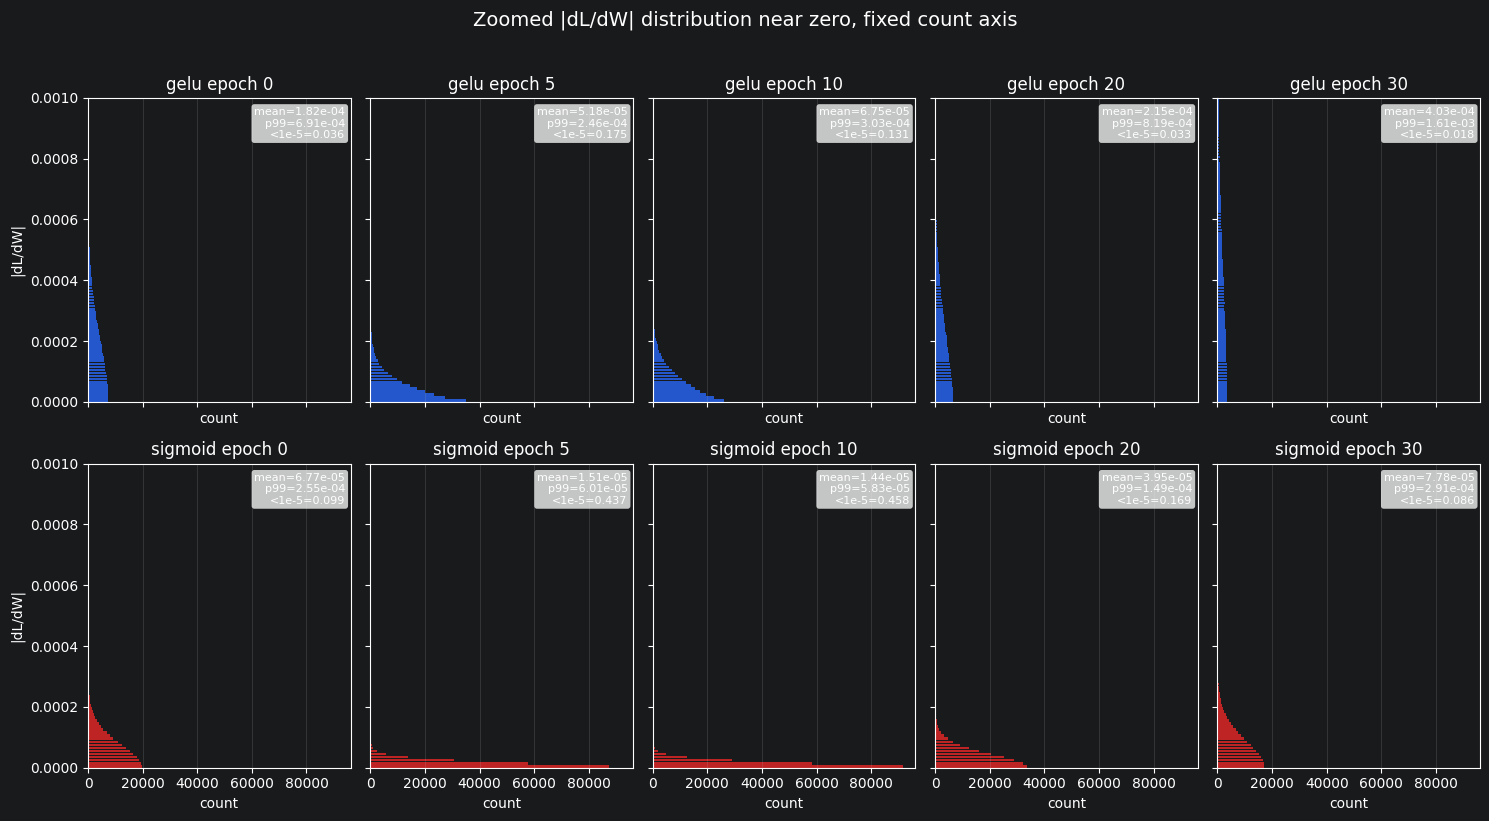

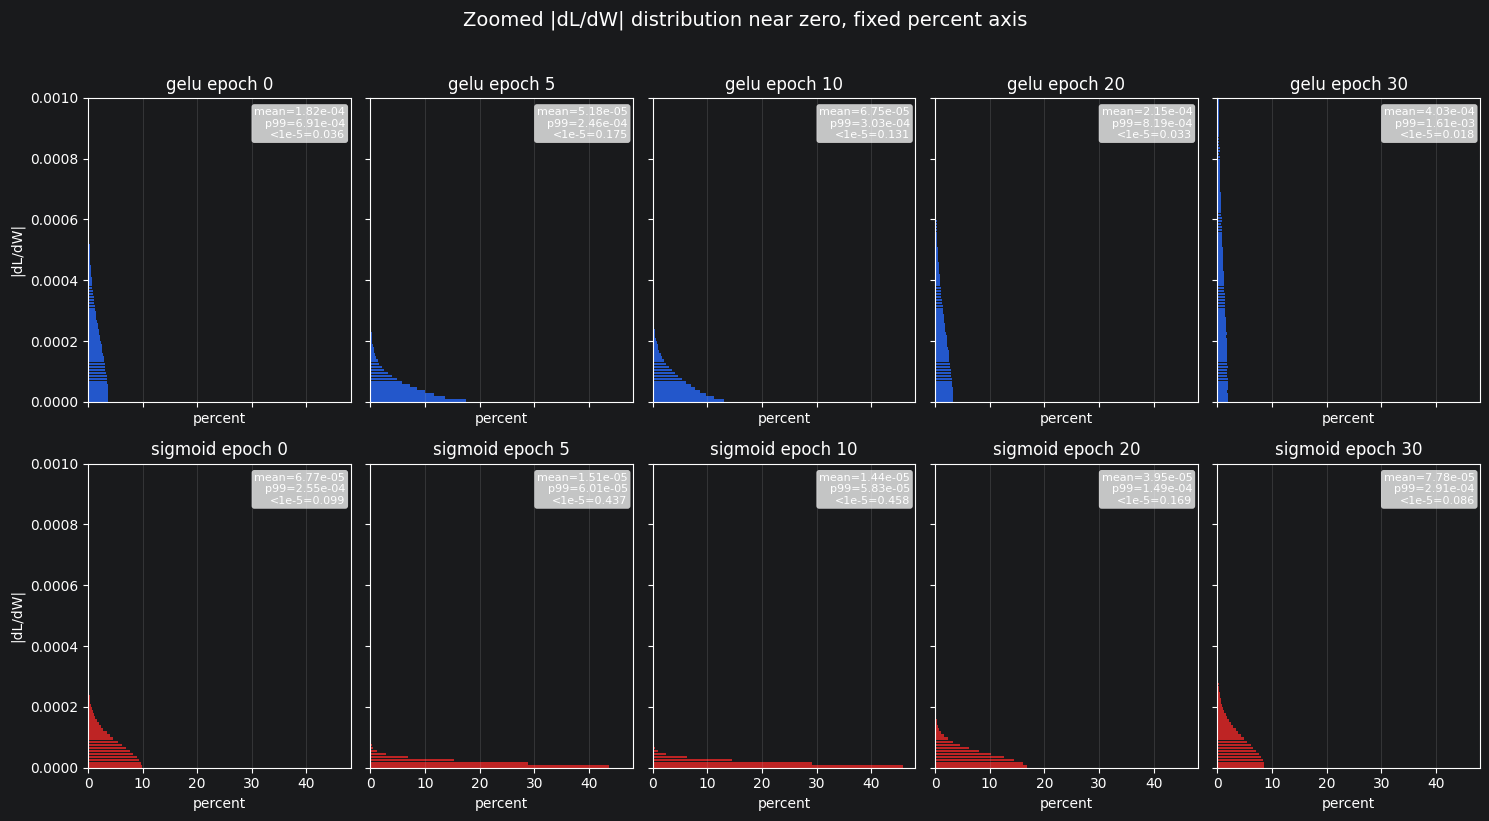

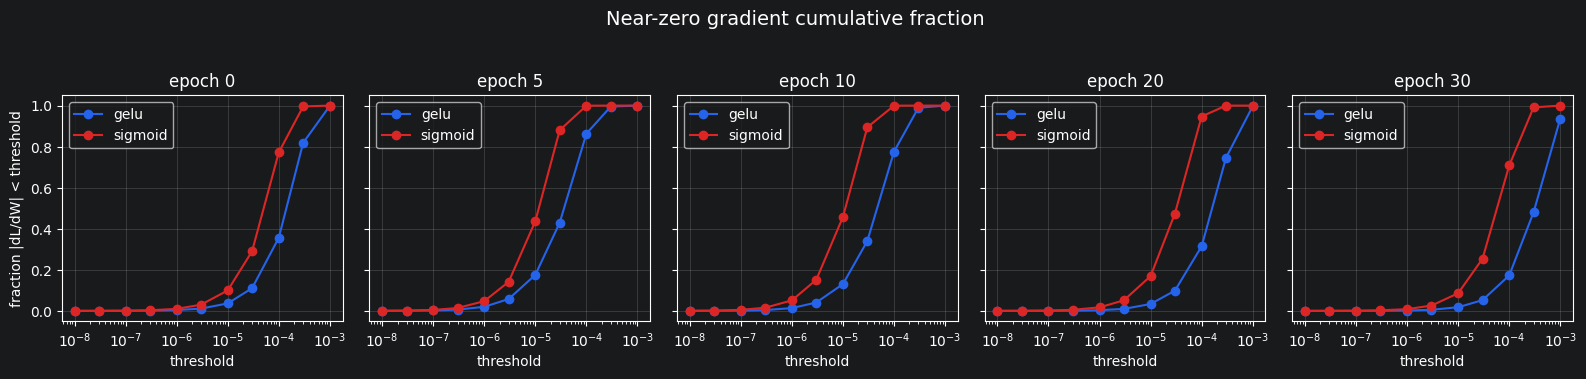

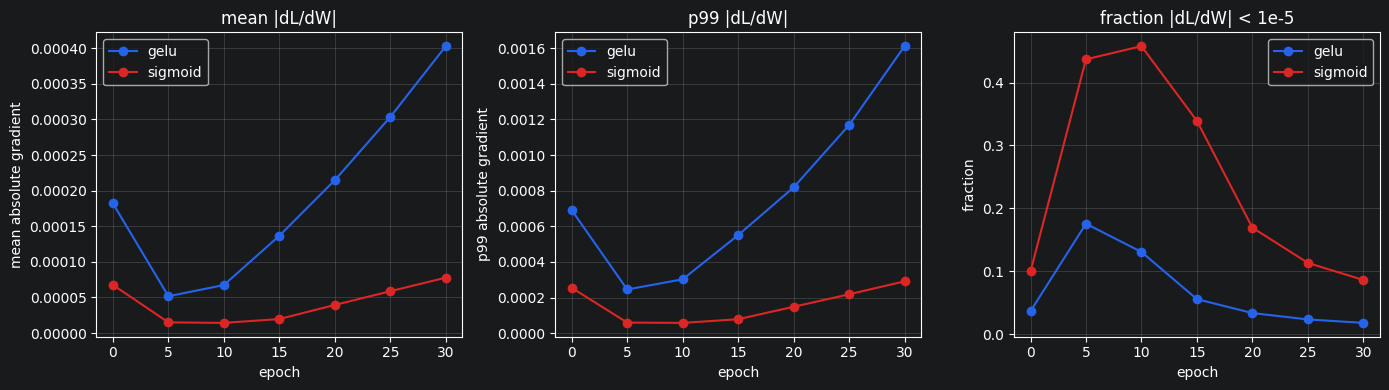

saved: figures\activation_dldw_zoomed_near_zero_fixed_count.png
saved: figures\activation_dldw_zoomed_near_zero_fixed_percent.png
saved: figures\activation_dldw_tiny_threshold_curve.png
saved: figures\activation_dldw_zoomed_stats.png

[epoch-wise comparison]
epoch  0: mean|grad| GELU/Sigmoid=2.69x, p99|grad| GELU/Sigmoid=2.71x, tiny_grad(<1e-5) sigmoid=0.099, gelu=0.036
epoch  5: mean|grad| GELU/Sigmoid=3.43x, p99|grad| GELU/Sigmoid=4.09x, tiny_grad(<1e-5) sigmoid=0.437, gelu=0.175
epoch 10: mean|grad| GELU/Sigmoid=4.70x, p99|grad| GELU/Sigmoid=5.19x, tiny_grad(<1e-5) sigmoid=0.458, gelu=0.131
epoch 20: mean|grad| GELU/Sigmoid=5.44x, p99|grad| GELU/Sigmoid=5.50x, tiny_grad(<1e-5) sigmoid=0.169, gelu=0.033
epoch 30: mean|grad| GELU/Sigmoid=5.17x, p99|grad| GELU/Sigmoid=5.53x, tiny_grad(<1e-5) sigmoid=0.086, gelu=0.018


In [4]:
# ACTIVATION_DLDW_ZOOMED_COMPARISON
# Zoomed view of dL/dW near zero and summary ratios between GELU and sigmoid.
# Requires: checkpoints/activation_dldw_distribution_by_epoch.json

from pathlib import Path
import json

import matplotlib.pyplot as plt

RESULT_PATH = Path("checkpoints/activation_dldw_distribution_by_epoch.json")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
activation_names = result["activation_names"]
colors = {"gelu": "#2563eb", "sigmoid": "#dc2626"}
selected_epochs = [0, 5, 10, 20, 30]

# Prefer the fine near-zero histogram. If cell 68 has not been rerun yet, fall back to the older coarse histogram.
if "fine_abs_bin_edges" in result and all(
    "hist_counts_abs_fine" in snapshot
    for run in result["runs"].values()
    for snapshot in run["snapshots"]
):
    abs_edges = result["fine_abs_bin_edges"]
    hist_key = "hist_counts_abs_fine"
    zoom_max_abs_grad = result.get("fine_abs_hist_max", 0.001)
else:
    abs_edges = result["abs_bin_edges"]
    hist_key = "hist_counts_abs"
    zoom_max_abs_grad = 0.002

abs_centers = [(left + right) / 2 for left, right in zip(abs_edges[:-1], abs_edges[1:])]
abs_height = abs_edges[1] - abs_edges[0]
zoom_indices = [i for i, center in enumerate(abs_centers) if center <= zoom_max_abs_grad]

# Every subplot must use the same x-axis, otherwise bar length comparison is misleading.
max_zoom_count = 0
max_zoom_percent = 0.0
for activation_name in activation_names:
    snapshots = {snapshot["epoch"]: snapshot for snapshot in result["runs"][activation_name]["snapshots"]}
    for epoch in selected_epochs:
        counts = [snapshots[epoch][hist_key][i] for i in zoom_indices]
        total_count = max(sum(snapshots[epoch][hist_key]), 1)
        percents = [count / total_count * 100 for count in counts]
        max_zoom_count = max(max_zoom_count, max(counts, default=0))
        max_zoom_percent = max(max_zoom_percent, max(percents, default=0.0))

count_xlim = max_zoom_count * 1.05
percent_xlim = max_zoom_percent * 1.05

fig, axes = plt.subplots(
    len(activation_names),
    len(selected_epochs),
    figsize=(3.0 * len(selected_epochs), 4.0 * len(activation_names)),
    sharex=True,
    sharey=True,
)

if len(activation_names) == 1:
    axes = [axes]

for row_idx, activation_name in enumerate(activation_names):
    snapshots = {snapshot["epoch"]: snapshot for snapshot in result["runs"][activation_name]["snapshots"]}
    for col_idx, epoch in enumerate(selected_epochs):
        ax = axes[row_idx][col_idx] if len(activation_names) > 1 else axes[col_idx]
        snapshot = snapshots[epoch]
        counts = [snapshot[hist_key][i] for i in zoom_indices]
        centers = [abs_centers[i] for i in zoom_indices]
        ax.barh(
            centers,
            counts,
            height=abs_height * 0.9,
            color=colors.get(activation_name, "#6b7280"),
            alpha=0.85,
        )
        ax.set_title(f"{activation_name} epoch {epoch}")
        ax.set_xlabel("count")
        ax.set_xlim(0, count_xlim)
        ax.set_ylim(0, zoom_max_abs_grad)
        if col_idx == 0:
            ax.set_ylabel("|dL/dW|")
        ax.grid(True, axis="x", alpha=0.25)
        ax.text(
            0.98,
            0.97,
            f"mean={snapshot['mean_abs']:.2e}\np99={snapshot['p99_abs']:.2e}\n<1e-5={snapshot['frac_abs_lt_1e_5']:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )

fig.suptitle("Zoomed |dL/dW| distribution near zero, fixed count axis", y=1.02, fontsize=14)
fig.tight_layout()
zoom_count_path = FIGURE_DIR / "activation_dldw_zoomed_near_zero_fixed_count.png"
fig.savefig(zoom_count_path, dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(
    len(activation_names),
    len(selected_epochs),
    figsize=(3.0 * len(selected_epochs), 4.0 * len(activation_names)),
    sharex=True,
    sharey=True,
)

if len(activation_names) == 1:
    axes = [axes]

for row_idx, activation_name in enumerate(activation_names):
    snapshots = {snapshot["epoch"]: snapshot for snapshot in result["runs"][activation_name]["snapshots"]}
    for col_idx, epoch in enumerate(selected_epochs):
        ax = axes[row_idx][col_idx] if len(activation_names) > 1 else axes[col_idx]
        snapshot = snapshots[epoch]
        total_count = max(sum(snapshot[hist_key]), 1)
        percents = [snapshot[hist_key][i] / total_count * 100 for i in zoom_indices]
        centers = [abs_centers[i] for i in zoom_indices]
        ax.barh(
            centers,
            percents,
            height=abs_height * 0.9,
            color=colors.get(activation_name, "#6b7280"),
            alpha=0.85,
        )
        ax.set_title(f"{activation_name} epoch {epoch}")
        ax.set_xlabel("percent")
        ax.set_xlim(0, percent_xlim)
        ax.set_ylim(0, zoom_max_abs_grad)
        if col_idx == 0:
            ax.set_ylabel("|dL/dW|")
        ax.grid(True, axis="x", alpha=0.25)
        ax.text(
            0.98,
            0.97,
            f"mean={snapshot['mean_abs']:.2e}\np99={snapshot['p99_abs']:.2e}\n<1e-5={snapshot['frac_abs_lt_1e_5']:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )

fig.suptitle("Zoomed |dL/dW| distribution near zero, fixed percent axis", y=1.02, fontsize=14)
fig.tight_layout()
zoom_percent_path = FIGURE_DIR / "activation_dldw_zoomed_near_zero_fixed_percent.png"
fig.savefig(zoom_percent_path, dpi=160, bbox_inches="tight")
plt.show()

if "tiny_thresholds" in result and all(
    "frac_abs_lt_threshold" in snapshot
    for run in result["runs"].values()
    for snapshot in run["snapshots"]
):
    thresholds = result["tiny_thresholds"]
    fig, axes = plt.subplots(1, len(selected_epochs), figsize=(3.2 * len(selected_epochs), 3.6), sharey=True)
    if len(selected_epochs) == 1:
        axes = [axes]
    for col_idx, epoch in enumerate(selected_epochs):
        ax = axes[col_idx]
        for activation_name in activation_names:
            snapshots = {snapshot["epoch"]: snapshot for snapshot in result["runs"][activation_name]["snapshots"]}
            snapshot = snapshots[epoch]
            ax.plot(
                thresholds,
                snapshot["frac_abs_lt_threshold"],
                marker="o",
                label=activation_name,
                color=colors.get(activation_name),
            )
        ax.set_xscale("log")
        ax.set_title(f"epoch {epoch}")
        ax.set_xlabel("threshold")
        if col_idx == 0:
            ax.set_ylabel("fraction |dL/dW| < threshold")
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.suptitle("Near-zero gradient cumulative fraction", y=1.04, fontsize=14)
    fig.tight_layout()
    threshold_path = FIGURE_DIR / "activation_dldw_tiny_threshold_curve.png"
    fig.savefig(threshold_path, dpi=160, bbox_inches="tight")
    plt.show()
else:
    threshold_path = None
    print("tiny threshold curve skipped: rerun cell 68 to save fine threshold data")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for activation_name in activation_names:
    snapshots = result["runs"][activation_name]["snapshots"]
    epochs = [snapshot["epoch"] for snapshot in snapshots]
    mean_abs = [snapshot["mean_abs"] for snapshot in snapshots]
    p99_abs = [snapshot["p99_abs"] for snapshot in snapshots]
    small_frac = [snapshot["frac_abs_lt_1e_5"] for snapshot in snapshots]
    color = colors.get(activation_name, None)
    axes[0].plot(epochs, mean_abs, marker="o", label=activation_name, color=color)
    axes[1].plot(epochs, p99_abs, marker="o", label=activation_name, color=color)
    axes[2].plot(epochs, small_frac, marker="o", label=activation_name, color=color)

axes[0].set_title("mean |dL/dW|")
axes[0].set_ylabel("mean absolute gradient")
axes[1].set_title("p99 |dL/dW|")
axes[1].set_ylabel("p99 absolute gradient")
axes[2].set_title("fraction |dL/dW| < 1e-5")
axes[2].set_ylabel("fraction")

for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
stats_path = FIGURE_DIR / "activation_dldw_zoomed_stats.png"
fig.savefig(stats_path, dpi=160)
plt.show()

print("saved:", zoom_count_path)
print("saved:", zoom_percent_path)
if threshold_path is not None:
    print("saved:", threshold_path)
print("saved:", stats_path)
print("\n[epoch-wise comparison]")
gelus = {s["epoch"]: s for s in result["runs"]["gelu"]["snapshots"]}
sigmoids = {s["epoch"]: s for s in result["runs"]["sigmoid"]["snapshots"]}
for epoch in selected_epochs:
    g = gelus[epoch]
    s = sigmoids[epoch]
    mean_ratio = g["mean_abs"] / max(s["mean_abs"], 1e-12)
    p99_ratio = g["p99_abs"] / max(s["p99_abs"], 1e-12)
    print(
        f"epoch {epoch:>2}: "
        f"mean|grad| GELU/Sigmoid={mean_ratio:.2f}x, "
        f"p99|grad| GELU/Sigmoid={p99_ratio:.2f}x, "
        f"tiny_grad(<1e-5) sigmoid={s['frac_abs_lt_1e_5']:.3f}, gelu={g['frac_abs_lt_1e_5']:.3f}"
    )


## ReLU vs GELU activation gate analysis


이건 71번째 코드 셀이에요


In [5]:
# ACTIVATION_RELU_GELU_GATE_TRAIN
# Compare GELU and ReLU with the project data and collect FFN gate statistics

from pathlib import Path
import json
import math
import random
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.bpe import BPETokenizer
from src.dataset import GPTDataset
from src.model import GPTModel, GELU
from src.train import calc_loss_batch, calc_loss_loader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 321

ACTIVATION_NAMES = ["gelu", "relu"]
NUM_EPOCHS = 30
SNAPSHOT_EVERY = 5
SNAPSHOT_BATCHES = 8
MAX_GRAD_SAMPLES = 200_000

TRAIN_CHAR_LIMIT = 100_000
VAL_CHAR_LIMIT = 20_000
CONTEXT_LENGTH = 64
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
EVAL_BATCHES = 20

Z_HIST_MIN = -4.0
Z_HIST_MAX = 4.0
Z_HIST_BINS = 100
ACTIVATION_TINY = 1e-5
DERIVATIVE_TINY = 1e-5
GRAD_TINY = 1e-5
DEADISH_THRESHOLD = 0.95

CONFIG = {
    "vocab_size": 2000,
    "context_length": CONTEXT_LENGTH,
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

RESULT_PATH = Path("checkpoints/activation_relu_gelu_gate_analysis.json")
RESULT_PATH.parent.mkdir(exist_ok=True)


def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_activation(name):
    if name == "gelu":
        return GELU()
    if name == "relu":
        return nn.ReLU()
    raise ValueError(name)


def replace_ffn_activation(model, activation_name):
    for block in model.blocks:
        block.ffn.net[1] = make_activation(activation_name)


def make_loader(token_ids, shuffle, seed):
    dataset = GPTDataset(token_ids, CONTEXT_LENGTH)
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)


def gelu_derivative(z):
    sqrt_2 = torch.sqrt(torch.tensor(2.0, device=z.device, dtype=z.dtype))
    sqrt_2pi = torch.sqrt(torch.tensor(2.0 * math.pi, device=z.device, dtype=z.dtype))
    return 0.5 * (1.0 + torch.erf(z / sqrt_2)) + z * torch.exp(-0.5 * z * z) / sqrt_2pi


def activation_derivative(z, activation_name):
    if activation_name == "relu":
        return (z > 0).float()
    if activation_name == "gelu":
        return gelu_derivative(z)
    raise ValueError(activation_name)


def flatten_chunks(chunks):
    if not chunks:
        return torch.empty(0)
    return torch.cat([chunk.reshape(-1) for chunk in chunks])


def calc_deadish_fraction(block_chunks, threshold):
    per_neuron_zero_fracs = []
    for chunks in block_chunks.values():
        if not chunks:
            continue
        block_values = torch.cat(
            [chunk.reshape(-1, chunk.size(-1)) for chunk in chunks],
            dim=0,
        )
        zero_frac = (block_values.abs() <= threshold).float().mean(dim=0)
        per_neuron_zero_fracs.append(zero_frac)
    if not per_neuron_zero_fracs:
        return 0.0, 0.0
    all_zero_fracs = torch.cat(per_neuron_zero_fracs)
    deadish = (all_zero_fracs >= DEADISH_THRESHOLD).float().mean().item()
    median_zero_frac = torch.quantile(all_zero_fracs, 0.50).item()
    return float(deadish), float(median_zero_frac)


def collect_gate_snapshot(model, loader, activation_name, epoch):
    model.train()
    captured = {
        block_idx: {"z": [], "activation": []}
        for block_idx in range(len(model.blocks))
    }
    handles = []

    def make_hook(block_idx, key):
        def hook(module, inputs, output):
            captured[block_idx][key].append(output.detach().float().cpu())
        return hook

    for block_idx, block in enumerate(model.blocks):
        handles.append(block.ffn.net[0].register_forward_hook(make_hook(block_idx, "z")))
        handles.append(block.ffn.net[1].register_forward_hook(make_hook(block_idx, "activation")))

    grad_chunks = []
    loss_values = []
    try:
        for batch_idx, (input_batch, target_batch) in enumerate(loader):
            if batch_idx >= SNAPSHOT_BATCHES:
                break
            model.zero_grad(set_to_none=True)
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()
            loss_values.append(float(loss.item()))
            for block in model.blocks:
                grad = block.ffn.net[0].weight.grad
                if grad is not None:
                    grad_chunks.append(grad.detach().float().cpu().reshape(-1))
    finally:
        for handle in handles:
            handle.remove()
        model.zero_grad(set_to_none=True)

    z_chunks = [chunk for block_data in captured.values() for chunk in block_data["z"]]
    activation_chunks = [chunk for block_data in captured.values() for chunk in block_data["activation"]]
    z_values = flatten_chunks(z_chunks)
    activation_values = flatten_chunks(activation_chunks)
    derivative_values = activation_derivative(z_values, activation_name) if z_values.numel() else torch.empty(0)

    grads = torch.cat(grad_chunks) if grad_chunks else torch.empty(0)
    if grads.numel() > MAX_GRAD_SAMPLES:
        sample_generator = torch.Generator()
        sample_generator.manual_seed(SEED + epoch)
        indices = torch.randperm(grads.numel(), generator=sample_generator)[:MAX_GRAD_SAMPLES]
        grads = grads[indices]
    abs_grads = grads.abs()

    z_hist = torch.histc(z_values, bins=Z_HIST_BINS, min=Z_HIST_MIN, max=Z_HIST_MAX)
    activation_deadish_exact, activation_median_exact_zero = calc_deadish_fraction(
        {idx: data["activation"] for idx, data in captured.items()},
        threshold=0.0,
    )
    activation_deadish_tiny, activation_median_tiny_zero = calc_deadish_fraction(
        {idx: data["activation"] for idx, data in captured.items()},
        threshold=ACTIVATION_TINY,
    )

    return {
        "epoch": epoch,
        "probe_loss_mean": sum(loss_values) / max(len(loss_values), 1),
        "num_activation_values": int(activation_values.numel()),
        "num_grad_values": int(grads.numel()),
        "z_hist_counts": [int(v) for v in z_hist.tolist()],
        "z_mean": float(z_values.mean().item()),
        "z_std": float(z_values.std(unbiased=False).item()),
        "z_nonpositive_frac": float((z_values <= 0).float().mean().item()),
        "activation_exact_zero_frac": float((activation_values == 0).float().mean().item()),
        "activation_tiny_frac": float((activation_values.abs() < ACTIVATION_TINY).float().mean().item()),
        "activation_deadish_exact_zero_neuron_frac": activation_deadish_exact,
        "activation_deadish_tiny_neuron_frac": activation_deadish_tiny,
        "activation_median_exact_zero_per_neuron": activation_median_exact_zero,
        "activation_median_tiny_per_neuron": activation_median_tiny_zero,
        "derivative_exact_zero_frac": float((derivative_values == 0).float().mean().item()),
        "derivative_tiny_frac": float((derivative_values.abs() < DERIVATIVE_TINY).float().mean().item()),
        "derivative_mean_abs": float(derivative_values.abs().mean().item()),
        "dldw_mean_abs": float(abs_grads.mean().item()),
        "dldw_p99_abs": float(torch.quantile(abs_grads, 0.99).item()),
        "dldw_tiny_frac": float((abs_grads < GRAD_TINY).float().mean().item()),
    }


set_seed(SEED)
print("device:", DEVICE)
print("load tokenizer and data")

tokenizer = BPETokenizer(vocab_size=CONFIG["vocab_size"])
tokenizer.load("data/vocab_basic_2000.json")

train_text = Path("data/nsmc_lm_train.txt").read_text(encoding="utf-8")[:TRAIN_CHAR_LIMIT]
val_text = Path("data/nsmc_lm_val.txt").read_text(encoding="utf-8")[:VAL_CHAR_LIMIT]
train_ids = tokenizer.encode(train_text, add_bos_eos=False)
val_ids = tokenizer.encode(val_text, add_bos_eos=False)

z_bin_edges = torch.linspace(Z_HIST_MIN, Z_HIST_MAX, Z_HIST_BINS + 1)
result = {
    "config": CONFIG,
    "seed": SEED,
    "activation_names": ACTIVATION_NAMES,
    "num_epochs": NUM_EPOCHS,
    "snapshot_every": SNAPSHOT_EVERY,
    "snapshot_batches": SNAPSHOT_BATCHES,
    "train_char_limit": TRAIN_CHAR_LIMIT,
    "val_char_limit": VAL_CHAR_LIMIT,
    "train_tokens": len(train_ids),
    "val_tokens": len(val_ids),
    "activation_tiny": ACTIVATION_TINY,
    "derivative_tiny": DERIVATIVE_TINY,
    "grad_tiny": GRAD_TINY,
    "deadish_threshold": DEADISH_THRESHOLD,
    "z_hist_min": Z_HIST_MIN,
    "z_hist_max": Z_HIST_MAX,
    "z_hist_bins": Z_HIST_BINS,
    "z_bin_edges": [float(v) for v in z_bin_edges.tolist()],
    "runs": {},
}

for activation_name in ACTIVATION_NAMES:
    print("=" * 60)
    print("activation:", activation_name)
    set_seed(SEED)

    model = GPTModel(CONFIG).to(DEVICE)
    replace_ffn_activation(model, activation_name)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    train_loader = make_loader(train_ids, shuffle=True, seed=SEED)
    val_loader = make_loader(val_ids, shuffle=False, seed=SEED)
    probe_loader = make_loader(val_ids, shuffle=False, seed=SEED + 99)

    run = {
        "train_loss": [],
        "val_loss": [],
        "snapshots": [],
    }

    run["snapshots"].append(collect_gate_snapshot(model, probe_loader, activation_name, epoch=0))
    start = time.perf_counter()

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        losses = []
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = calc_loss_batch(input_batch, target_batch, model, DEVICE)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.item()))

        train_loss = sum(losses) / max(len(losses), 1)
        val_loss = calc_loss_loader(val_loader, model, DEVICE, num_batches=EVAL_BATCHES)
        run["train_loss"].append(train_loss)
        run["val_loss"].append(val_loss)

        if epoch % SNAPSHOT_EVERY == 0 or epoch == NUM_EPOCHS:
            snapshot = collect_gate_snapshot(model, probe_loader, activation_name, epoch=epoch)
            run["snapshots"].append(snapshot)
            print(
                f"epoch {epoch:>3}: "
                f"train={train_loss:.4f}, val={val_loss:.4f}, "
                f"z<=0={snapshot['z_nonpositive_frac']:.3f}, "
                f"act0={snapshot['activation_exact_zero_frac']:.3f}, "
                f"deriv0={snapshot['derivative_exact_zero_frac']:.3f}, "
                f"dead={snapshot['activation_deadish_exact_zero_neuron_frac']:.3f}"
            )

    run["elapsed_sec"] = time.perf_counter() - start
    result["runs"][activation_name] = run

RESULT_PATH.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved:", RESULT_PATH)


device: cuda
load tokenizer and data
activation: gelu
epoch   5: train=6.9512, val=6.9708, z<=0=0.333, act0=0.000, deriv0=0.000, dead=0.000
epoch  10: train=6.9120, val=6.9574, z<=0=0.331, act0=0.000, deriv0=0.000, dead=0.000
epoch  15: train=6.8678, val=6.9480, z<=0=0.357, act0=0.000, deriv0=0.000, dead=0.000
epoch  20: train=6.7657, val=6.9129, z<=0=0.375, act0=0.000, deriv0=0.000, dead=0.000
epoch  25: train=6.6283, val=6.8524, z<=0=0.412, act0=0.000, deriv0=0.000, dead=0.000
epoch  30: train=6.4599, val=6.7687, z<=0=0.444, act0=0.000, deriv0=0.000, dead=0.000
activation: relu
epoch   5: train=6.9482, val=6.9701, z<=0=0.337, act0=0.337, deriv0=0.337, dead=0.049
epoch  10: train=6.9154, val=6.9585, z<=0=0.341, act0=0.341, deriv0=0.341, dead=0.039
epoch  15: train=6.8809, val=6.9518, z<=0=0.389, act0=0.389, deriv0=0.389, dead=0.021
epoch  20: train=6.7886, val=6.9240, z<=0=0.404, act0=0.404, deriv0=0.404, dead=0.000
epoch  25: train=6.6551, val=6.8696, z<=0=0.429, act0=0.429, deriv0=0

이건 72번째 코드 셀이에요


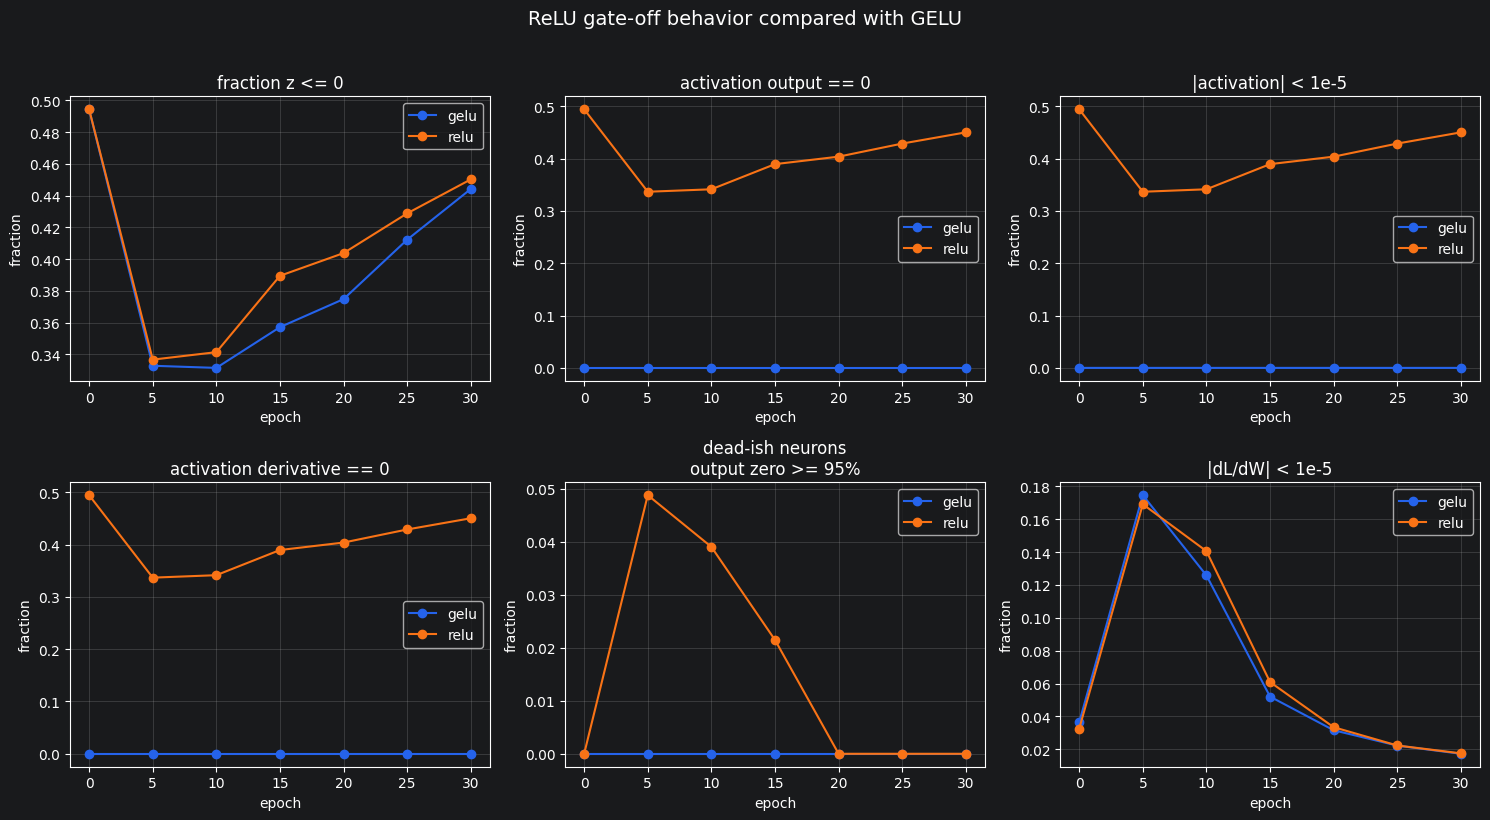

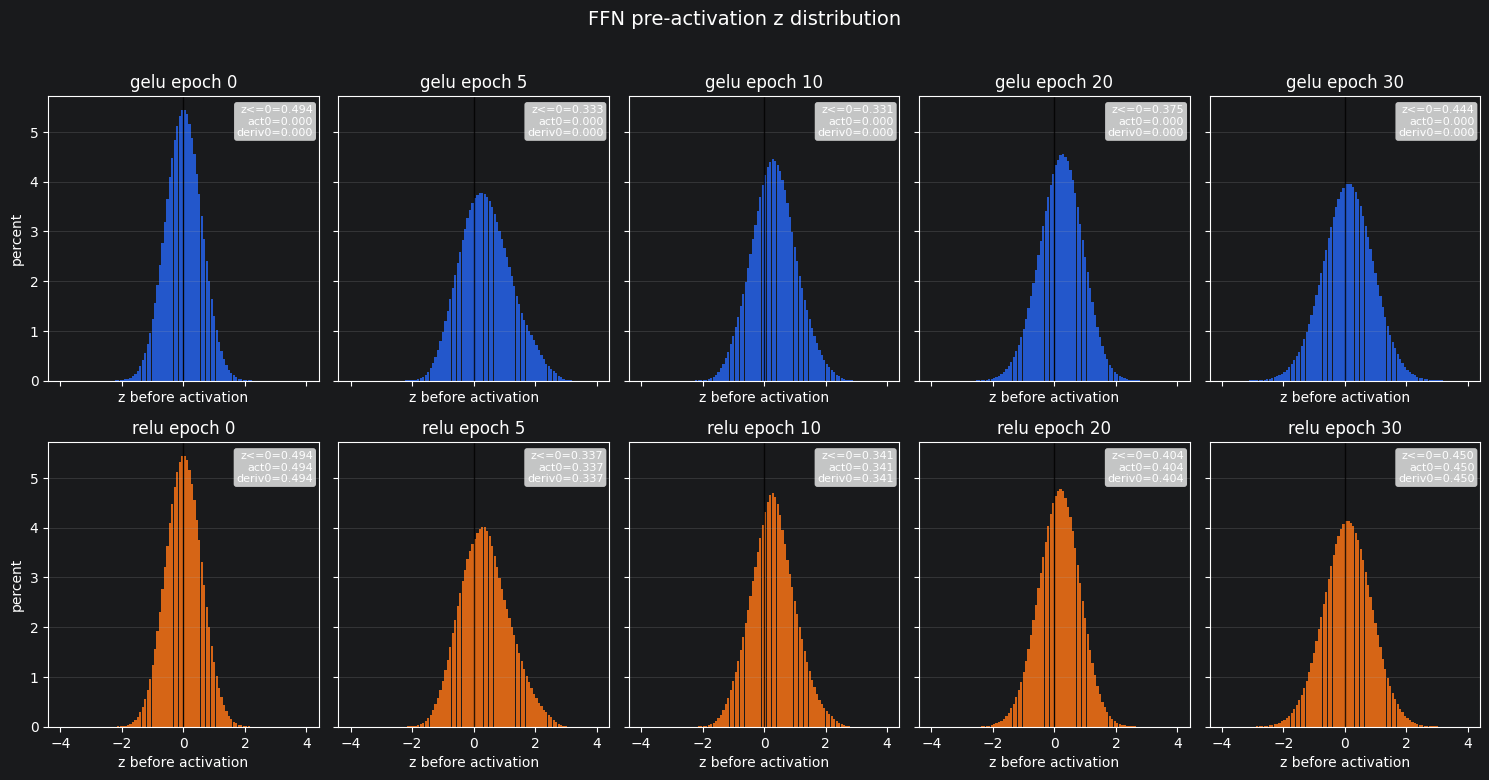

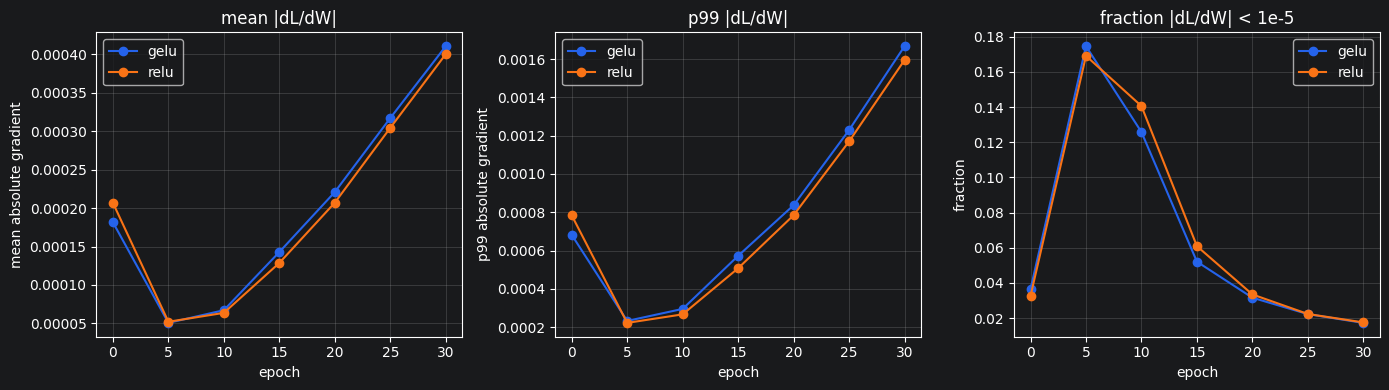

saved: figures\activation_relu_gelu_gate_stats.png
saved: figures\activation_relu_gelu_z_distribution.png
saved: figures\activation_relu_gelu_dldw_stats.png

[epoch-wise comparison]
epoch  0: ReLU act0=0.494, GELU act0=0.000, ReLU deriv0=0.494, GELU deriv0=0.000, ReLU dead=0.000, GELU dead=0.000
epoch  5: ReLU act0=0.337, GELU act0=0.000, ReLU deriv0=0.337, GELU deriv0=0.000, ReLU dead=0.049, GELU dead=0.000
epoch 10: ReLU act0=0.341, GELU act0=0.000, ReLU deriv0=0.341, GELU deriv0=0.000, ReLU dead=0.039, GELU dead=0.000
epoch 20: ReLU act0=0.404, GELU act0=0.000, ReLU deriv0=0.404, GELU deriv0=0.000, ReLU dead=0.000, GELU dead=0.000
epoch 30: ReLU act0=0.450, GELU act0=0.000, ReLU deriv0=0.450, GELU deriv0=0.000, ReLU dead=0.000, GELU dead=0.000


In [6]:
# ACTIVATION_RELU_GELU_GATE_PLOT
# Plot ReLU gate-off behavior against GELU with the collected project-data statistics

from pathlib import Path
import json

import matplotlib.pyplot as plt

RESULT_PATH = Path("checkpoints/activation_relu_gelu_gate_analysis.json")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
activation_names = result["activation_names"]
colors = {"gelu": "#2563eb", "relu": "#f97316"}
selected_epochs = [0, 5, 10, 20, 30]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = [
    ("z_nonpositive_frac", "fraction z <= 0"),
    ("activation_exact_zero_frac", "activation output == 0"),
    ("activation_tiny_frac", "|activation| < 1e-5"),
    ("derivative_exact_zero_frac", "activation derivative == 0"),
    ("activation_deadish_exact_zero_neuron_frac", "dead-ish neurons\noutput zero >= 95%"),
    ("dldw_tiny_frac", "|dL/dW| < 1e-5"),
]

for ax, (metric, title) in zip(axes.reshape(-1), metrics):
    for activation_name in activation_names:
        snapshots = result["runs"][activation_name]["snapshots"]
        epochs = [snapshot["epoch"] for snapshot in snapshots]
        values = [snapshot[metric] for snapshot in snapshots]
        ax.plot(
            epochs,
            values,
            marker="o",
            label=activation_name,
            color=colors.get(activation_name),
        )
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("fraction")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("ReLU gate-off behavior compared with GELU", y=1.02, fontsize=14)
fig.tight_layout()
gate_stats_path = FIGURE_DIR / "activation_relu_gelu_gate_stats.png"
fig.savefig(gate_stats_path, dpi=160, bbox_inches="tight")
plt.show()

z_edges = result["z_bin_edges"]
z_centers = [(left + right) / 2 for left, right in zip(z_edges[:-1], z_edges[1:])]
z_width = z_edges[1] - z_edges[0]

max_percent = 0.0
for activation_name in activation_names:
    snapshots = {snapshot["epoch"]: snapshot for snapshot in result["runs"][activation_name]["snapshots"]}
    for epoch in selected_epochs:
        counts = snapshots[epoch]["z_hist_counts"]
        total = max(sum(counts), 1)
        percents = [count / total * 100 for count in counts]
        max_percent = max(max_percent, max(percents, default=0.0))

fig, axes = plt.subplots(
    len(activation_names),
    len(selected_epochs),
    figsize=(3.0 * len(selected_epochs), 3.8 * len(activation_names)),
    sharex=True,
    sharey=True,
)

if len(activation_names) == 1:
    axes = [axes]

for row_idx, activation_name in enumerate(activation_names):
    snapshots = {snapshot["epoch"]: snapshot for snapshot in result["runs"][activation_name]["snapshots"]}
    for col_idx, epoch in enumerate(selected_epochs):
        ax = axes[row_idx][col_idx] if len(activation_names) > 1 else axes[col_idx]
        snapshot = snapshots[epoch]
        counts = snapshot["z_hist_counts"]
        total = max(sum(counts), 1)
        percents = [count / total * 100 for count in counts]
        ax.bar(
            z_centers,
            percents,
            width=z_width * 0.9,
            color=colors.get(activation_name, "#6b7280"),
            alpha=0.85,
        )
        ax.axvline(0, color="black", linewidth=1.0, alpha=0.8)
        ax.set_title(f"{activation_name} epoch {epoch}")
        ax.set_ylim(0, max_percent * 1.05)
        ax.set_xlabel("z before activation")
        if col_idx == 0:
            ax.set_ylabel("percent")
        ax.grid(True, axis="y", alpha=0.25)
        ax.text(
            0.98,
            0.97,
            f"z<=0={snapshot['z_nonpositive_frac']:.3f}\nact0={snapshot['activation_exact_zero_frac']:.3f}\nderiv0={snapshot['derivative_exact_zero_frac']:.3f}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )

fig.suptitle("FFN pre-activation z distribution", y=1.02, fontsize=14)
fig.tight_layout()
z_dist_path = FIGURE_DIR / "activation_relu_gelu_z_distribution.png"
fig.savefig(z_dist_path, dpi=160, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for activation_name in activation_names:
    snapshots = result["runs"][activation_name]["snapshots"]
    epochs = [snapshot["epoch"] for snapshot in snapshots]
    mean_abs = [snapshot["dldw_mean_abs"] for snapshot in snapshots]
    p99_abs = [snapshot["dldw_p99_abs"] for snapshot in snapshots]
    tiny = [snapshot["dldw_tiny_frac"] for snapshot in snapshots]
    color = colors.get(activation_name)
    axes[0].plot(epochs, mean_abs, marker="o", label=activation_name, color=color)
    axes[1].plot(epochs, p99_abs, marker="o", label=activation_name, color=color)
    axes[2].plot(epochs, tiny, marker="o", label=activation_name, color=color)

axes[0].set_title("mean |dL/dW|")
axes[0].set_ylabel("mean absolute gradient")
axes[1].set_title("p99 |dL/dW|")
axes[1].set_ylabel("p99 absolute gradient")
axes[2].set_title("fraction |dL/dW| < 1e-5")
axes[2].set_ylabel("fraction")

for ax in axes:
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
dldw_path = FIGURE_DIR / "activation_relu_gelu_dldw_stats.png"
fig.savefig(dldw_path, dpi=160, bbox_inches="tight")
plt.show()

print("saved:", gate_stats_path)
print("saved:", z_dist_path)
print("saved:", dldw_path)
print("\n[epoch-wise comparison]")
gelus = {s["epoch"]: s for s in result["runs"]["gelu"]["snapshots"]}
relus = {s["epoch"]: s for s in result["runs"]["relu"]["snapshots"]}
for epoch in selected_epochs:
    g = gelus[epoch]
    r = relus[epoch]
    print(
        f"epoch {epoch:>2}: "
        f"ReLU act0={r['activation_exact_zero_frac']:.3f}, GELU act0={g['activation_exact_zero_frac']:.3f}, "
        f"ReLU deriv0={r['derivative_exact_zero_frac']:.3f}, GELU deriv0={g['derivative_exact_zero_frac']:.3f}, "
        f"ReLU dead={r['activation_deadish_exact_zero_neuron_frac']:.3f}, GELU dead={g['activation_deadish_exact_zero_neuron_frac']:.3f}"
    )


이건 73번째 코드 셀이에요


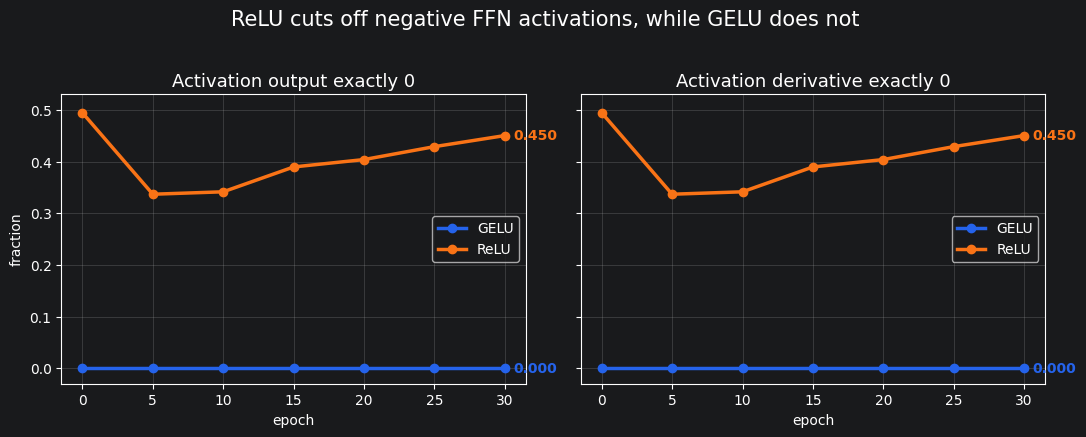

saved: figures\activation_relu_gelu_report_gate_zero.png


In [7]:
# ACTIVATION_RELU_GELU_REPORT_PLOT
# Report-only plot: ReLU gate-off evidence with the minimum necessary panels

from pathlib import Path
import json

import matplotlib.pyplot as plt

RESULT_PATH = Path("checkpoints/activation_relu_gelu_gate_analysis.json")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

result = json.loads(RESULT_PATH.read_text(encoding="utf-8"))
colors = {"gelu": "#2563eb", "relu": "#f97316"}
labels = {"gelu": "GELU", "relu": "ReLU"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
metrics = [
    ("activation_exact_zero_frac", "Activation output exactly 0"),
    ("derivative_exact_zero_frac", "Activation derivative exactly 0"),
]

for ax, (metric, title) in zip(axes, metrics):
    for activation_name in ["gelu", "relu"]:
        snapshots = result["runs"][activation_name]["snapshots"]
        epochs = [snapshot["epoch"] for snapshot in snapshots]
        values = [snapshot[metric] for snapshot in snapshots]
        ax.plot(
            epochs,
            values,
            marker="o",
            linewidth=2.5,
            markersize=6,
            label=labels[activation_name],
            color=colors[activation_name],
        )
        ax.annotate(
            f"{values[-1]:.3f}",
            xy=(epochs[-1], values[-1]),
            xytext=(6, 0),
            textcoords="offset points",
            va="center",
            fontsize=10,
            color=colors[activation_name],
            fontweight="bold",
        )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("epoch")
    ax.set_ylim(-0.03, 0.53)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True)

axes[0].set_ylabel("fraction")
fig.suptitle("ReLU cuts off negative FFN activations, while GELU does not", fontsize=15, y=1.03)
fig.tight_layout()
report_path = FIGURE_DIR / "activation_relu_gelu_report_gate_zero.png"
fig.savefig(report_path, dpi=180, bbox_inches="tight")
plt.show()

print("saved:", report_path)
